# **THESIS CODE**

## **1. INDEX, NOTE, INFORMATION**

### 1.1 NOTE AND OBSERVATION

NOTE 2:

this document uses style standard PEP 8 with following criteria
- two spaces between start of code and startin inline comments
- a single space followed by capital letters for general comments
- maximum number of letters for each line 79
- 4 spaces (no tab) as spacing
- aggregate high priority operators
- always specifying what a function return
- doublequotes
- naming conventions:
  - CapWords for classes
  - lowercase with underscore for functions, methods and variables
  - leading underscore for non public method and instance variable
  - capital words, costant

it uses further docstring convention PEP 257

### 1.2 REFERENCES

here are reported references used to build this code

[1] Seddiqqi, H., Humble, T.S., Adiabatic Quantum Optimization for Associative Memory Recall

[2] Storkey, J.A., Valabregue, R. The Basins of Attraction of a New Hopfield Learning Rule

https://github.com/DimaKrotov/Dense_Associative_Memory

https://github.com/ctawong/hopfield

### 1.3 INDEX

## **2. UTILITIES**

### 2.1. LIBRARY HANDLING

####**2.1.1 libraries installed**

to handle symbolic calculus

In [1]:
!pip install sympy

to handle access to dwave platform

In [2]:
!pip install dwave-ocean-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.9/158.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2

####**2.1.2 imported libraries**

In [3]:
# STANDARD LIBRARIES
import argparse
import scipy.io
from scipy.linalg import hadamard
from itertools import product
import collections
import random
from random import randrange
import math
import copy
from typing import *
from typing import List, Set, Dict, Tuple, Optional, overload, Union

from typing import Callable
from typing_extensions import final
from abc import ABC, abstractmethod  # abstract base class work

# THIRD PARTY IMPORTS
# Numpy
import numpy as np
# Torch
import torch
from torch.utils.data import Dataset
from torchvision import transforms
# Torchvision
import torchvision
from torchvision import datasets
# Matplotlib
import matplotlib.pyplot as plt
# Json
import json
# os
import os
# Simpy
from sympy import *
# Dwave libraries
from dwave.system import DWaveSampler, LazyFixedEmbeddingComposite
from dwave.cloud.exceptions import *
import dimod
from dimod import BinaryQuadraticModel
# sklearn (second part)
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
import pandas as pd


###2.2. UTILITY CODE

####**2.2.1 User defined global**

**Path**

In [4]:
# Contains folder were experiments are located
PATH: str = "drive/MyDrive/QDAM"

**Random seed**

In [5]:
RANDOM_SEED: int = 0

#### **2.2.2 initialization code**

here some utility code for set the env is reported

make plotting inline

In [6]:
%matplotlib inline

set token API for access D-Wave


DEV-dfaff21d40baf11ae742d207c2835cb1ddb6a41f

In [83]:
!dwave setup

Optionally install non-open-source packages and configure your environment.

All optional packages already installed.

Creating the D-Wave configuration file.

Using the simplified configuration flow.
Try 'dwave config create --full' for more options.

Updating existing configuration file: /root/.config/dwave/dwave.conf
Available profiles: defaults
Updating existing profile: defaults
Solver API token [DEV-fd205f7d9c2d6a965857b490632899ef2dfa3119]: DEV-dfaff21d40baf11ae742d207c2835cb1ddb6a41f
Configuration saved.


**Mounting drive**

mount the drive to the directory where project is located

In [8]:
from google.colab import drive
drive.mount("drive", force_remount=True)

Mounted at drive


In [9]:
os.chdir(PATH)

#### **2.2.3 plotting code**

##### 2.2.3.1 part 1

In [10]:
from typing import Dict, Union

In [11]:
def plotTrend2D(title:str, x_label: str, x: Union[List[float], np.ndarray], y_label:str, y: Union[List[float], np.ndarray]) -> None :
    '''
    plot trendline given data
    ...

    Keyword Arguments:
    ----------
        title:str
          -- graph title

        x_label: str
          -- x axis label

        x: Union[List[float], np.ndarray]
          -- x axis data

        y_label:str
          -- y axis label

        y: Union[List[float], np.ndarray]
          -- y axis data

    Returns
    ----------
        None
    '''
    #define data
    x = np.asarray(x)
    y = np.asarray(y)
    #create scatterplot
    plt.scatter(x, y)
    #calculate equation for quadratic trendline
    z = np.polyfit(x, y, 2)
    p = np.poly1d(z)
    #add trendline to plot
    plt.plot(x, p(x))
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()
    return None

##### 2.2.3.1 part 2

In [12]:
def plot_classification_boundaries(classifier, data, classifier_name = "classic SVM"):
    X = data["data"]
    classifier.fit(data["data"], data["label"])
    Y = data["label"]
    h = .02  # step size in the mesh
    # we create an instance of SVM and fit our data. We do not scale our
    # data since we want to plot the support vectors
    # create a mesh to plot in
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, m_max]x[y_min, y_max].
    fig, ax = plt.subplots()
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.Paired)
    ax.axis('off')
    # Plot also the training points
    ax.scatter(X[:, 0], X[:, 1], c=Y)
    ax.set_title('SVM')
    return None

##**3. DATASETS HANDLING**

code for handling datasets used in different experiments

###3.1 PART 1 - DATASETS

note that in [1] author used the following matrix
$$
\Sigma=\left(\begin{array}{llll}
+1 & -1 & -1 & +1 \\
-1 & +1 & -1 & -1 \\
+1 & +1 & +1 & +1 \\
-1 & +1 & +1 & +1
\end{array}\right)
$$
which has a ratio of overlapping patterns of 3/5 . In any case this is not determinant for bigger matrices, so we will in general simply resort to random generation from bernoully with probability p = 1/2 which is followed by [1][2]

####**3.1.1 experiment 1/4 dataset**

in [1] author used the following matrix
$$
\Sigma=\left(\begin{array}{llll}
+1 & -1 & -1 & +1 \\
-1 & +1 & -1 & -1 \\
+1 & +1 & +1 & +1 \\
-1 & +1 & +1 & +1
\end{array}\right)
$$
for comparison sake we use this as minimum dimension and then increase it

In [13]:
def get_data_exp1_1(num_mem: int = 4, num_neurons: int = 4) -> Dict[str, np.ndarray]:
    '''
    get data for first  and fourth experiment
    ...

    Keyword Arguments:
    ----------
        num_mem: int (default: 4)
            -- number of memories

        num_neurons: int (default: 4)
            -- number of neurons

    Returns
    ----------
        dictionary having as indexes:
            "data_binary" is the data matrix in binary format
            "selected_binary" is the selected array in binary format
            "bias_binary" is the bias array in binary format
            "data_bipolar" is the data matrix in bipolar format
            "selected_bipolar" is the selected array in bipolar format
            "bias_bipolar" is the bias array in bipolar format
    '''
    # these functions are used to convert from binary to bipolar and vice versa
    from_bin_to_bip: Callable[int, int]  = lambda x: 2*x - 1
    from_bip_to_bin: Callable[int, int] = lambda x: (x + 1)/2
    if ((num_mem == 4) and (num_neurons == 4)):
        # create first deafult memory
        dataset_dict: Dict[int, Dict[str, np.ndarray]] = {}
        dataset_dict = {}
        dataset_dict["data_bipolar"] = np.array([[1, -1, 1, -1], [-1, 1, 1, 1], [-1, -1, 1, 1], [1, -1, 1, 1]])
        dataset_dict["selected_bipolar"] = dataset_dict["data_bipolar"][randrange(4), :]
        dataset_dict["bias_bipolar"] = dataset_dict["selected_bipolar"]
        dataset_dict["data_binary"] = from_bip_to_bin(dataset_dict["data_bipolar"])
        dataset_dict["selected_binary"] = from_bip_to_bin(dataset_dict["selected_bipolar"])
        dataset_dict["bias_binary"] = dataset_dict["selected_binary"]
    else:
        # create data matrices
        dataset_dict = {}
        dataset_dict["data_binary"] = np.random.randint(2, size = (num_mem, num_neurons))
        dataset_dict["selected_binary"] = dataset_dict["data_binary"][randrange(num_mem), :]
        dataset_dict["bias_binary"] = dataset_dict["selected_binary"]
        dataset_dict["data_bipolar"] = from_bin_to_bip(dataset_dict["data_binary"])
        dataset_dict["selected_bipolar"] = from_bin_to_bip(dataset_dict["selected_binary"])
        dataset_dict["bias_bipolar"] = dataset_dict["selected_bipolar"]
    new_dataset_dict = copy.deepcopy(dataset_dict)
    for lab in dataset_dict:
        new_dataset_dict[lab] = new_dataset_dict[lab].tolist()
    return new_dataset_dict


####**3.1.2 experiment 2/3 dataset**

In [14]:
def get_data_exp1_2(num_mem: int = 4, num_neurons: int = 4) -> Dict[str, np.ndarray]:
    '''
    get data for second and third experiment
    ...

    Keyword Arguments:
    ----------
        num_mem: int (default: 4)
            -- number of memories

        num_neurons: int (default: 4)
            -- number of neurons
    Returns
    ----------
        dictionary having as index is a string which can take following values:
            "data_binary" is the data matrix in binary format
            "bias_binary" is the bias array in binary format
            "selected_binary" is the selected array in binary format
            "data_bipolar" is the data matrix in bipolar format
            "selected_bipolar" is the selected array in bipolar format
            "bias_bipolar" is the bias array in binary format
    '''
    def dist_2(arr: np.ndarray) -> np.ndarray:
        '''
        generate array with hamming distance 2 from original one
        ...

        Keyword Arguments:
        ----------
            arr: np.ndarray
                -- original array
        Returns
        ----------
            array with hamming distance 2 from original one
        '''
        i: int = randrange(arr.shape[0])
        j: int = randrange(arr.shape[0])
        while j == i:
            j = randrange(arr.shape[0])
        if arr[i] == 0:
            arr[i] = 1
        else:
            arr[i] = 0
        if arr[j] == 0:
            arr[j] = 1
        else:
            arr[j] = 0
        return arr
    def dist_1(arr: np.ndarray) -> np.ndarray:
        '''
        generate array with hamming distance 1 from original one
        ...

        Keyword Arguments:
        ----------
            arr: np.ndarray
                -- original array
        Returns
        ----------
            array with hamming distance 1 from original one
        '''
        i: int = randrange(arr.shape[0])
        if arr[i] == 0:
            arr[i] = 1
        else:
            arr[i] = 0
        return arr
    # these functions are used to convert from binary to bipolar and vice versa
    from_bin_to_bip: Callable[int, int] = lambda x: 2*x - 1
    from_bip_to_bin: Callable[int, int] = lambda x: (x + 1)/2
    # create first deafult memory
    dataset_dict: Dict[str, np.ndarray] = {}
    dataset_dict["selected_binary"] = np.random.randint(2, size = num_neurons)
    # construct all other memory at hamming distance 2
    new_matrix: np.ndarray = np.tile(dataset_dict["selected_binary"], (num_neurons, 1))
    new_matrix: np.ndarray = np.apply_along_axis(dist_2, 1, new_matrix)
    new_matrix[0, :] = dataset_dict["selected_binary"]
    dataset_dict["data_binary"] = new_matrix
    # create the bias at an hamming distance of 1
    dataset_dict["bias_binary"] = dist_1(dataset_dict["selected_binary"])
    dataset_dict["data_bipolar"] = from_bin_to_bip(dataset_dict["data_binary"])
    dataset_dict["selected_bipolar"] = from_bin_to_bip(dataset_dict["selected_binary"])
    dataset_dict["bias_bipolar"] = from_bin_to_bip(dataset_dict["bias_binary"])
    new_dataset_dict = copy.deepcopy(dataset_dict)
    for lab in dataset_dict:
        new_dataset_dict[lab] = new_dataset_dict[lab].tolist()
    return new_dataset_dict

###3.1 PART 2 - DATASETS

#### **3.1.1 Fake Dataset**

In [15]:
def get_fake_dataset(number_data: int = 40, loc: float = 0.0, scale: float = 0.2):
    FAKE_DATA_TEMPLATE = {
        "dim1": None,
        "dim2": None,
        "label": None
    }
    fake_dataset = []
    for i in range(number_data):
        data = copy.deepcopy(FAKE_DATA_TEMPLATE)
        if i < 20:
            data["label"] = -1
        else:
            data["label"] = 1
        fi_n = np.random.uniform(low=0.0, high=2*math.pi)
        data["dim1"] = (1 if data["label"] == -1 else 0.15)*math.cos(fi_n)+np.random.normal(loc=loc, scale=scale)
        data["dim2"] = (1 if data["label"] == -1 else 0.15)*math.sin(fi_n)+np.random.normal(loc=loc, scale=scale)
        fake_dataset.append(data)
    fake_dataset_np = {
      "data": np.asarray([[fake_dataset[i]["dim1"], fake_dataset[i]["dim2"]] for i in range(40)]),
      "label": np.asarray([fake_dataset[i]["label"] for i in range(40)])
    }
    return fake_dataset_np

#### **3.1.1 Iris Dataset**

In [16]:
def get_iris(test_size: float = 0.2, valid_size: float = 0.25):
    iris = datasets.load_iris()
    iris_edited = {
        "data": [],
        "target": []
    }
    i = 0
    for target in iris['target']:
        if target != 0:  # mantain only nonlinearly separable classes
            iris_edited["data"].append(iris['data'][i])
            iris_edited["target"].append(1 if target == 2 else -1)
        i = i + 1
    iris_edited["data"] = np.asarray(iris_edited["data"])
    iris_edited["target"] = np.asarray(iris_edited["target"])
    scaler = MinMaxScaler()
    iris_edited["data"] = scaler.fit_transform(iris_edited["data"])
    X_train, X_test, y_train, y_test = train_test_split(iris_edited["data"], iris_edited["target"], test_size=test_size, random_state=RANDOM_SEED)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=valid_size, random_state=RANDOM_SEED)
    return X_train, X_test, X_val, y_train, y_test, y_val

##**4. MODEL**

### **4.1 FIRST PART MODEL**

**Note1**: for quantum annealing we minimize QUBO formulation after applying substitution to qubit:

\begin{aligned}
&s_i-2 x_i-1\\
&x_i \in\{0,1\}
\end{aligned}

motivation are related to the fact that QUBO offer more subsitutions for dealing with multiple interactions that will be useful for dealing with quantum dense associative memories

#### **4.1.1 CLASSICAL MODEL**

this abstract class is the one each classical associative memory is subclassed

In [17]:
class AssociativeMemory(ABC):
    '''
    Abstract class for associative memory

    ...
    Instance Variables:
    ----------
        _length: int
            -- length of memory stored

        _weights: np.ndarray
            -- weight matrix of associative memory


        _neurons: np.ndarray
            -- neurons of associative memory


    Public Methods:
    ----------

        get_value(self)-> np.ndarray
            -- get value inside this wrapper

        set_memories(self, memories: np.ndarray)-> None
            -- set memories of associative memory

        update(self, num_updates: int = 1000) -> None
            -- update state of associative memory

    '''
    def __init__(self, binary: bool = False)  -> None:
        '''
        initialize associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray (default: None)
                -- passed mem

            binary: bool (default: False)
                -- if one want binary mem
        Returns
        ----------
            None
        '''
        self.binary = binary # get if one want binary neyurons
        return None

    def set_neurons(self, state: np.ndarray) -> None:
        '''
        set neuron state of associative memory
        ...

        Keyword Arguments:
        ----------
            state: np.ndarray
                -- passed state
        Returns
        ----------
            None
        '''
        self.neurons = np.array(state)
        return None



    def set_memories(self, memories: np.ndarray) -> None:
        '''
        set memories of associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray
                -- passed memories
        Returns
        ----------
            None
        '''
        self._length: int = memories.shape[1]  # set memory length
        self._weights: np.ndarray = np.zeros([self._length, self._length])  # initialize weight matrix
        from_bin_to_bip: Callable[int, int]  = lambda x: 2*x - 1
        self._neurons: np.ndarrray = (
                from_bin_to_bip(np.random.randint(2, size = self._length)) if self.binary == False else np.random.randint(2, size = self._length)
                )
        return None

    @abstractmethod
    def _get_energy(self, neurons: Optional[np.ndarray] = None) -> None:
        '''
        abstract method
        get energy value
        ...

        Keyword Arguments:
        ----------
            neurons: Optional[np.ndarray] (default: None)
                -- passed state
        Returns
        ----------
            None
        '''
        pass
        return None

    @abstractmethod
    def update(self, num_updates: int = 1000) -> None:
        '''
        abstract method
        update neurons of associative mem
        ...

        Keyword Arguments:
        ----------
            num_updates: int (default: 1000)
                -- number of maximum number of update of associative memory
                   before exit the update loop
        Returns
        ----------
            None
        '''
        pass
        return None

##### 4.1.1.1 Hopfield model

In [18]:
class Hopfield(AssociativeMemory):
    '''
    Hopfield model class

    ...
    Instance Variables:
    ----------
        _length: int
            -- length of memory stored

        weights: np.ndarray
            -- weight matrix of associative memory


        neurons: np.ndarray
            -- neurons of associative memory

        rule: str
            -- the rule used to update weights

        binary: bool
            -- if one want binary mem

    Public Methods:
    ----------
        get_value(self)-> np.ndarray
            -- get value inside this wrapper

        set_memories(self, memories: np.ndarray)-> None
            -- set memories of associative memory

        update(self, num_updates: int = 1000) -> int
            -- update state of associative memory


    '''
    def __init__(self, memories: Optional[np.ndarray] = None, binary: bool = False, rule: str = "heb") -> None:
        '''
        initialize associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray (default: None)
                -- passed mem

            binary: bool (default: False)
                -- if one want binary mem

            rule: str (default: "heb")
                -- rule used for associative memory
        Returns
        ----------
            None
        '''
        super().__init__(binary)  # call superclass
        self.rule: str = rule  # save rule used
        if memories is not None:
            self.set_memories(memories)
        return None

    def set_memories(self, memories: np.ndarray)-> None:
        '''
        set memories of associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray (default: np.ndarray)
                -- memories one want to store
        Returns
        ----------
            none
        '''
        super().set_memories(memories)
        # based on rule type set weights
        if self.rule == "heb":
            for m in memories:
                self._weights += np.outer(m, m)
            # for stability (avoid cycling)
            for i in range(self._length):
                self._weights[i][i] = 0.
        elif self.rule == "storkey":
            for m in memories:
                new_weight = self._weights.copy().tolist()
                m_list = m.tolist()
                for i in range(self._length):
                    for j in range(self._length):
                        h_ij = 0
                        h_ji = 0
                        for k in range(self._length):
                            if k != i and k != j:
                                h_ij += self._weights[i, k] * m_list[k]
                                h_ji += self._weights[j, k] * m_list[k]
                        new_weight[i][j] = new_weight[i][j] + + (1/self._length) * (m_list[i] * m_list[j])-(1/self._length)*m_list[i]*h_ji  -(1/self._length)*m_list[j]*h_ij
                self._weights = np.asarray(new_weight)
        elif self.rule == "projection":
            new_weight = self._weights.copy().tolist()
            for i in range(self._length):
                for j in range(self._length):
                    product = 0
                    for k in range(self._length):
                        for l in range(self._length):
                          cov = (1/self._length)*sum([memories[k, p]*memories[l, p] for p in range(self._length) ])
                          product = product + memories[k, i]*(1/cov)*memories[l, j]
                    new_weight[i][j] = (1/self._length)*product
            self._weights = np.asarray(new_weight)
        return None

    def _get_energy(self, neurons: Optional[np.ndarray] = None) -> float:
        '''
        get energy value of actual state (or provided one if set as argument)
        ...

        Keyword Arguments:
        ----------
            neurons: Optional[np.ndarray] (default: None)
                -- optional initial state value
        Returns
        ----------
            energy value
        '''
        if neurons is None:
            neurons: np.ndarray = self._neurons
        return -0.5*float(np.dot(np.matmul(neurons[np.newaxis,:], self._weights), neurons))


    def update(self, num_updates: int = 1000) -> int:
        '''
        update Hopfield net
        ...

        Keyword Arguments:
        ----------
            num_updates: int (default: 1000)
                -- number of maximum number of update of associative memory
                   before exit the update loop
        Returns
        ----------
            number of step before convergence
        '''
        for n in range(num_updates):
            old_neuron: np.ndarray = self._neurons.copy()
            update_order: np.ndarray = np.arange(0, self._length)
            random.shuffle(update_order)
            for i in update_order:
                    # flip a neuron state if energy is lower after flipping
                    new_neurons: np.ndarray = self._neurons.copy()
                    if self.binary == False:
                      new_neurons[i] *= -1
                    else:  # if binary neurons are employed
                        if new_neurons[i] == 0:
                            new_neurons[i] = 1
                        else:
                            new_neurons[i] = 0
                    energy_diff: float = self._get_energy(new_neurons) - self._get_energy()
                    if energy_diff < 0:
                        self._neurons[i] = new_neurons[i]
            if np.array_equal(self._neurons, old_neuron):
                return self._neurons
        return self._neurons



##### 4.1.1.2 Dense Associative Memory model

In [19]:
class DenseAssociativeMemory(AssociativeMemory):
    '''
    Dense associative memory model class

    ...
    Instance Variables:
    ----------
        _length: int
            -- length of memory stored

        weights: np.ndarray
            -- weight matrix of associative memory


        neurons: np.ndarray
            -- neurons of associative memory

        rule: str
            -- the rule used to update weights

        binary: bool
            -- if one want binary mem

    Public Methods:
    ----------
        get_value(self)-> np.ndarray
            -- get value inside this wrapper

        set_memories(self, memories: np.ndarray)-> None
            -- set memories of associative memory

        update(self, num_updates: int = 1000) -> int
            -- update state of associative memory


    '''
    def __init__(self, memories: Optional[np.ndarray] = None, binary: bool = False, rule = "rp", spherical = False, order: int = 2) -> None:
        '''
        initialize associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray (default: None)
                -- passed mem

            binary: bool (default: False)
                -- if one want binary mem

            rule: str (default: "heb")
                -- rule used for associative memory

            spherical: bool (default: False)
                -- if spherical set to true normalize nueron value in respect to sum of neuron values

            order: int (default: 2)
                -- order of polynomial if rp rule is used
        Returns
        ----------
            None
        '''
        super().__init__(binary)
        self.rule = rule
        self.order = order
        self.spherical = spherical
        if memories is not None:
            self.set_memories(memories)
        return None

    def set_memories(self, memories: np.ndarray) -> None:
        '''
        set memories of associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray (default: np.ndarray)
                -- memories one want to store
        Returns
        ----------
            none
        '''
        super().set_memories(memories)
        self.memories = memories
        return None

    def _nonlinearity(self, x: np.ndarray) -> np.ndarray:
        '''
        apply nonlinearity
        ...

        Keyword Arguments:
        ----------
            x: np.ndarray
                -- row over which apply nonlinearity
        Returns
        ----------
            row after nonlinearity application
        '''
        if self.rule == "rp":
            x[x < 0] = 0.
            return x**self.order
        elif self.rule == "exp":
            return np.exp(x)
        return None

    def _get_energy(self, neurons: Optional[np.ndarray] = None) -> float:
        '''
        get energy value of actual state (or provided one if set as argument)
        ...

        Keyword Arguments:
        ----------
            neurons: Optional[np.ndarray] (default: None)
                -- optional initial state value
        Returns
        ----------
            energy value
        '''
        if neurons is None:
            neurons = self._neurons
        if self.spherical:
          sum: float = (neurons**2).sum()
          neurons = neurons/sum
        x = (np.tile(neurons, (len(self.memories), 1)) * self.memories).sum(1)
        E = - self._nonlinearity(x).sum()
        return E

    def update(self, num_updates: int = 1000) -> int:
        '''
        update Hopfield net
        ...

        Keyword Arguments:
        ----------
            num_updates: int (default: 1000)
                -- number of maximum number of update of associative memory
                   before exit the update loop
        Returns
        ----------
            number of step before convergence
        '''

        for n in range(num_updates):
            old_neuron = self._neurons.copy()
            update_order = np.arange(0, self._length)
            random.shuffle(update_order)

            for i in update_order:
                    # flip a neuron state if energy is lower after flipping
                    new_neurons = self._neurons.copy()
                    if self.binary == False:
                      new_neurons[i] *= -1
                    else:  # if binary neurons are employed
                        if new_neurons[i] == 0:
                            new_neurons[i] = 1
                        else:
                            new_neurons[i] = 0
                    energy_diff = self._get_energy(new_neurons) - self._get_energy()
                    if energy_diff < 0:
                        self._neurons[i] = new_neurons[i]

            if np.array_equal(self._neurons, old_neuron):
                return self._neurons
        return self._neurons


#### **4.1.2 QUANTUM MODEL**

In [20]:
class QuantumAssociativeMemory(ABC):
    '''
    Abstract class for associative memory

    ...
    Instance Variables:
    ----------
        _length: int
            -- length of memory stored

        _weights: np.ndarray
            -- weight matrix of associative memory


        _bqm: dimod.BinaryQuadraticModel
            -- store bqm coefficient

        _sampler : dwave.LazyFixedEmbeddingComposite
            -- sampler to solve problem

        _bias: np.ndarray
            -- bias of associative memory

    Public Methods:
    ----------
        set_bias(self)-> None
            -- set bias of associative memory

        set_memories(self, memories: np.ndarray)-> None
            -- set memories of associative memory

        update(self, num_reads: int = 100) -> None
            -- update state of associative memory

    '''
    def __init__(self, binary: bool = False)  -> None:
        '''
        initialize associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray (default: None)
                -- passed mem

            binary: bool (default: False)
                -- if one want binary mem
        Returns
        ----------
            None
        '''
        self.binary = binary # get if one want binary neyurons
        try:
          self._qpu_advantage = DWaveSampler(solver={'topology__type': 'pegasus'})
          print("Connected to Advantage {}.".format(self._qpu_advantage.solver.id))
        except SolverNotFoundError:
          print("You currently cannot access an Advantage. Try these examples once you have access.")

        self._sampler = LazyFixedEmbeddingComposite(self._qpu_advantage)
        if self.binary == True:
            self._bqm = BinaryQuadraticModel('BINARY')
        else:
            self._bqm = BinaryQuadraticModel('SPIN')
        self.bias = None
        self._weights = None
        return None

    def set_bias(self, state: np.ndarray, bias: float = 1, bias_mult: Optional[float] = None) -> None:
        '''
        set bias of dense associative memory (override abstract class method)
        ...

        Keyword Arguments:
        ----------
            state: np.ndarray
                -- passed state

            bias_mult: Optional[float] (default: None)
                -- multiplicative factor of bias. if different from None it is normalized in respect
                   to weights which comes from memories. alternatively it is simply added to energy.
        Returns
        ----------
            None
        '''
        if self._weights is None:
            raise Exception("Set memories first")
        else:
          self.bias = np.array(state) * bias_mult if bias_mult is not None else np.array(state)
          self._bqm.add_linear_from({"x_"+str(i) : -1*self.bias[i] for i in range(self._length)})
          quadratic = {}
          if bias_mult is not None:
              for i in range(self._length):
                  for j in range(self._length):
                      if i != j:
                        quadratic[("x_"+str(i), "x_"+str(j))] = (1-bias_mult)*(-0.5*self._weights[i, j])
          else:
              for i in range(self._length):
                  for j in range(self._length):
                      if i != j:
                        quadratic[("x_"+str(i), "x_"+str(j))] = -0.5*self._weights[i, j]
          self._bqm.add_quadratic_from(quadratic)
        return None

    def set_memories(self, memories: np.ndarray) -> None:
        '''
        set memories of associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray
                -- passed memories
        Returns
        ----------
            None
        '''
        self._length: int = memories.shape[1]  # set memory length
        self._weights: np.ndarray = np.zeros([self._length, self._length])  # initialize weight matrix
        return None

    @abstractmethod
    def update(self, num_reads: int = 100) -> None:
        '''
        abstract method
        update neurons of associative mem
        ...

        Keyword Arguments:
        ----------
            num_reads: int (default: 100)
                -- number of samples to do
        Returns
        ----------
            None
        '''
        pass
        return None

##### 4.1.2.1 Hopfield model

In [21]:
class QuantumHopfield(QuantumAssociativeMemory):
    '''
    Abstract class for associative memory

    ...
    Instance Variables:
    ----------
        _length: int
            -- length of memory stored

        _weights: np.ndarray
            -- weight matrix of associative memory

        rule: str
            -- the rule used to update weights

        _bqm: dimod.BinaryQuadraticModel
            -- store bqm coefficient

        _sampler : dwave.LazyFixedEmbeddingComposite
            -- sampler to solve problem

        _bias: np.ndarray
            -- bias of associative memory

    Public Methods:
    ----------
        set_bias(self)-> None
            -- set bias of associative memory

        set_memories(self, memories: np.ndarray)-> None
            -- set memories of associative memory

        update(self, num_reads: int = 100) -> None
            -- update state of associative memory

    '''

    def __init__(self, memories: Optional[np.ndarray] = None, binary: bool = False, rule: str = "heb") -> None:
        '''
        initialize associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray (default: None)
                -- passed mem

            binary: bool (default: False)
                -- if one want binary mem

            rule: str (default: "heb")
                -- rule used for associative memory
        Returns
        ----------
            None
        '''
        super().__init__(binary)  # call superclass
        self.rule: str = rule  # save rule used
        if memories is not None:
            self.set_memories(memories)
        self.binary_var = {}
        return None

    def set_memories(self, memories: np.ndarray)-> None:
        '''
        set memories of associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray (default: np.ndarray)
                -- memories one want to store
        Returns
        ----------
            none
        '''
        old_weights = self._weights.shape[0] if self._weights is not None else None
        super().set_memories(memories)
        if ((old_weights is not None) and (old_weights != self._weights.shape[0])):
            self._sampler = LazyFixedEmbeddingComposite(self._qpu_advantage)
            if self.binary == True:
                self._bqm = BinaryQuadraticModel('BINARY')
            else:
                self._bqm = BinaryQuadraticModel('SPIN')
        # based on rule type set weights
        if self.rule == "heb":
            for m in memories:
                self._weights += np.outer(m, m)
            # for stability (avoid cycling)
            for i in range(self._length):
                self._weights[i][i] = 0.
        elif self.rule == "storkey":
            for m in memories:
                new_weight = self._weights.copy().tolist()
                m_list = m.tolist()
                for i in range(self._length):
                    for j in range(self._length):
                        h_ij = 0
                        h_ji = 0
                        for k in range(self._length):
                            if k != i and k != j:
                                h_ij += self._weights[i, k] * m_list[k]
                                h_ji += self._weights[j, k] * m_list[k]
                        new_weight[i][j] = new_weight[i][j] + + (1/self._length) * (m_list[i] * m_list[j])-(1/self._length)*m_list[i]*h_ji  -(1/self._length)*m_list[j]*h_ij
                self._weights = np.asarray(new_weight)
        elif self.rule == "projection":
            new_weight = self._weights.copy().tolist()
            for i in range(self._length):
                for j in range(self._length):
                    product = 0
                    for k in range(memories.shape[0]):
                        for l in range(memories.shape[0]):
                          cov = (1/self._length)*sum([memories[k, p]*memories[l, p] for p in range(self._length) ])
                          if cov == 0.0:
                              cov = 0.001
                          product = product + memories[k, i]*(1/cov)*memories[l, j]
                    new_weight[i][j] = (1/self._length)*product
            self._weights = np.asarray(new_weight)
        return None



    def update(self, num_reads: int = 100, annealing_time: float = 20) -> int:
        '''
        update Hopfield net
        ...

        Keyword Arguments:
        ----------
            num_reads: int (default: 100)
                -- number of samples that sampler do
        Returns
        ----------
            number of step before convergence
        '''

        sampleset = self._sampler.sample(self._bqm, num_reads = num_reads,  annealing_time=annealing_time)
        result_dict = {}
        result_dict["lowest_energy_sample"] = {}
        result_dict["lowest_energy_sample"] = [0]*self._length
        for var in self._bqm.linear:
            result_dict["lowest_energy_sample"][int(var[2])-1] = int(sampleset.first.sample[var])
        result_dict["all_samples"] = {}
        i = 0
        for sample in sampleset.samples():
            sample_list = []
            for var in self._bqm.linear:
                sample_list.append(sample[var])
            result_dict["all_samples"][" ".join(str(x) for x in sample_list)] = sampleset.record[i][2] / num_reads
            i = i + 1
        return result_dict


##### 4.1.2.2 Dense Associative Memory model

possible rules are
- relu_first
  first formulation relu
- reul_second
  second formulation relu
- relu_third
  third formulation relu
- exp_third
  third formulation exp
- centroid_third
  third formulation centroid


In [22]:
class QuantumDenseAssociativeMemory(QuantumAssociativeMemory):
    '''
    Quantum Dense Associative mMemory model class

    ...
    Instance Variables:
    ----------
        _length: int
            -- length of memory stored

        weights: np.ndarray
            -- weight matrix of associative memory


        neurons: np.ndarray
            -- neurons of associative memory

        rule: str
            -- the rule used to update weights

        binary: bool
            -- if one want binary mem

    Public Methods:
    ----------
        get_value(self)-> np.ndarray
            -- get value inside this wrapper

        set_memories(self, memories: np.ndarray)-> None
            -- set memories of associative memory

        update(self, num_updates: int = 1000) -> int
            -- update state of associative memory


    '''
    def __init__(self, memories: Optional[np.ndarray] = None,
                 rule = "relu_third",
                 gamma_mu: Optional[List[int]] = None,
                 gamma_prime_mu: Optional[List[int]] = None,
                 gamma_lambda: Optional[List[List[int]]] = None) -> None:
        '''
        initialize associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray (default: None)
                -- passed mem

            rule: str (default: "heb")
                -- rule used for associative memory

            gamma_mu: Optional[List[int]]
                -- used to enforce constraint on memory
            gamma_lambda: Optional[List[List[int]]]
                -- used to enforce constraints on qubits
        Returns
        ----------
            None
        '''
        super().__init__(True)
        self.rule = rule
        # store gamma
        # for both of theese constraint to be enforced simply put their value over the
        # premium of violating them
        if gamma_mu is not None:
            self.gamma_mu = gamma_mu
        else:
            self.gamma_mu = None
        if gamma_prime_mu is not None:
            self.gamma_prime_mu = gamma_prime_mu
        else:
            self.gamma_prime_mu = None
        if gamma_lambda is not None:
            self.gamma_lambda = gamma_lambda
        else:
            self.gamma_lambda = None
        # if memories are not none
        self.energy_polynomial = 0
        self.energy_polynomial_nonexpanded = 0
        self.all_annealer_var = {}
        self.bipolar_var = {}  # store bipolar var
        self.binary_var = {}   # store bianry var
        # store var used for represent the value of dot prodct
        self.encoding_var = {}
        # check var
        self.check_var = {}
        # aux var
        self.aux_var = {}
        self.aux_counter = 0
        # k arr
        self.k_arr = []
        self.k_arr_pos_index = None
        if memories is not None:
            self.set_memories(memories)
        return None

    def set_memories(self, memories: np.ndarray)-> None:
        '''
        set memories of associative memory
        ...

        Keyword Arguments:
        ----------
            memories: np.ndarray (default: np.ndarray)
                -- memories one want to store
        Returns
        ----------
            none
        '''
        old_weights = self._weights.shape[0] if self._weights is not None else None
        super().set_memories(memories)

        if ((old_weights is not None) and (old_weights != self._weights.shape[0])):
            self._sampler = LazyFixedEmbeddingComposite(self._qpu_advantage)
            if self.binary == True:
                self._bqm = BinaryQuadraticModel('BINARY')
            else:
                self._bqm = BinaryQuadraticModel('SPIN')
        # if gamma was none before
        if self.gamma_mu is None:
            self.gamma_mu = [math.e**(self._length+1)]*memories.shape[0]
        if self.gamma_prime_mu is None:
            self.gamma_prime_mu = [math.e**(self._length+1)]*memories.shape[0]
        if self.gamma_lambda is None:
            self.gamma_lambda = [[math.e**(self._length+1)]*self._length]*memories.shape[0]
        # same as init if memories is not none
        # first two rules use complement encoding
        if ((self.rule == "relu_first") or (self.rule == "relu_second")):
            # compute dimension of two complement
            extra_var_compl = math.ceil(math.log(self._length + 1, 2) + 1)
        else:
            self.k_arr = [i*1+(self._length-i)*-1 for i in range(self._length+1)]
            self.k_arr_pos_index = None
            # retrieve first positive index
            for i in range(len(self.k_arr)):
                if ((self.k_arr[i] > 0) and (self.k_arr_pos_index is None)):
                    self.k_arr_pos_index = i
        for i in range(self._length):
            self.bipolar_var['s_'+str(i+1)] = symbols('s_'+str(i+1))  # define symbols for bipolar variables
            self.binary_var['x_'+str(i+1)] = symbols('x_'+str(i+1))  # define symbols for binary variables
            self.all_annealer_var['x_'+str(i+1)] = self.binary_var['x_'+str(i+1)]

        for i in range(memories.shape[0]):
            self.encoding_var["zeta_"+str(i+1)] = {}
            if (self.rule == "relu_first") or (self.rule == "relu_second"):
                for j in range(extra_var_compl):
                    self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)] = symbols("eps_"+str(i+1)+"_"+str(j))
                    self.all_annealer_var["eps_"+str(i+1)+"_"+str(j)] = self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]
            else:
                for j in range(len(self.k_arr)):
                    self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)] = symbols("eps_"+str(i+1)+"_"+str(j))
                    self.all_annealer_var["eps_"+str(i+1)+"_"+str(j)] = self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]
        for i in range(memories.shape[0]):   # iterate over memories
            square = 0
            # create the two compl
            two_comp = 0
            if (self.rule == "relu_first") or (self.rule == "relu_second"):
                for j in range(extra_var_compl):
                  if j != extra_var_compl - 1:
                      two_comp = two_comp + (2**j)*self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]
                  else:
                      two_comp = two_comp - (2**j)*self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]
            else:
                for j in range(len(self.k_arr)):
                    two_comp = two_comp + self.k_arr[j]*self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]
            # construct dot product
            dot_prod = 0
            for j in range(self._length): # iterate over qubits
                dot_prod = dot_prod +  self.bipolar_var['s_'+str(j+1)]*memories[i, j]
            # subtract the two complement
            square = dot_prod - two_comp
            self.energy_polynomial = self.energy_polynomial + self.gamma_mu[i]*(square)**2
            # implement rule
            if (self.rule == "relu_first"):
                self.energy_polynomial = self.energy_polynomial - (1-self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(extra_var_compl - 1)])*((dot_prod)**2)
            elif (self.rule == "relu_second"):
                second_constraint = 0
                self.check_var[str(i+1)] = {}
                for j in range(extra_var_compl-1):
                    self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)] = symbols("t_"+str(i+1)+"_"+str(j))
                    self.check_var[str(i+1)]["t'_"+str(i+1)+"_"+str(j)] = symbols("t'_"+str(i+1)+"_"+str(j))
                    self.all_annealer_var["t_"+str(i+1)+"_"+str(j)] = self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)]
                    self.all_annealer_var["t'_"+str(i+1)+"_"+str(j)] = self.check_var[str(i+1)]["t'_"+str(i+1)+"_"+str(j)]
                    constraint = self.gamma_lambda[i][j]*(self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)] - (1-self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(extra_var_compl - 1)])*(self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]))**2
                    second_constraint = second_constraint + expand(constraint)
                    second_constraint = second_constraint.subs(
                        self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)]**2,
                        self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)]
                    )
                    second_constraint = second_constraint.subs(
                        self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(extra_var_compl-1)]**2,
                        self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(extra_var_compl-1)]
                    )
                    second_constraint = second_constraint.subs(
                        self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]**2,
                        self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]
                    )
                    second_constraint = second_constraint.subs(
                        self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)]*self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(extra_var_compl - 1)]*self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)],
                        self.check_var[str(i+1)]["t'_"+str(i+1)+"_"+str(j)]*(self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)]+self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(extra_var_compl - 1)]+self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]-1) + (self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)]*self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(extra_var_compl - 1)]+self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(extra_var_compl - 1)]*self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]+self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]*self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)]) -1*(self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)] + self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(extra_var_compl - 1)] + self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]) + 1)
                    second_constraint = expand(second_constraint)
                self.energy_polynomial = self.energy_polynomial + second_constraint
                third_constraint = 0
                for j in range(extra_var_compl-1):
                    factor = 0
                    for k in range(extra_var_compl-1):
                        factor = factor + (2**k)*self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(k)]
                    third_constraint = third_constraint + (2**j)*self.check_var[str(i+1)]["t_"+str(i+1)+"_"+str(j)]*factor
                self.energy_polynomial = self.energy_polynomial - third_constraint
            else:
                # enforce only a single encoding qubit active
                second_constraint = 0
                for j in range(len(self.k_arr)):
                    second_constraint = second_constraint + self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]
                self.energy_polynomial = self.energy_polynomial + self.gamma_prime_mu[i]*(second_constraint-1)**2
                # add energy
                third_constraint = 0
                normalization_constant = math.sqrt(self._length)
                if ((self.rule == "relu_third") or (self.rule == "centroid_relu_third")):
                    for j in range(self.k_arr_pos_index, len(self.k_arr)):
                        if (self.rule == "relu_third"):
                            third_constraint = third_constraint + self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]*(self.k_arr[j]**2)
                        elif (self.rule == "centroid_relu_third"):
                            third_constraint = third_constraint + self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]*((self.k_arr[j]/normalization_constant)**2)
                else:
                    for j in range(len(self.k_arr)):
                        if (self.rule == "exp_third"):
                            third_constraint = third_constraint + self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]*(math.e**self.k_arr[j])
                        elif (self.rule == "centroid_exp_third"):
                            third_constraint = third_constraint + self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]*(math.e**(self.k_arr[j]/normalization_constant))

                self.energy_polynomial = self.energy_polynomial - third_constraint

            # substitute with binary representation
            for i in range(self._length):
                self.energy_polynomial = self.energy_polynomial.subs(self.bipolar_var['s_'+str(i+1)], 2*self.binary_var['x_'+str(i+1)]-1)
        # expand energy function
        self.energy_polynomial_nonexpanded = self.energy_polynomial


        self.energy_polynomial = expand(self.energy_polynomial)
        # substitute square with same qubit
        # binary variable
        for key, var in self.binary_var.items():
            self.energy_polynomial = self.energy_polynomial.subs(var**2, var)
        for key in self.encoding_var:
            for key2, var in self.encoding_var[key].items():
                self.energy_polynomial = self.energy_polynomial.subs(var**2, var)
        for key in self.check_var:
            for key2, var in self.check_var[key].items():
                self.energy_polynomial = self.energy_polynomial.subs(var**2, var)
        # remove more than binary interaction via Ishikawa et al.
        # NOTE: this happen only in first formulation and only between binary and ecoding var
        if self.rule == "relu_first":
            new_energy_polynomial = self.energy_polynomial
            if len(Poly(self.energy_polynomial).monoms()) > 1: # energy is not a monomial with a single coeff.
                for monomial in self.energy_polynomial.args:    # iterate all monomial
                    if len(monomial.args) == 0:   # monomial is in form var
                        pass;
                    else:
                      if ((len(monomial.args) > 2) and not(monomial.args[0].is_number)):  #x*y*z
                          self.aux_var["a_"+str(self.aux_counter)] = symbols("a_"+str(self.aux_counter))
                          new_energy_polynomial = new_energy_polynomial.subs(monomial.args[0]*monomial.args[1]*monomial.args[2], self.aux_var["a_"+str(self.aux_counter)]*(monomial.args[0]+monomial.args[1]+monomial.args[2]-2))
                          self.aux_counter = self.aux_counter + 1

                      elif ((len(monomial.args) > 3) and (monomial.args[0].is_number)):  #a*x*y*z
                          self.aux_var["a_"+str(self.aux_counter)] = symbols("a_"+str(self.aux_counter))
                          if monomial.args[0] < 0:
                              new_energy_polynomial = new_energy_polynomial.subs(monomial.args[1]*monomial.args[2]*monomial.args[3], self.aux_var["a_"+str(self.aux_counter)]*(monomial.args[1]+monomial.args[2]+monomial.args[3]-2))
                          else:
                              new_energy_polynomial = new_energy_polynomial.subs(monomial.args[1]*monomial.args[2]*monomial.args[3], self.aux_var["a_"+str(self.aux_counter)]*(monomial.args[1]+monomial.args[2]+monomial.args[3]-1) + (monomial.args[1]*monomial.args[2]+monomial.args[2]*monomial.args[3]+monomial.args[3]*monomial.args[1]) -1*(monomial.args[1] + monomial.args[2] + monomial.args[3]) + 1)
                          self.aux_counter = self.aux_counter + 1
            else:
                if len(self.energy_polynomial.args) != 0:   # monomial is not in form var
                    if ((len(self.energy_polynomial.args) > 2) and not(self.energy_polynomial.args[0].is_number)):  #x*y*z
                        self.aux_var["a_"+str(self.aux_counter)] = symbols("a_"+str(self.aux_counter))
                        new_energy_polynomial = new_energy_polynomial.subs(self.energy_polynomial.args[0]*self.energy_polynomial.args[1]*self.energy_polynomial.args[2], self.aux_var["a_"+str(self.aux_counter)]*(self.energy_polynomial.args[0]+self.energy_polynomial.args[1]+self.energy_polynomial.args[2]-2))
                        self.aux_counter = self.aux_counter + 1
                    elif ((len(self.energy_polynomial.args) > 3) and (self.energy_polynomial.args[0].is_number)):  #a*x*y*z
                        self.aux_var["a_"+str(self.aux_counter)] = symbols("a_"+str(self.aux_counter))
                        if monomial.args[0] < 0:
                            new_energy_polynomial = new_energy_polynomial.subs(self.energy_polynomial.args[1]*self.energy_polynomial.args[2]*self.energy_polynomial.args[3], self.aux_var["a_"+str(self.aux_counter)]*(self.energy_polynomial.args[1]+self.energy_polynomial.args[2]+self.energy_polynomial.args[3]-2))
                        else:
                            new_energy_polynomial = new_energy_polynomial.subs(self.energy_polynomial.args[1]*self.energy_polynomial.args[2]*self.energy_polynomial.args[3], self.aux_var["a_"+str(self.aux_counter)]*(self.energy_polynomial.args[1]+self.energy_polynomial.args[2]+self.energy_polynomial.args[3]-1) + (self.energy_polynomial.args[1]*self.energy_polynomial.args[2]+self.energy_polynomial.args[2]*self.energy_polynomial.args[3]+self.energy_polynomial.args[3]*self.energy_polynomial.args[1]) -1*(self.energy_polynomial.args[1] + self.energy_polynomial.args[2] + self.energy_polynomial.args[3]) + 1)
                        self.aux_counter = self.aux_counter + 1
            self.energy_polynomial = new_energy_polynomial
            self.energy_polynomial = expand(self.energy_polynomial)
            # add auxilliary var to all annealer variable
            for key in self.aux_var:
                self.all_annealer_var[key] = self.aux_var[key]

        return None

    def set_bias(self, state: np.ndarray, bias: float = 1, bias_mult: Optional[float] = None) -> None:
        '''
        set bias of dense associative memory (override abstract class method)
        ...

        Keyword Arguments:
        ----------
            state: np.ndarray
                -- passed state

            bias_mult: Optional[float] (default: None)
                -- multiplicative factor of bias. if different from None it is normalized in respect
                   to weights which comes from memories. alternatively it is simply added to energy.
        Returns
        ----------
            None
        '''
        if self._weights is None:
            raise Exception("Set memories first")
        else:
            if bias_mult is None:
                self.bias = np.array(state)
                bias_component = 0
                for i in range(self._length):
                    bias_component = bias_component - self.bias[i]*self.bipolar_var['s_'+str(i+1)]
                # substitute with binary representation
                for i in range(self._length):
                    bias_component = bias_component.subs(self.bipolar_var['s_'+str(i+1)], 2*self.binary_var['x_'+str(i+1)]-1)
                # add bias to total energy
                self.energy_polynomial_nonexpanded = self.energy_polynomial_nonexpanded + bias_component
                self.energy_polynomial = self.energy_polynomial + expand(bias_component)
            else:
                self.bias = np.array(state)
                bias_component = 0
                for i in range(self._length):
                    bias_component = bias_component - self.bias[i]*self.bipolar_var['s_'+str(i+1)]
                # substitute with binary representation
                for i in range(self._length):
                    bias_component = bias_component.subs(self.bipolar_var['s_'+str(i+1)], 2*self.binary_var['x_'+str(i+1)]-1)
                # add bias to total energy
                self.energy_polynomial_nonexpanded = (1-bias_mult)*self.energy_polynomial_nonexpanded + bias_mult*bias_component
                self.energy_polynomial = (1-bias_mult)*self.energy_polynomial + bias_mult*expand(bias_component)
        self.set_bqm()
        return None

    def set_bqm(self):
        # set bqm problem
        linear_dict = {}
        quadratic_dict = {}
        offset = 0
        if len(Poly(self.energy_polynomial).monoms()) > 1: # energy is not a monomial with a single coeff
            for monomial in self.energy_polynomial.args:    # iterate all monomial
                if len(monomial.args)==0:   # monomial is in form var
                    if monomial.is_number:    # monomial can be a pure number
                        offset = float(monomial)
                    else:  # monomial is in form "x"
                        linear_dict[str(monomial)] = 1
                else:
                    if len(monomial.args) == 2:  # monomial can be ax or xy
                        if ((monomial.args[0].is_number) and not(monomial.args[1].is_number)):  # monomial is a*x
                            linear_dict[str(monomial.args[1])] = float(monomial.args[0])
                        else:
                            quadratic_dict[(str(monomial.args[0]), str(monomial.args[1]))] = 1
                    elif len(monomial.args) == 3:  # monomial is axy
                        quadratic_dict[(str(monomial.args[1]), str(monomial.args[2]))] = float(monomial.args[0])
        else:
            if len(self.energy_polynomial.args) == 0:   # monomial is in form var
                if self.energy_polynomial.is_number:    # monomial can be a pure number
                    offset = float(self.energy_polynomial)
                else:  # monomial is in form "x"
                    linear_dict[str(self.energy_polynomial)] = 1
            else:
                    if len(self.energy_polynomial.args) == 2:  # monomial can be ax or xy
                        if ((self.energy_polynomial.args[0].is_number) and not(self.energy_polynomial.args[1].is_number)):  # monomial is a*x
                            linear_dict[str(self.energy_polynomial.args[1])] = float(self.energy_polynomial.args[0])
                        else:
                            quadratic_dict[(str(self.energy_polynomial.args[0]), str(self.energy_polynomial.args[1]))] = 1
                    elif len(self.energy_polynomial.args) == 3:  # monomial is axy
                        quadratic_dict[(str(self.energy_polynomial.args[1]), str(self.energy_polynomial.args[2]))] = float(self.energy_polynomial.args[0])

        self._bqm.add_linear_from(linear_dict)
        self._bqm.add_quadratic_from(quadratic_dict)
        self._bqm.add_offset(offset)
        return None

    def update(self, num_reads: int = 400, annealing_time: float = 20) -> int:
        '''
        update Hopfield net
        ...

        Keyword Arguments:
        ----------
            num_reads: int (default: 100)
                -- number of samples that sampler do
        Returns
        ----------
            number of step before convergence
        '''
        # sample result
        sampleset = None
        try:
            sampleset = self._sampler.sample(self._bqm, num_reads = num_reads, annealing_time = annealing_time)
        except:
            self._sampler = LazyFixedEmbeddingComposite(self._qpu_advantage)
            sampleset = self._sampler.sample(self._bqm, num_reads = num_reads, annealing_time = annealing_time)

        # result_dictionary
        result_dict = {}
        result_dict["lowest_energy_sample"] = {}
        result_dict["lowest_energy_sample"] = [0]*self._length
        for var in self.binary_var:
            result_dict["lowest_energy_sample"][int(var[2])-1] = int(2*sampleset.first.sample[var] - 1)
        result_dict["all_samples"] = {}
        i = 0
        for sample in sampleset.samples():
            sample_list = []
            for var in self.binary_var:
                sample_list.append(2*sample[var] - 1)
            if " ".join(str(x) for x in sample_list) not in result_dict["all_samples"]:
                result_dict["all_samples"][" ".join(str(x) for x in sample_list)] = sampleset.record[i][2]
            else:
                result_dict["all_samples"][" ".join(str(x) for x in sample_list)] = result_dict["all_samples"][" ".join(str(x) for x in sample_list)] + sampleset.record[i][2]
            i = i + 1
        for lab in result_dict["all_samples"]:
            result_dict["all_samples"][lab] = result_dict["all_samples"][lab] / num_reads

        # reinitialize gamma
        self.gamma_mu = None
        self.gamma_prime_mu = None
        self.gamma_lambda = None
        return result_dict

### **4.2 SECOND PART MODEL**

#### **4.2.1 qSVM**

In [ ]:
class qSVM:
    def __init__(self,  B = 2, K = 2, C = 3, gamma = 16, xi = 0.001) -> None:
        self.gamma = gamma  # rbf gamma parameter
        self.B = B  # base used
        self.K = K  # number of qubit used for encoding
        self.C = C  # regularization parama
        self.xi = xi  # QUBO penalty parameters
        self.sampler = LazyFixedEmbeddingComposite(DWaveSampler())
        # to store alpha and b founded
        self.alpha = {}
        self.b = None
        self.X_train = None
        self.y_train = None # store the labels
        return None

    def kernel(self,x, y):
        if self.gamma == -1:
            k = np.dot(x, y)
        elif self.gamma >= 0:
            k = np.exp(-self.gamma*(np.linalg.norm(x-y, ord=2)))
        return k

    def delta(self, i, j):
        if i == j:
            return 1
        else:
            return 0

    def predict(self, X_test):
        output_list = []
        for x in X_test:
            output_list.append(1 if self.predict_single(x)>0 else -1)
        return np.asarray(output_list)

    def predict_single(self, data):
        N = len(self.alpha)
        f = sum([self.alpha[n]*self.y_train[n]*self.kernel(self.X_train[n], data) for n in range(N)]) + self.b
        return f

    def fit(self, X_train, y_train, num_reads=100):
        N = X_train.shape[0] # number data point
        self.y_train = y_train
        self.X_train = X_train
        # construct Q tilde
        Q_tilde_matrix = np.zeros((self.K*N, self.K*N))
        for n in range(N):
            for m in range(N):
                for k in range(self.K):
                    for j in range(self.K):
                        Q_tilde_matrix[(self.K*n+k, self.K*m+j)] = 0.5*(self.B**(k+j))*y_train[n]*y_train[m] * (self.kernel(X_train[n], X_train[m])+self.xi) - (self.delta(n, m)*self.delta(k, j)*(self.B**k))
        # construct Q
        Q_matrix = np.zeros((self.K*N, self.K*N))
        for j in range(self.K*N):
            Q_matrix[(j, j)] = Q_tilde_matrix[(j, j)]
            for i in range(self.K*N):
                if i < j:
                    Q_matrix[(i, j)] = Q_tilde_matrix[(i, j)] + Q_tilde_matrix[(j, i)]
        # set QUBO problem
        q_size = Q_matrix.shape[0]
        Q = {}
        for i in range(q_size):
            for j in range(q_size):
                  Q[(i, j)] = Q_matrix[i, j]
        sampleset = self.sampler.sample_qubo(Q, num_reads=num_reads)
        lower_energy_sample = sampleset.first.sample  # use lowest energy sample as answer
        # construct alfa
        self.alpha = {}
        for n in range(N):
            self.alpha[n] = sum([(self.B**k)*lower_energy_sample[self.K*n+k] for k in range(self.K)])
        # construct bias
        self.b = sum([self.alpha[n]*(self.C-self.alpha[n])*(y_train[n]-(sum([self.alpha[m]*y_train[m]*self.kernel(X_train[m], X_train[n]) for m in range(N)]))) for n in range(N)])/sum([self.alpha[n]*(self.C-self.alpha[n]) for n in range(N)])
        return self.alpha, self.b

#### **4.2.1 qSN**

In [326]:
class qSN:
    def __init__(self,  B = 2, K = 2, m = 2, alpha = 1, bin = 5, beta = 1) -> None:
      self.B = B
      self.K = K
      self.bin = bin
      self.m = m
      self.alpha = alpha
      self.X_train = None
      self.y_train = None
      self.bipolar_var = {}  # store bipolar var
      self.binary_var = {}   # store bianry var
      # store var used for represent the value of dot prodct
      self.encoding_var = {}
      # k arr
      self.k_arr = []
      self.k_arr_pos_index = None
      self.gamma_mu = None
      self.gamma_prime_mu = None
      try:
        self._qpu_advantage = DWaveSampler(solver={'topology__type': 'pegasus'})
        print("Connected to Advantage {}.".format(self._qpu_advantage.solver.id))
      except SolverNotFoundError:
        print("You currently cannot access an Advantage. Try these examples once you have access.")
      self._sampler = LazyFixedEmbeddingComposite(self._qpu_advantage)
      self._bqm = BinaryQuadraticModel('BINARY')
      return None


    def set_bqm(self):
        # set bqm problem
        linear_dict = {}
        quadratic_dict = {}
        offset = 0
        if len(Poly(self.energy_polynomial).monoms()) > 1: # energy is not a monomial with a single coeff
            for monomial in self.energy_polynomial.args:    # iterate all monomial
                if len(monomial.args)==0:   # monomial is in form var
                    if monomial.is_number:    # monomial can be a pure number
                        offset = float(monomial)
                    else:  # monomial is in form "x"
                        linear_dict[str(monomial)] = 1
                else:
                    if len(monomial.args) == 2:  # monomial can be ax or xy
                        if ((monomial.args[0].is_number) and not(monomial.args[1].is_number)):  # monomial is a*x
                            linear_dict[str(monomial.args[1])] = float(monomial.args[0])
                        else:
                            quadratic_dict[(str(monomial.args[0]), str(monomial.args[1]))] = 1
                    elif len(monomial.args) == 3:  # monomial is axy
                        quadratic_dict[(str(monomial.args[1]), str(monomial.args[2]))] = float(monomial.args[0])
        else:
            if len(self.energy_polynomial.args) == 0:   # monomial is in form var
                if self.energy_polynomial.is_number:    # monomial can be a pure number
                    offset = float(self.energy_polynomial)
                else:  # monomial is in form "x"
                    linear_dict[str(self.energy_polynomial)] = 1
            else:
                    if len(self.energy_polynomial.args) == 2:  # monomial can be ax or xy
                        if ((self.energy_polynomial.args[0].is_number) and not(self.energy_polynomial.args[1].is_number)):  # monomial is a*x
                            linear_dict[str(self.energy_polynomial.args[1])] = float(self.energy_polynomial.args[0])
                        else:
                            quadratic_dict[(str(self.energy_polynomial.args[0]), str(self.energy_polynomial.args[1]))] = 1
                    elif len(self.energy_polynomial.args) == 3:  # monomial is axy
                        quadratic_dict[(str(self.energy_polynomial.args[1]), str(self.energy_polynomial.args[2]))] = float(self.energy_polynomial.args[0])

        self._bqm.add_linear_from(linear_dict)
        self._bqm.add_quadratic_from(quadratic_dict)
        self._bqm.add_offset(offset)
        return None

    def fit(self, X_train, y_train, num_reads=100):
        kbins = KBinsDiscretizer(n_bins=self.bin, encode='ordinal', strategy='uniform')
        self.X_train = kbins.inverse_transform(kbins.fit_transform(X_train))
        self.y_train = y_train
        number_features = self.X_train.shape[1]
        features_bins = []
        for feat in range(number_features):
            features_bins.append(np.unique(self.X_train[:, feat]))
        encoding_combos = list(itertools.product(*features_bins))
        qubit_combos = list(itertools.product([-1, 1], repeat=number_features*self.K + self.alpha*self.K))
        encoding_alphas = list(itertools.product([-1, 1], repeat= self.alpha))

        # create k_arr
        self.k_arr = []
        for qubit_combo in qubit_combos:
          for encoding_combo in encoding_combos:
            for encoding_alpha in encoding_alphas:
                sum = 0
                for n in range(number_features):
                    for l in range(self.K):
                        sum = sum + encoding_combo[n]*qubit_combo[2*n+l]*self.B**l
                for n in range(number_features, number_features + self.alpha):
                  for l in range(self.K):
                    alpha_index = n - number_features
                    sum = sum + encoding_alpha[alpha_index]*qubit_combo[2*n+l]*self.B**l
                self.k_arr.append(sum)

        # remove duplicate
        self.k_arr = list(dict.fromkeys(self.k_arr))
        self.k_arr.sort()   # sort in ascending order
        # retrieve first positive index
        self.k_arr_pos_index = None
        for i in range(len(self.k_arr)):
            if ((self.k_arr[i] > 0) and (self.k_arr_pos_index is None)):
                self.k_arr_pos_index = i
        # set gamma to maximum k arr + 1
        if self.gamma_mu is None:
            self.gamma_mu = [(max(self.k_arr)+1)**2]*self.m
        if self.gamma_prime_mu is None:
            self.gamma_prime_mu = [(max(self.k_arr)+1)**2]*self.m


        for i in range(self._length):
            self.bipolar_var['s_'+str(i+1)] = symbols('s_'+str(i+1))  # define symbols for bipolar variables
            self.binary_var['x_'+str(i+1)] = symbols('x_'+str(i+1))  # define symbols for binary variables
            self.all_annealer_var['x_'+str(i+1)] = self.binary_var['x_'+str(i+1)]
        #for i in range(memories.shape[0]):
        #    self.encoding_var["zeta_"+str(i+1)] = {}
        #    for j in range(len(self.k_arr)):
        #            self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)] = symbols("eps_"+str(i+1)+"_"+str(j))
        #            self.all_annealer_var["eps_"+str(i+1)+"_"+str(j)] = self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]
        #for i in range(memories.shape[0]):
        #    two_comp = 0
        #    square = 0
        #    for j in range(len(self.k_arr)):
        #            two_comp = two_comp + self.k_arr[j]*self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]
            # construct dot product
        #    dot_prod = 0
        #    for j in range(self._length): # iterate over qubits
        #        dot_prod = dot_prod +  self.bipolar_var['s_'+str(j+1)]*memories[i, j]
            # subtract the two complement
        #    square = dot_prod - two_comp
        #    self.energy_polynomial = self.energy_polynomial + self.gamma_mu[i]*(square)**2
            # enforce only a single encoding qubit active
        #    second_constraint = 0
        #    for j in range(len(self.k_arr)):
        #        second_constraint = second_constraint + self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]
        #    self.energy_polynomial = self.energy_polynomial + self.gamma_prime_mu[i]*(second_constraint-1)**2
            # add energy
        #    third_constraint = 0
        #    normalization_constant = math.sqrt(self._length)
        #    for j in range(self.k_arr_pos_index, len(self.k_arr)):
        #            third_constraint = third_constraint + self.encoding_var["zeta_"+str(i+1)]["eps_"+str(i+1)+"_"+str(j)]*(self.k_arr[j]**2)
        #    self.energy_polynomial = self.energy_polynomial - third_constraint
            # substitute with binary representation
        #    for i in range(self._length):
        #        self.energy_polynomial = self.energy_polynomial.subs(self.bipolar_var['s_'+str(i+1)], 2*self.binary_var['x_'+str(i+1)]-1)
        #self.energy_polynomial = expand(self.energy_polynomial)
        # substitute square with same qubit
        # binary variable
        #for key, var in self.binary_var.items():
        #    self.energy_polynomial = self.energy_polynomial.subs(var**2, var)
        #for key in self.encoding_var:
        #    for key2, var in self.encoding_var[key].items():
        #        self.energy_polynomial = self.energy_polynomial.subs(var**2, var)
        return None



In [274]:
ls = [-1, 4, 2]
ls.sort()
print(ls)

[-1, 2, 4]


In [286]:
import itertools

In [327]:
fake_dataset = get_fake_dataset()
qsn = qSN(B = 2, K = 2, m = 2,  bin = 2)
qsn.fit(fake_dataset["data"], fake_dataset["label"])

Connected to Advantage Advantage_system4.1.
256


##**5. MAIN PART**

**NOTE1:** unless untherwise noted data generation has a probability 1/2

**NOTE2:** here test are done with   bipolar for classical and quantum architecture given its improved recall capabilities

### 5.1. PART 1 – MEASURING ACCURACY AND TIME TO SOLUTION






this part follow and extend work of [1], so author matained same experiment number.

note that here work of [1] is extended in term of
- increasing number neuron/solution stored
- usage of annealer and not AQO

**Networks considered**
1.	Hopfield standard (which were the only one used by authors of [1])
  - hebb

  - storkey

  - projection

2.	Dense associative memory
  -	Exponential

  -	Relu

  -	Spherical





**other parameters**

number of samples kept fixed

in original work anneal time was set to T = 1000

In [23]:
RESULT_STATE_TEMPLATE = {
    "done": False,   # if done set to true
    "data_dict" : None,
    "result_dict" : None
}
# store info regarding test done so far
TEST_STATE_TEMPLATE = {}

# example of usage
test_state_fake = copy.deepcopy(TEST_STATE_TEMPLATE)
test_state_fake[(4, 4)] = {}  # first index define matrix dim
test_state_fake[(4, 4)][0.1] = [] # second index define parameter subject to variation
# for each parameter you have a list of trials
test_state_fake[(4, 4)][0.1].append(copy.deepcopy(RESULT_STATE_TEMPLATE))


####**5.1.1 first experiment - nonoisy input**




**content**

here the problem is veryfying role of bias in accuracy of recall a memory. In general
- without bias: every state has equal probability to be the results of annealing process
- with bias gamma=1 annealer go always to same state

so taking set of memories of length k, repeat this loop
1. select p memory to be stored
2. select a memory to be the correct one. bias is set to correct solution
3. increase gradually $\Gamma$ collecting probability of success

note that classical architectures do not need biasses so we simply initiliaze neuron to correct value


**metrics**

probability of success: for annealer is defined as proportion of success in samples


**data used**

Here author used the following matrix
$$
\Sigma=\left(\begin{array}{llll}
+1 & -1 & -1 & +1 \\
-1 & +1 & -1 & -1 \\
+1 & +1 & +1 & +1 \\
-1 & +1 & +1 & +1
\end{array}\right)
$$
where columns 1,2, and 3 overlap while columns 2 and 4 are orthogonal.
To be comparable author start with these 4 memory doing computation as in content (meaning 3 columns over 5 overlap).



In [28]:
best_biases = {
    "heb": None,
    "storkey": None,
    "projection": None,
    "relu": None,
    "relu+norm": None,
    "exp": None,
    "exp+norm": None
}

In [ ]:
def execute_ex1_1(network, path, test_state = None, num_reads = 1000):
    if test_state is not None:
      for matrix_dims in test_state:
          for gamma in test_state[matrix_dims]:
              i = 1
              for result_state in test_state[matrix_dims][gamma]:
                  if result_state["done"] == False:
                      print("doing gamma: " + str(gamma) + " repetition: " + str(i))
                      result_state["data_dict"] = get_data_exp1_1(num_mem = int(matrix_dims[0]), num_neurons = int(matrix_dims[2]))
                      network.set_memories(np.asarray(result_state["data_dict"]["data_bipolar"]))
                      network.set_bias(np.asarray(result_state["data_dict"]["bias_bipolar"]), bias_mult = gamma)
                      result_state["result_dict"] = network.update(num_reads = num_reads)
                      result_state["done"] = True
                      # save test state
                      with open(path, "w") as outfile:
                          json.dump(test_state, outfile)
                  i = i + 1
    else:
        print("generate test state")
        test_state = {}
        test_state["4 4"] = {}
        for gamma in np.linspace(0.0, 0.9, 10):
            test_state["4 4"][gamma] = []
            for i in range(10):
                test_state["4 4"][gamma].append(copy.deepcopy(RESULT_STATE_TEMPLATE))
        # save test state
        with open(path, "w") as outfile:
            json.dump(test_state, outfile)
    return test_state

In [ ]:
def plot_ex1_1(test_state, network_name = "quantum hopfield - heb"):
    title = "probability vs. gamma " + network_name
    x = []
    x_label = "bias multiplier"
    y = []
    y_label = "probability"
    for matrix_dims in test_state:
        for gamma in test_state[matrix_dims]:
          x.append(gamma)
          temp_y = []
          for iter in range(len(test_state[matrix_dims][gamma])):
              correct_mem = np.asarray(test_state[matrix_dims][gamma][iter]["data_dict"]["bias_bipolar"])
              proportion = 0
              for res in test_state[matrix_dims][gamma][iter]["result_dict"]["all_samples"]:
                  res_np = np.asarray(list(map(int, res.split(" "))))
                  if np.array_equal(res_np, correct_mem):
                      proportion = proportion + test_state[matrix_dims][gamma][iter]["result_dict"]["all_samples"][res]
              temp_y.append(proportion)
          y.append(sum(temp_y) / len(temp_y))
    plotTrend2D(title, x_label, x, y_label, y)

**quantum hopfield**

hebb

Connected to Advantage Advantage_system6.4.
generate test state
doing gamma: 0.0 repetition: 1
doing gamma: 0.0 repetition: 2
doing gamma: 0.0 repetition: 3
doing gamma: 0.0 repetition: 4
doing gamma: 0.0 repetition: 5
doing gamma: 0.0 repetition: 6
doing gamma: 0.0 repetition: 7
doing gamma: 0.0 repetition: 8
doing gamma: 0.0 repetition: 9
doing gamma: 0.0 repetition: 10
doing gamma: 0.1 repetition: 1
doing gamma: 0.1 repetition: 2
doing gamma: 0.1 repetition: 3
doing gamma: 0.1 repetition: 4
doing gamma: 0.1 repetition: 5
doing gamma: 0.1 repetition: 6
doing gamma: 0.1 repetition: 7
doing gamma: 0.1 repetition: 8
doing gamma: 0.1 repetition: 9
doing gamma: 0.1 repetition: 10
doing gamma: 0.2 repetition: 1
doing gamma: 0.2 repetition: 2
doing gamma: 0.2 repetition: 3
doing gamma: 0.2 repetition: 4
doing gamma: 0.2 repetition: 5
doing gamma: 0.2 repetition: 6
doing gamma: 0.2 repetition: 7
doing gamma: 0.2 repetition: 8
doing gamma: 0.2 repetition: 9
doing gamma: 0.2 repetition: 10
doi

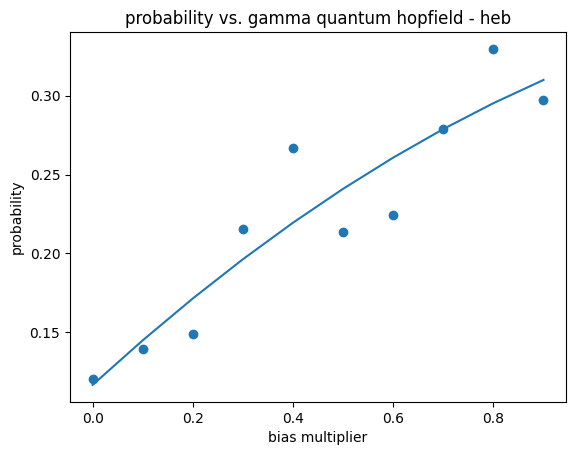

In [ ]:
network = QuantumHopfield()
path_heb = "data\exp1_1_heb.json"
test_state_heb = None
test_state_heb = execute_ex1_1(network, path_heb)
test_state_heb = execute_ex1_1(network, path_heb, test_state_heb)
plot_ex1_1(test_state_heb)

In [29]:
best_biases["heb"] = 0.8

storkey

Connected to Advantage Advantage_system6.4.
generate test state
doing gamma: 0.0 repetition: 1
doing gamma: 0.0 repetition: 2
doing gamma: 0.0 repetition: 3
doing gamma: 0.0 repetition: 4
doing gamma: 0.0 repetition: 5
doing gamma: 0.0 repetition: 6
doing gamma: 0.0 repetition: 7
doing gamma: 0.0 repetition: 8
doing gamma: 0.0 repetition: 9
doing gamma: 0.0 repetition: 10
doing gamma: 0.1 repetition: 1
doing gamma: 0.1 repetition: 2
doing gamma: 0.1 repetition: 3
doing gamma: 0.1 repetition: 4
doing gamma: 0.1 repetition: 5
doing gamma: 0.1 repetition: 6
doing gamma: 0.1 repetition: 7
doing gamma: 0.1 repetition: 8
doing gamma: 0.1 repetition: 9
doing gamma: 0.1 repetition: 10
doing gamma: 0.2 repetition: 1
doing gamma: 0.2 repetition: 2
doing gamma: 0.2 repetition: 3
doing gamma: 0.2 repetition: 4
doing gamma: 0.2 repetition: 5
doing gamma: 0.2 repetition: 6
doing gamma: 0.2 repetition: 7
doing gamma: 0.2 repetition: 8
doing gamma: 0.2 repetition: 9
doing gamma: 0.2 repetition: 10
doi

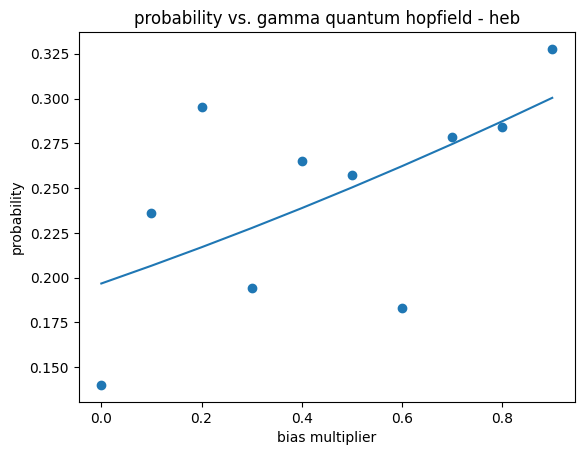

In [ ]:
network = QuantumHopfield(rule = "storkey")
path = "data\exp1_1_storkey.json"
state_exp1_1_storkey = execute_ex1_1(network, path)
state_exp1_1_storkey = execute_ex1_1(network, path, state_exp1_1_storkey)
plot_ex1_1(state_exp1_1_storkey)

In [30]:
best_biases["storkey"] = 0.8

projection

Connected to Advantage Advantage_system4.1.
generate test state
doing gamma: 0.0 repetition: 1
doing gamma: 0.0 repetition: 2
doing gamma: 0.0 repetition: 3
doing gamma: 0.0 repetition: 4
doing gamma: 0.0 repetition: 5
doing gamma: 0.0 repetition: 6
doing gamma: 0.0 repetition: 7
doing gamma: 0.0 repetition: 8
doing gamma: 0.0 repetition: 9
doing gamma: 0.0 repetition: 10
doing gamma: 0.1 repetition: 1
doing gamma: 0.1 repetition: 2
doing gamma: 0.1 repetition: 3
doing gamma: 0.1 repetition: 4
doing gamma: 0.1 repetition: 5
doing gamma: 0.1 repetition: 6
doing gamma: 0.1 repetition: 7
doing gamma: 0.1 repetition: 8
doing gamma: 0.1 repetition: 9
doing gamma: 0.1 repetition: 10
doing gamma: 0.2 repetition: 1
doing gamma: 0.2 repetition: 2
doing gamma: 0.2 repetition: 3
doing gamma: 0.2 repetition: 4
doing gamma: 0.2 repetition: 5
doing gamma: 0.2 repetition: 6
doing gamma: 0.2 repetition: 7
doing gamma: 0.2 repetition: 8
doing gamma: 0.2 repetition: 9
doing gamma: 0.2 repetition: 10
doi

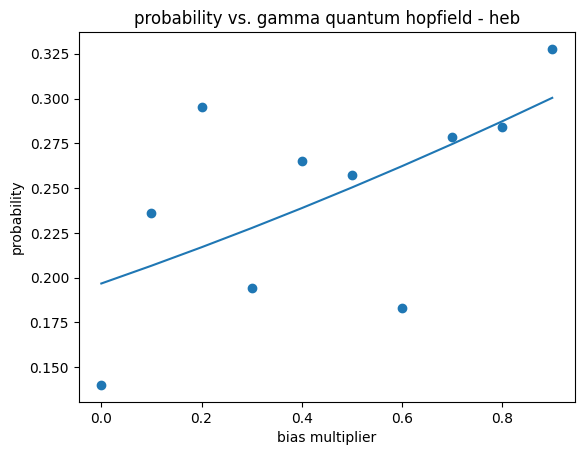

In [ ]:
state_exp1_1_projection = None
network = QuantumHopfield(rule = "projection")
path = "data\exp1_1_projection.json"
state_exp1_1_projection = execute_ex1_1(network, path)
state_exp1_1_projection = execute_ex1_1(network, path, state_exp1_1_projection)
plot_ex1_1(state_exp1_1_storkey)

In [31]:
best_biases["projection"] = 0.8

**dense associative memory**

Rectified polynomial (order 2)

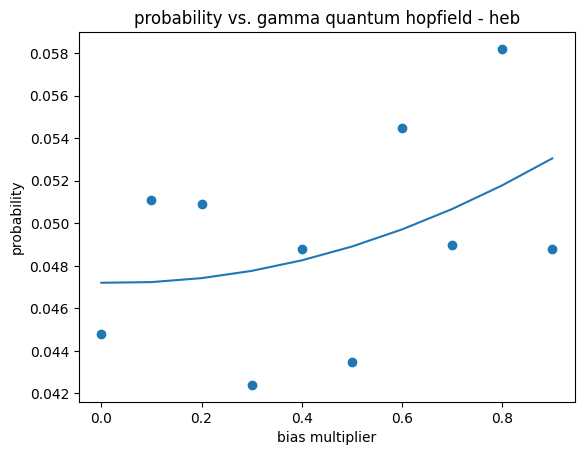

In [192]:
state_exp1_1_relu_third = None
network = QuantumDenseAssociativeMemory(rule = "relu_third")
path = "data\exp1_1_relu_third.json"
state_exp1_1_relu_third = execute_ex1_1(network, path)
state_exp1_1_relu_third = execute_ex1_1(network, path, state_exp1_1_relu_third)
plot_ex1_1(state_exp1_1_relu_third)

In [32]:
best_biases["relu"] = 0.8

Recitified polynomial (order 2) + norm

doing gamma: 0.7000000000000001 repetition: 2


<ipython-input-22-6ff378c2e904>:370: DeprecationWarning: BinaryQuadraticModel.add_offset(bias) is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Please use bqm.offset += bias.
  self._bqm.add_offset(offset)


doing gamma: 0.7000000000000001 repetition: 3
doing gamma: 0.7000000000000001 repetition: 4
doing gamma: 0.7000000000000001 repetition: 5
doing gamma: 0.7000000000000001 repetition: 6
doing gamma: 0.7000000000000001 repetition: 7
doing gamma: 0.7000000000000001 repetition: 8
doing gamma: 0.7000000000000001 repetition: 9
doing gamma: 0.7000000000000001 repetition: 10
doing gamma: 0.8 repetition: 1
doing gamma: 0.8 repetition: 2
doing gamma: 0.8 repetition: 3
doing gamma: 0.8 repetition: 4
doing gamma: 0.8 repetition: 5
doing gamma: 0.8 repetition: 6
doing gamma: 0.8 repetition: 7
doing gamma: 0.8 repetition: 8
doing gamma: 0.8 repetition: 9
doing gamma: 0.8 repetition: 10
doing gamma: 0.9 repetition: 1
doing gamma: 0.9 repetition: 2
doing gamma: 0.9 repetition: 3
doing gamma: 0.9 repetition: 4
doing gamma: 0.9 repetition: 5
doing gamma: 0.9 repetition: 6
doing gamma: 0.9 repetition: 7
doing gamma: 0.9 repetition: 8
doing gamma: 0.9 repetition: 9
doing gamma: 0.9 repetition: 10


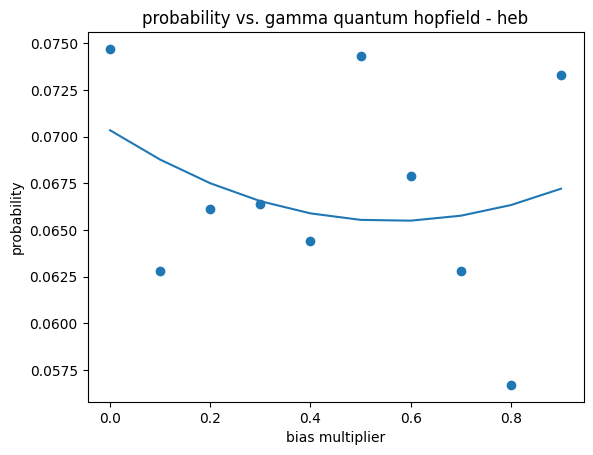

In [ ]:
state_exp1_1_centroid_relu_third = None
network = QuantumDenseAssociativeMemory(rule = "centroid_relu_third")
path = "data\exp1_1_centroid_relu_third.json"
state_exp1_1_centroid_relu_third = execute_ex1_1(network, path)
state_exp1_1_centroid_relu_third = execute_ex1_1(network, path, state_exp1_1_centroid_relu_third)
plot_ex1_1(state_exp1_1_centroid_relu_third)

In [33]:
best_biases["relu+norm"] = 0.8

Exponential

doing gamma: 0.8 repetition: 8


<ipython-input-169-479acacc416a>:375: DeprecationWarning: BinaryQuadraticModel.add_offset(bias) is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Please use bqm.offset += bias.
  self._bqm.add_offset(offset)


doing gamma: 0.8 repetition: 9
doing gamma: 0.8 repetition: 10
doing gamma: 0.9 repetition: 1
doing gamma: 0.9 repetition: 2
doing gamma: 0.9 repetition: 3
doing gamma: 0.9 repetition: 4
doing gamma: 0.9 repetition: 5
doing gamma: 0.9 repetition: 6
doing gamma: 0.9 repetition: 7
doing gamma: 0.9 repetition: 8
doing gamma: 0.9 repetition: 9
doing gamma: 0.9 repetition: 10


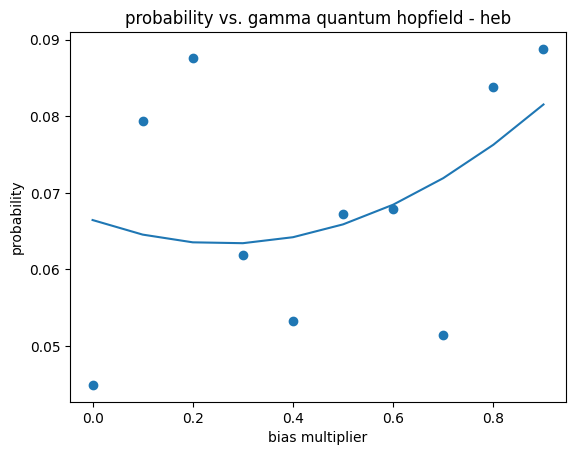

In [ ]:
state_exp1_1_exp_third = None
network = QuantumDenseAssociativeMemory(rule = "exp_third")
path = "data\exp1_1_exp_third.json"
state_exp1_1_exp_third = execute_ex1_1(network, path)
state_exp1_1_exp_third = execute_ex1_1(network, path, state_exp1_1_exp_third)
plot_ex1_1(state_exp1_1_exp_third)

In [34]:
best_biases["exp"] = 0.8

Exponential + norm

doing gamma: 0.0 repetition: 5


<ipython-input-169-479acacc416a>:375: DeprecationWarning: BinaryQuadraticModel.add_offset(bias) is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Please use bqm.offset += bias.
  self._bqm.add_offset(offset)


doing gamma: 0.0 repetition: 6
doing gamma: 0.0 repetition: 7
doing gamma: 0.0 repetition: 8
doing gamma: 0.0 repetition: 9
doing gamma: 0.0 repetition: 10
doing gamma: 0.1 repetition: 1
doing gamma: 0.1 repetition: 2
doing gamma: 0.1 repetition: 3
doing gamma: 0.1 repetition: 4
doing gamma: 0.1 repetition: 5
doing gamma: 0.1 repetition: 6
doing gamma: 0.1 repetition: 7
doing gamma: 0.1 repetition: 8
doing gamma: 0.1 repetition: 9
doing gamma: 0.1 repetition: 10
doing gamma: 0.2 repetition: 1
doing gamma: 0.2 repetition: 2
doing gamma: 0.2 repetition: 3
doing gamma: 0.2 repetition: 4
doing gamma: 0.2 repetition: 5
doing gamma: 0.2 repetition: 6
doing gamma: 0.2 repetition: 7
doing gamma: 0.2 repetition: 8
doing gamma: 0.2 repetition: 9
doing gamma: 0.2 repetition: 10
doing gamma: 0.30000000000000004 repetition: 1
doing gamma: 0.30000000000000004 repetition: 2
doing gamma: 0.30000000000000004 repetition: 3
doing gamma: 0.30000000000000004 repetition: 4
doing gamma: 0.30000000000000004 r

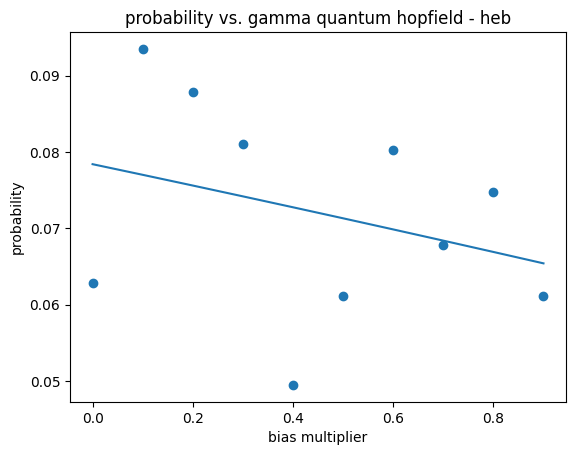

In [ ]:
state_exp1_1_centroid_exp_third = None
network = QuantumDenseAssociativeMemory(rule = "centroid_exp_third")
path = "data\exp1_1_centroid_exp_third.json"
state_exp1_1_centroid_exp_third = execute_ex1_1(network, path)
state_exp1_1_centroid_exp_third = execute_ex1_1(network, path, state_exp1_1_centroid_exp_third)
plot_ex1_1(state_exp1_1_centroid_exp_third)

In [35]:
best_biases["exp+norm"] = 0.1

####**5.1.2 second experiment - test annealing time and number of samples influence**




#####**5.1.2.1 second experiment - test annealing time influence**


**content**

As first experiment but changing T (minimo possibile 0.5, standard 20,50,100,500, massimo possibile 2000 ), using following gamma values
- hebb gamma=0.5
- storkey gamma=0.15
- projection gamma=0.15



In [24]:
def execute_ex1_2_1(network, path, test_state = None, bias_mult = None):
    if test_state is not None:
      for matrix_dims in test_state:
          for anneal_time in test_state[matrix_dims]:
              i = 1
              for result_state in test_state[matrix_dims][anneal_time]:
                  if result_state["done"] == False:
                      print("doing dim " + "("+matrix_dims+")"+ " anneal time: " + str(anneal_time) + " repetition: " + str(i))
                      result_state["data_dict"] = get_data_exp1_1(num_mem = int(list(matrix_dims.split(" "))[0]), num_neurons = int(list(matrix_dims.split(" "))[1]))
                      network.set_memories(np.asarray(result_state["data_dict"]["data_bipolar"]))
                      network.set_bias(np.asarray(result_state["data_dict"]["bias_bipolar"]), bias_mult = bias_mult)
                      result_state["result_dict"] = network.update(annealing_time = float(anneal_time))
                      result_state["done"] = True
                      # save test state
                      with open(path, "w") as outfile:
                          json.dump(test_state, outfile)
                  i = i + 1
    else:
        print("generate test state")
        test_state = {}
        for dim1 in range(4, 13, 4):
          for dim2 in range(4, 13, 4):
            lab = str(dim1)+" "+str(dim2)
            test_state[lab] = {}
            for anneal_time in [network._qpu_advantage.properties["annealing_time_range"][0], 20, 50, 100, 500]:
                test_state[lab][anneal_time] = []
                for i in range(1):
                    test_state[lab][anneal_time].append(copy.deepcopy(RESULT_STATE_TEMPLATE))
            # save test state
            with open(path, "w") as outfile:
                json.dump(test_state, outfile)
    return test_state

In [25]:
def plot_ex1_2_1(test_state, network_name = "quantum hopfield - heb"):
    for matrix_dims in test_state:
        title = "probability vs. anneal time " + network_name + " dim1: " + str((list(matrix_dims.split(" ")[0]))) + " dim2: " + str((list(matrix_dims.split(" ")[1])))
        x = []
        x_label = "bias multiplier"
        y = []
        y_label = "probability"
        for anneal_time in test_state[matrix_dims]:
          x.append(float(anneal_time))
          temp_y = []
          for iter in range(len(test_state[matrix_dims][anneal_time])):
              correct_mem = np.asarray(test_state[matrix_dims][anneal_time][iter]["data_dict"]["bias_bipolar"])
              proportion = 0
              for res in test_state[matrix_dims][anneal_time][iter]["result_dict"]["all_samples"]:
                  res_np = np.asarray(list(map(int, res.split(" "))))
                  if np.array_equal(res_np, correct_mem):
                      proportion = proportion + test_state[matrix_dims][anneal_time][iter]["result_dict"]["all_samples"][res]
              temp_y.append(proportion)
          y.append(sum(temp_y) / len(temp_y))
        plotTrend2D(title, x_label, x, y_label, y)

**quantum hopfield**

hebb

doing dim (8 8) anneal time: 100 repetition: 3
doing dim (8 8) anneal time: 100 repetition: 4
doing dim (8 8) anneal time: 100 repetition: 5
doing dim (8 8) anneal time: 500 repetition: 1
doing dim (8 8) anneal time: 500 repetition: 2
doing dim (8 8) anneal time: 500 repetition: 3
doing dim (8 8) anneal time: 500 repetition: 4
doing dim (8 8) anneal time: 500 repetition: 5
doing dim (8 12) anneal time: 0.5 repetition: 1
doing dim (8 12) anneal time: 0.5 repetition: 2
doing dim (8 12) anneal time: 0.5 repetition: 3
doing dim (8 12) anneal time: 0.5 repetition: 4
doing dim (8 12) anneal time: 0.5 repetition: 5
doing dim (8 12) anneal time: 20 repetition: 1
doing dim (8 12) anneal time: 20 repetition: 2
doing dim (8 12) anneal time: 20 repetition: 3
doing dim (8 12) anneal time: 20 repetition: 4
doing dim (8 12) anneal time: 20 repetition: 5
doing dim (8 12) anneal time: 50 repetition: 1
doing dim (8 12) anneal time: 50 repetition: 2
doing dim (8 12) anneal time: 50 repetition: 3
doing di

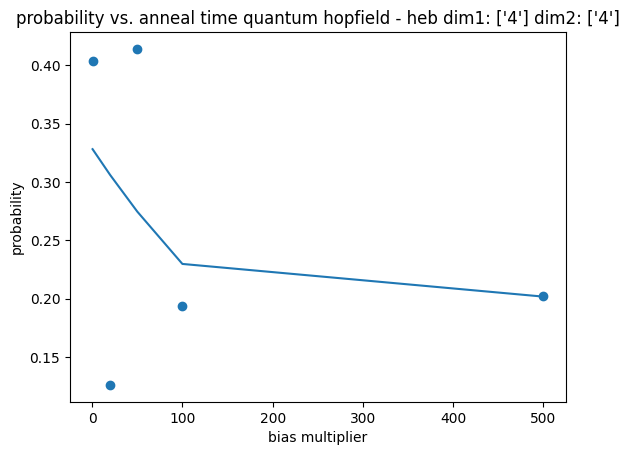

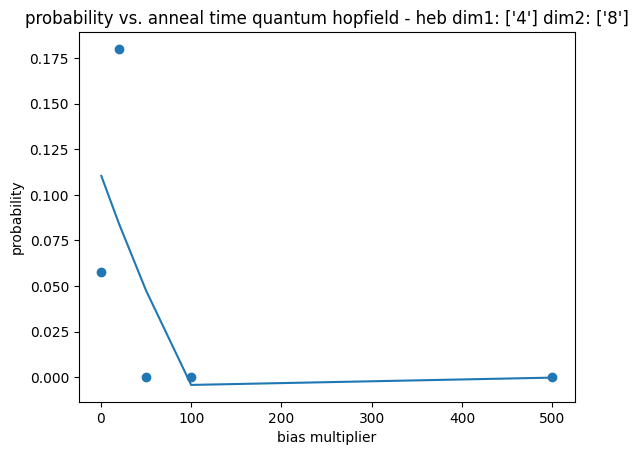

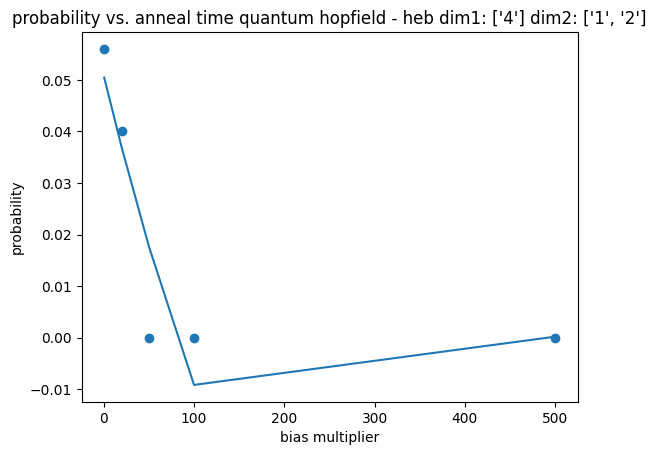

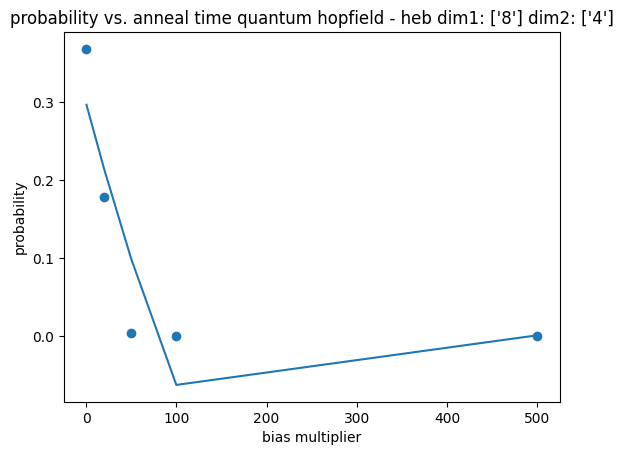

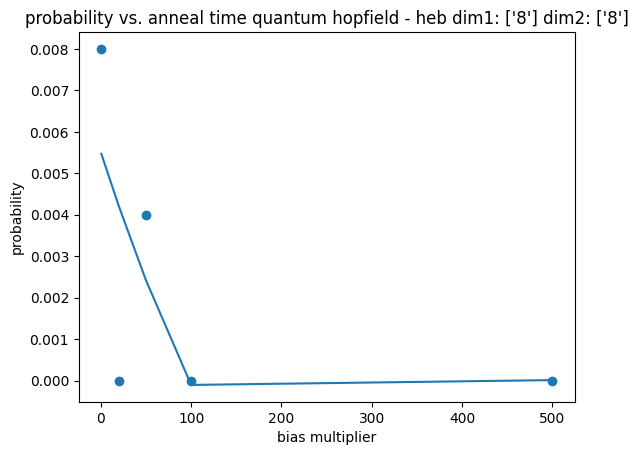

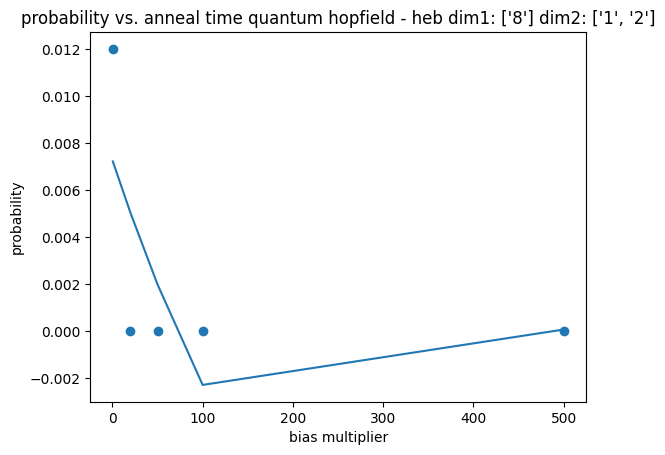

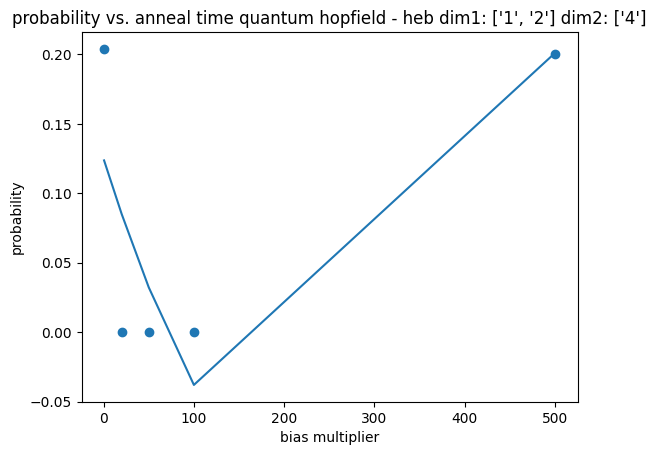

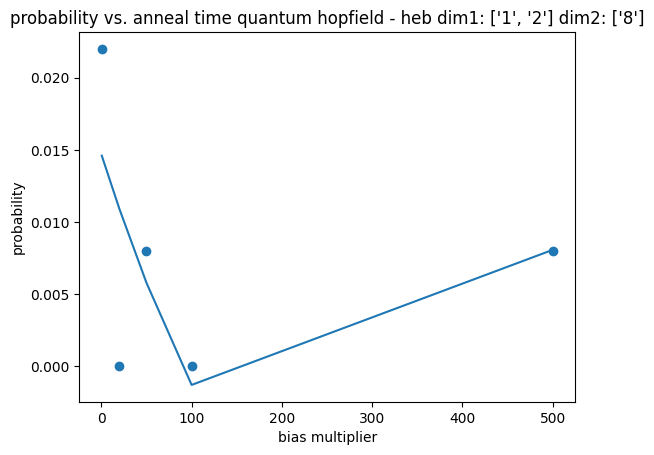

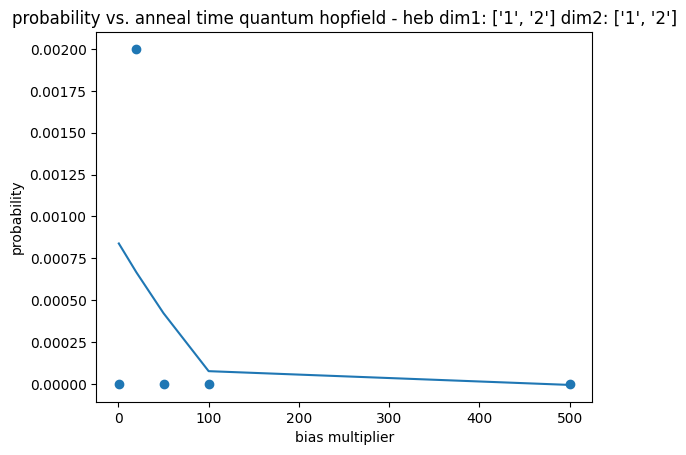

In [ ]:
network = QuantumHopfield()
path_heb = "data\exp1_2_1_heb.json"
test_state_heb = None
test_state_heb = execute_ex1_2_1(network, path_heb)
test_state_heb = execute_ex1_2_1(network, path_heb, test_state_heb, bias_mult = best_biases["heb"])
plot_ex1_2_1(test_state_heb)

storkey

In [ ]:
#test_state_storkey = None
#with open("data\exp1_2_1_storkey.json", "r") as outfile:
#    test_state_storkey = json.load(outfile)

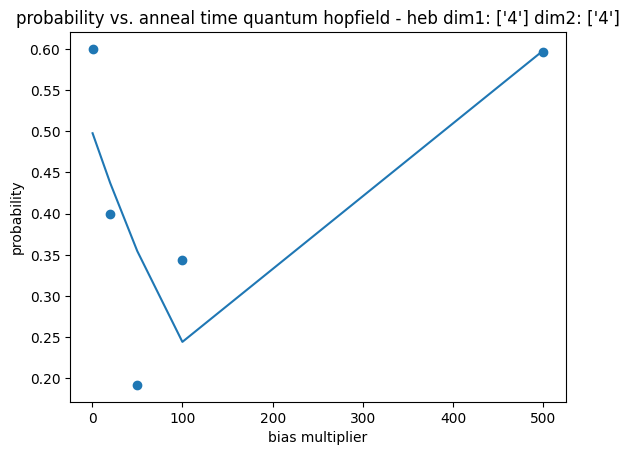

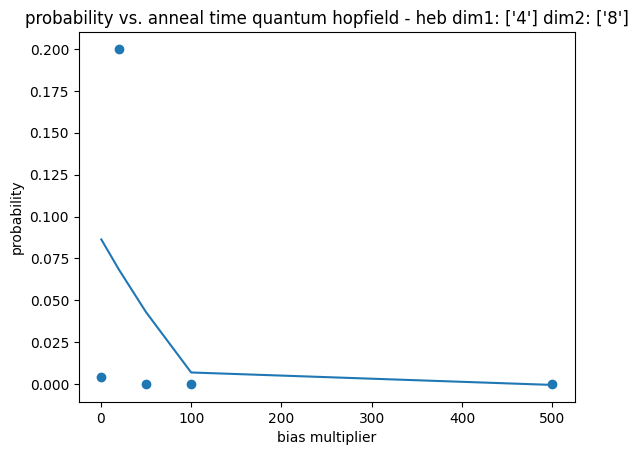

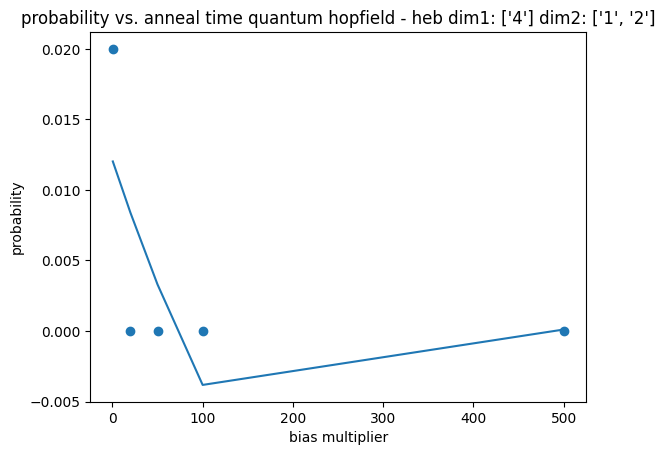

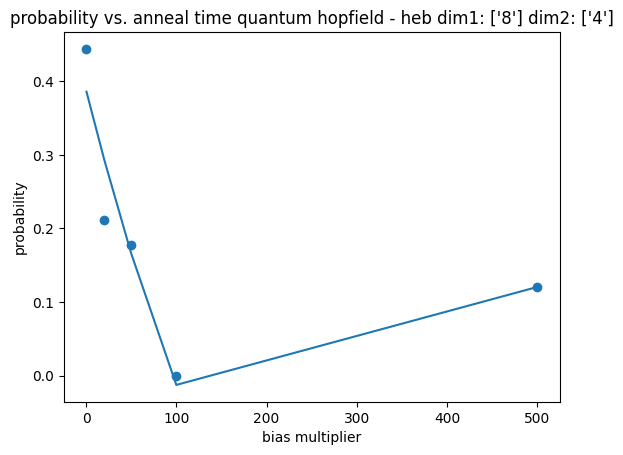

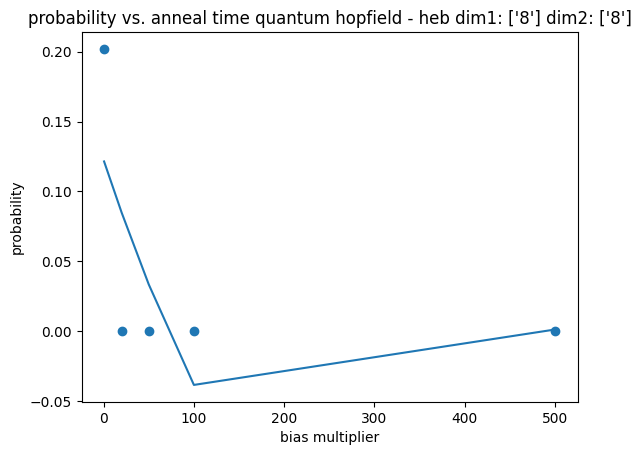

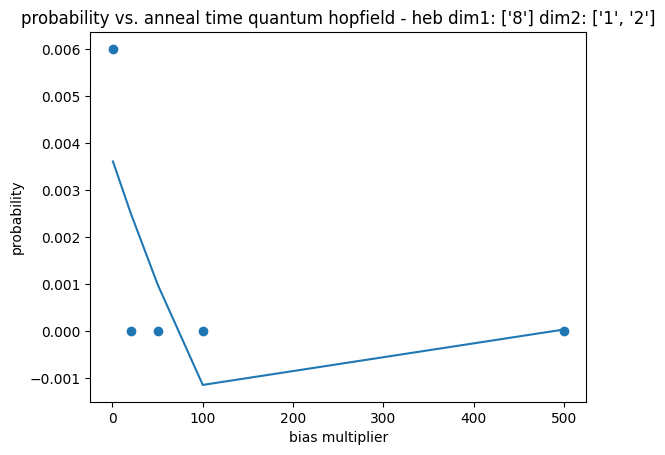

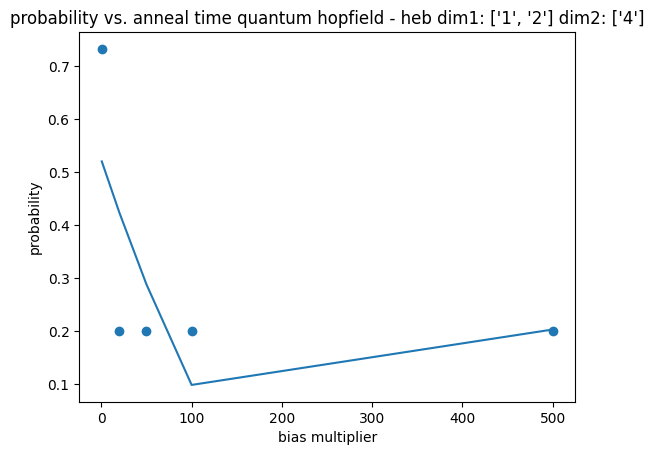

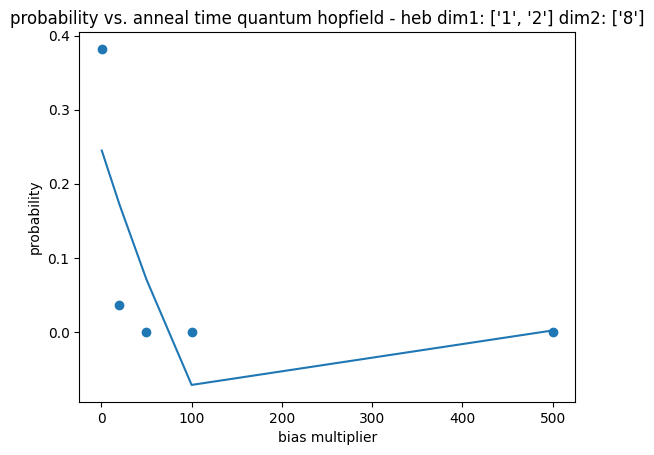

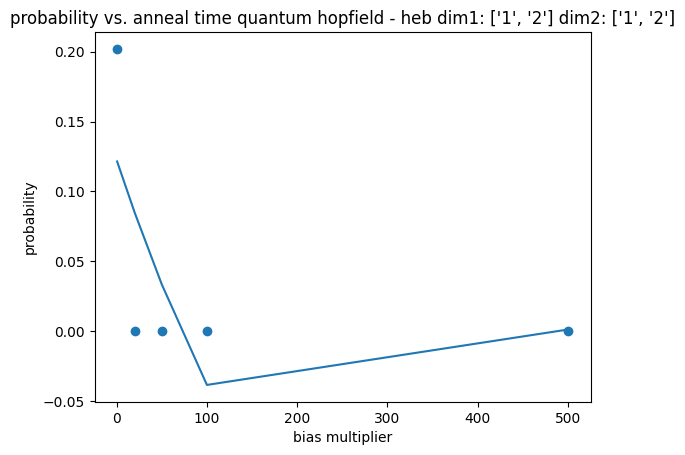

In [ ]:
network = QuantumHopfield(rule = "storkey")
path_storkey = "data\exp1_2_1_storkey.json"
test_state_storkey = None
test_state_storkey = execute_ex1_2_1(network, path_storkey)
test_state_storkey = execute_ex1_2_1(network, path_storkey, test_state_storkey, bias_mult = best_biases["storkey"])
plot_ex1_2_1(test_state_storkey)

projection

doing dim (8 12) anneal time: 50 repetition: 5
doing dim (8 12) anneal time: 100 repetition: 1
doing dim (8 12) anneal time: 100 repetition: 2
doing dim (8 12) anneal time: 100 repetition: 3
doing dim (8 12) anneal time: 100 repetition: 4
doing dim (8 12) anneal time: 100 repetition: 5
doing dim (8 12) anneal time: 500 repetition: 1
doing dim (8 12) anneal time: 500 repetition: 2
doing dim (8 12) anneal time: 500 repetition: 3
doing dim (8 12) anneal time: 500 repetition: 4
doing dim (8 12) anneal time: 500 repetition: 5
doing dim (12 4) anneal time: 0.5 repetition: 1
doing dim (12 4) anneal time: 0.5 repetition: 2
doing dim (12 4) anneal time: 0.5 repetition: 3
doing dim (12 4) anneal time: 0.5 repetition: 4
doing dim (12 4) anneal time: 0.5 repetition: 5
doing dim (12 4) anneal time: 20 repetition: 1
doing dim (12 4) anneal time: 20 repetition: 2
doing dim (12 4) anneal time: 20 repetition: 3
doing dim (12 4) anneal time: 20 repetition: 4
doing dim (12 4) anneal time: 20 repetition: 

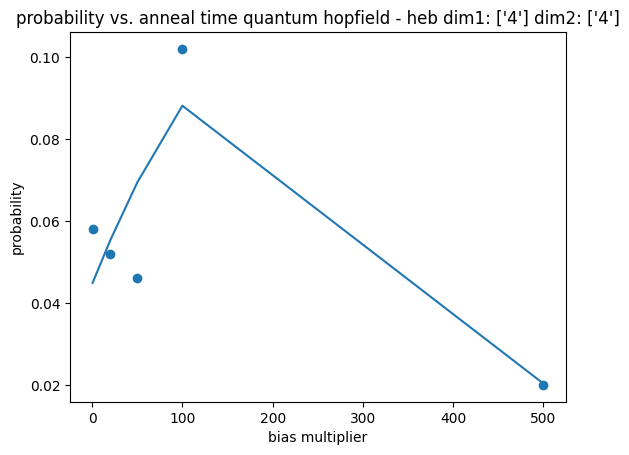

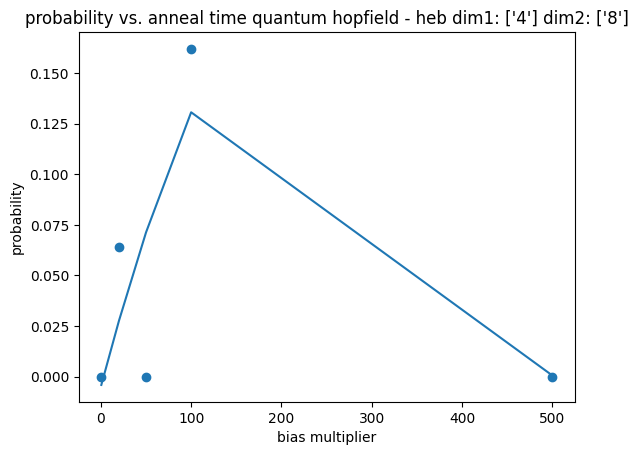

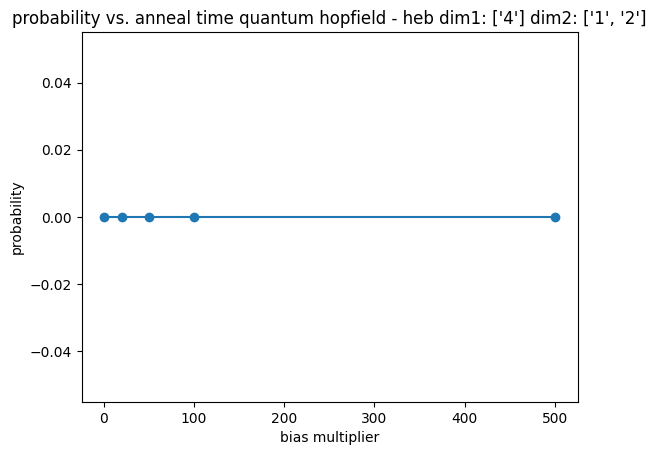

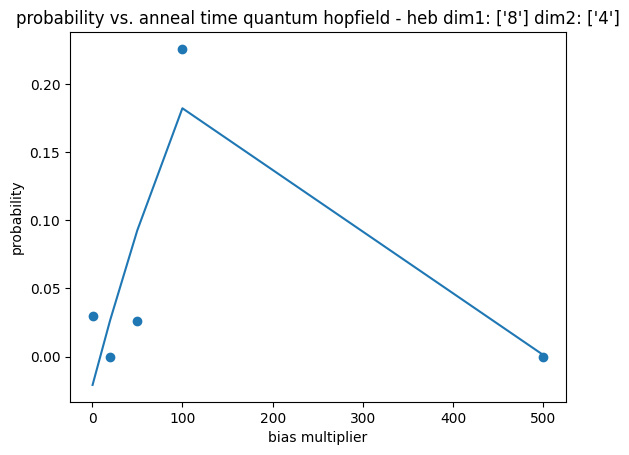

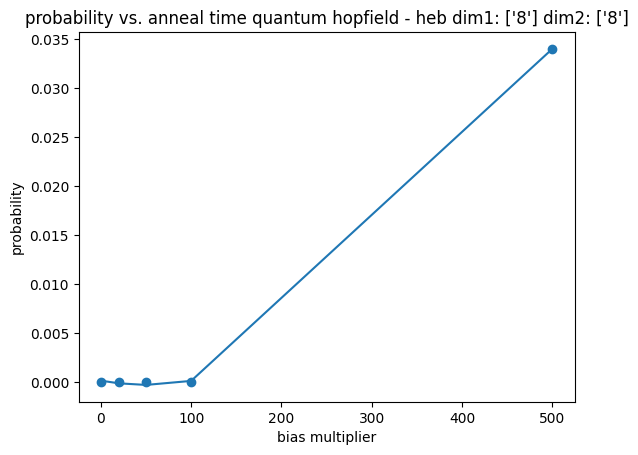

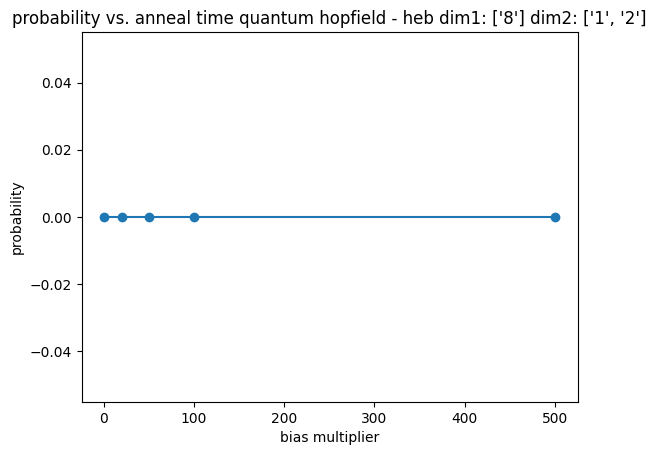

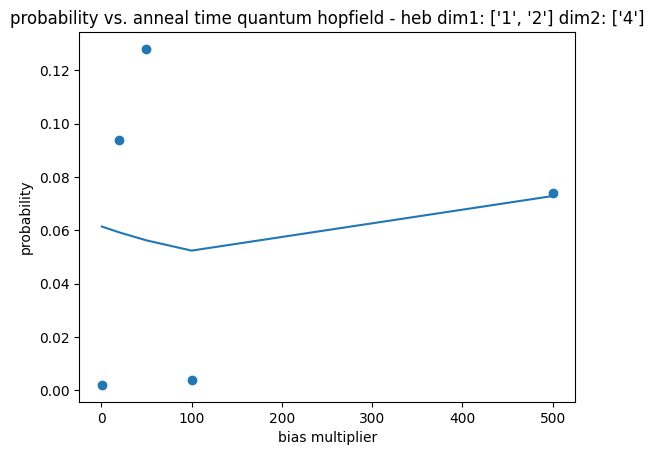

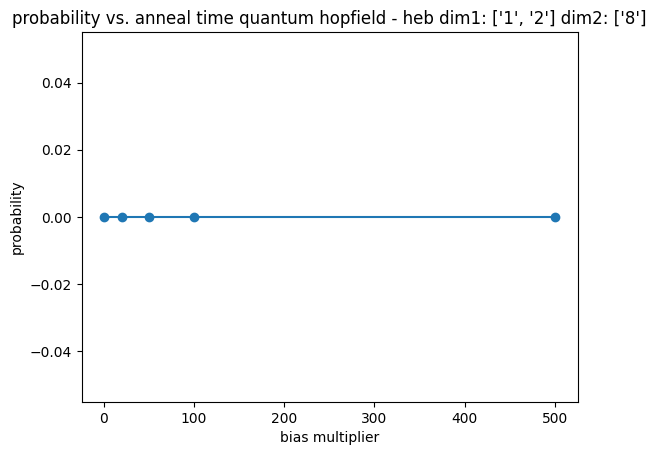

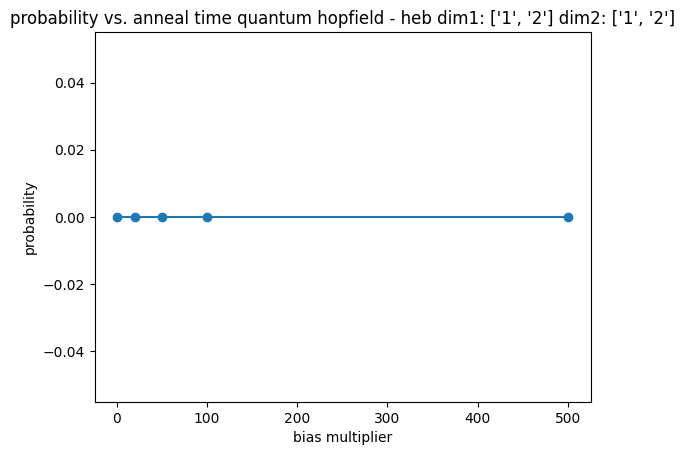

In [ ]:
network = QuantumHopfield(rule = "projection")
path_proj= "data\exp1_2_1_projection.json"
test_state_proj = None
test_state_proj = execute_ex1_2_1(network, path_proj)
test_state_proj = execute_ex1_2_1(network, path_proj, test_state_proj, bias_mult = best_biases["projection"])
plot_ex1_2_1(test_state_proj)

**quantum dense associative memories**

relu

doing dim (12 4) anneal time: 0.5 repetition: 1


<ipython-input-242-ac8df2b44c5d>:378: DeprecationWarning: BinaryQuadraticModel.add_offset(bias) is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Please use bqm.offset += bias.
  self._bqm.add_offset(offset)


{'x_1': x_1, 'x_2': x_2, 'x_3': x_3, 'x_4': x_4}
doing dim (12 4) anneal time: 0.5 repetition: 2
{'x_1': x_1, 'x_2': x_2, 'x_3': x_3, 'x_4': x_4}
doing dim (12 4) anneal time: 0.5 repetition: 3
{'x_1': x_1, 'x_2': x_2, 'x_3': x_3, 'x_4': x_4}
doing dim (12 4) anneal time: 0.5 repetition: 4
{'x_1': x_1, 'x_2': x_2, 'x_3': x_3, 'x_4': x_4}
doing dim (12 4) anneal time: 0.5 repetition: 5
{'x_1': x_1, 'x_2': x_2, 'x_3': x_3, 'x_4': x_4}
doing dim (12 4) anneal time: 20 repetition: 1
{'x_1': x_1, 'x_2': x_2, 'x_3': x_3, 'x_4': x_4}
doing dim (12 4) anneal time: 20 repetition: 2
{'x_1': x_1, 'x_2': x_2, 'x_3': x_3, 'x_4': x_4}
doing dim (12 4) anneal time: 20 repetition: 3
{'x_1': x_1, 'x_2': x_2, 'x_3': x_3, 'x_4': x_4}
doing dim (12 4) anneal time: 20 repetition: 4
{'x_1': x_1, 'x_2': x_2, 'x_3': x_3, 'x_4': x_4}
doing dim (12 4) anneal time: 20 repetition: 5
{'x_1': x_1, 'x_2': x_2, 'x_3': x_3, 'x_4': x_4}
doing dim (12 4) anneal time: 50 repetition: 1
{'x_1': x_1, 'x_2': x_2, 'x_3': x_3,

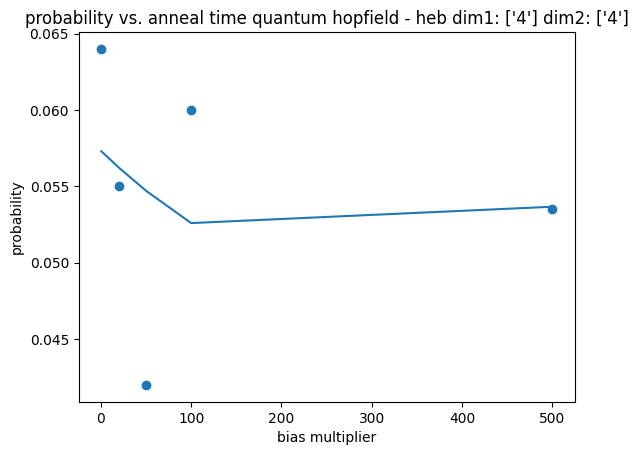

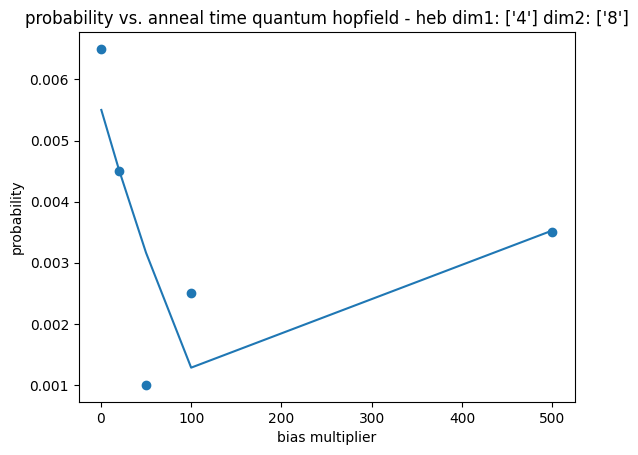

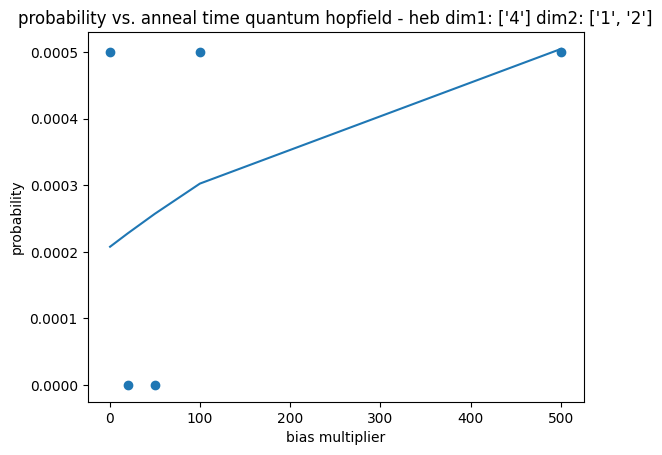

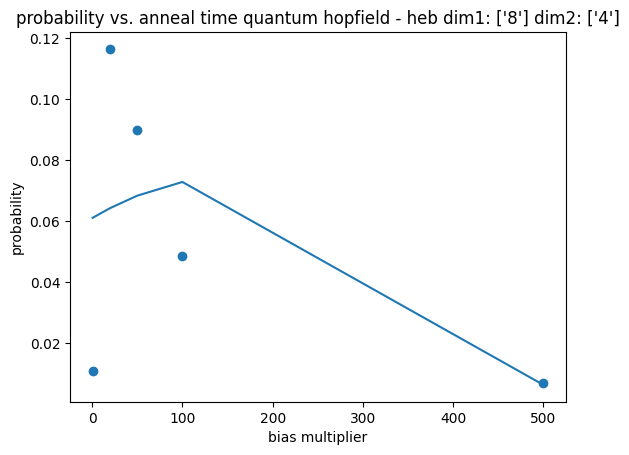

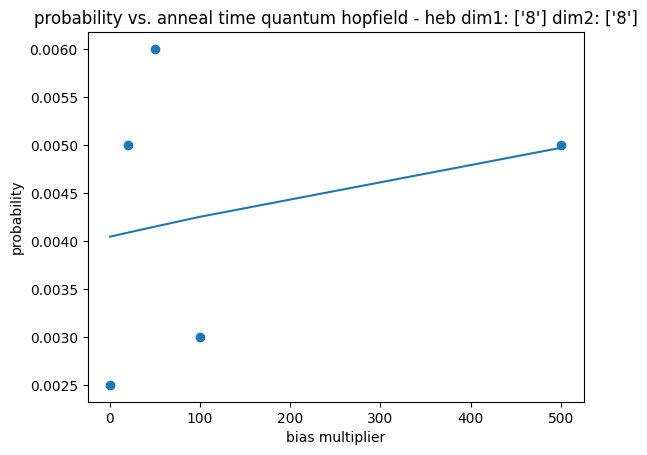

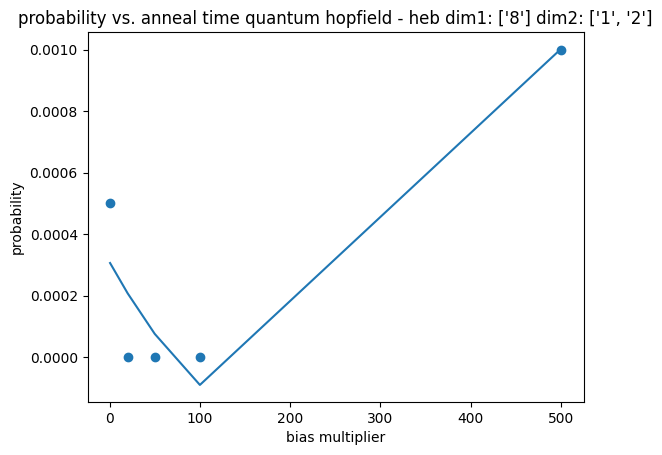

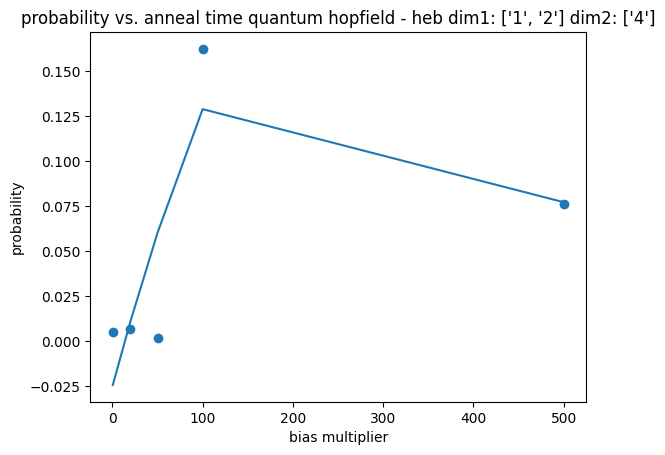

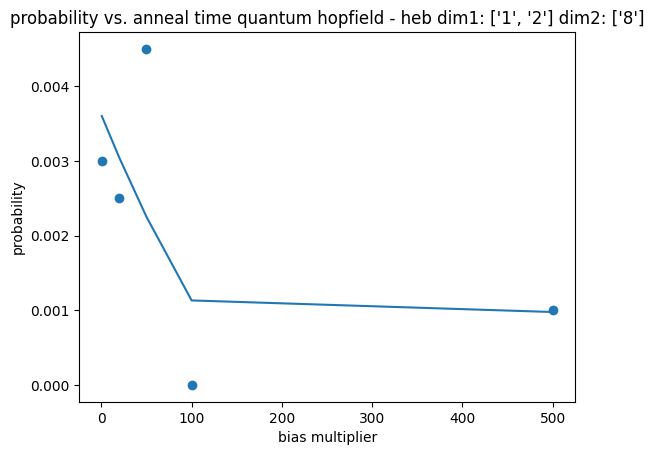

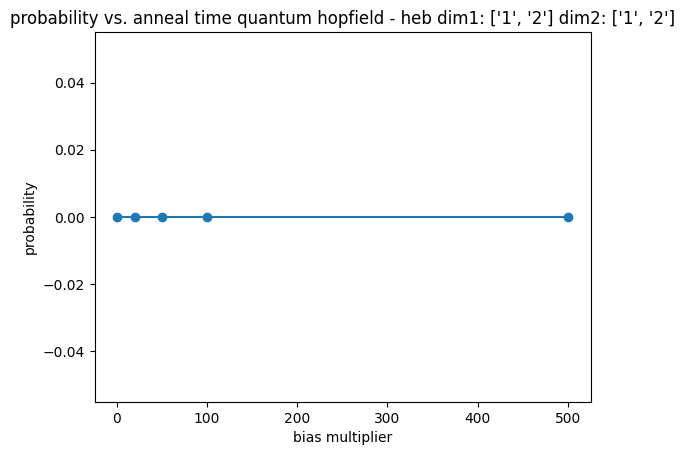

In [244]:
network = QuantumDenseAssociativeMemory(rule = "relu_third")
path_relu = "data\exp1_2_1_relu.json"
test_state_relu = None
test_state_relu = execute_ex1_2_1(network, path_relu)
test_state_relu = execute_ex1_2_1(network, path_relu, test_state_relu, bias_mult = best_biases["relu"])
plot_ex1_2_1(test_state_relu)

relu + norm

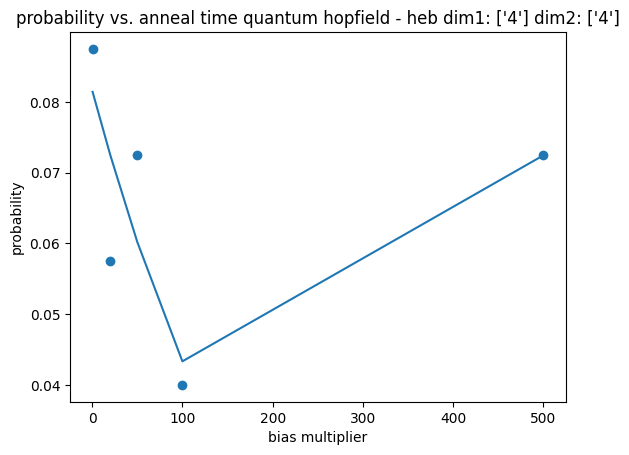

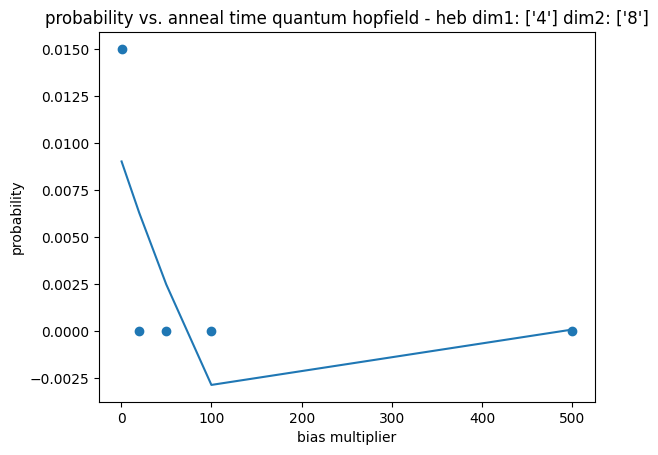

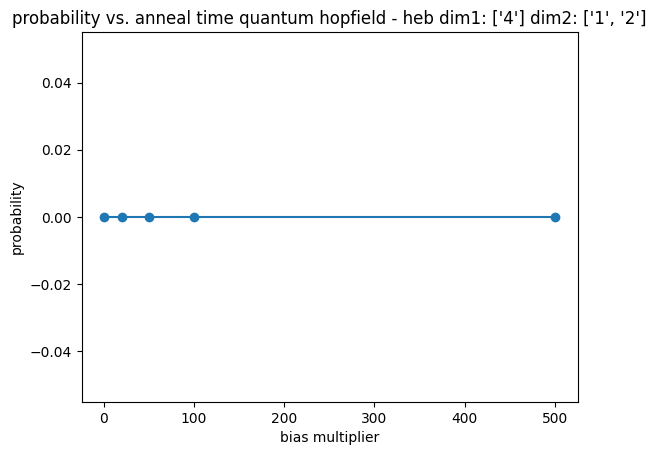

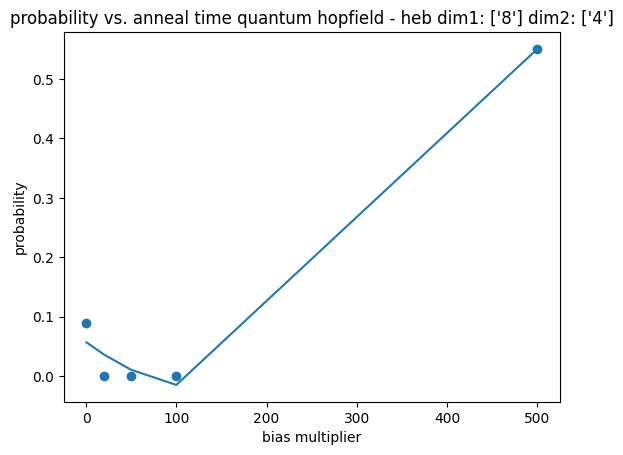

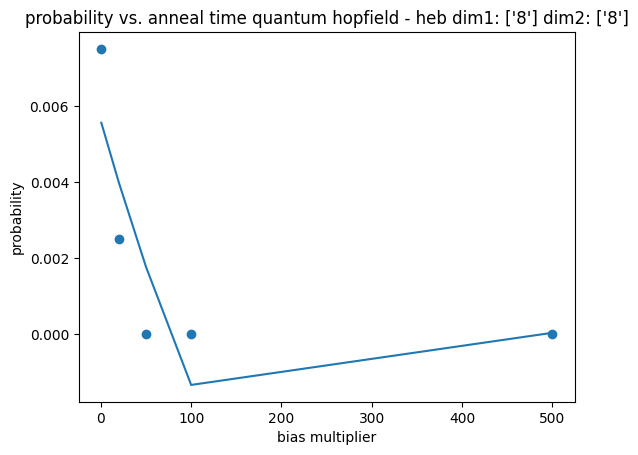

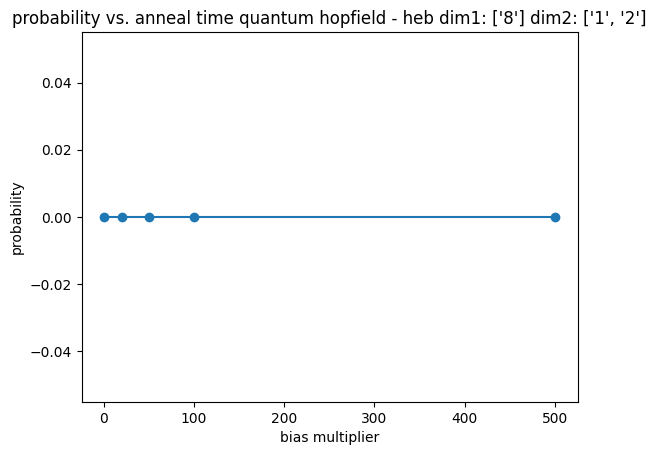

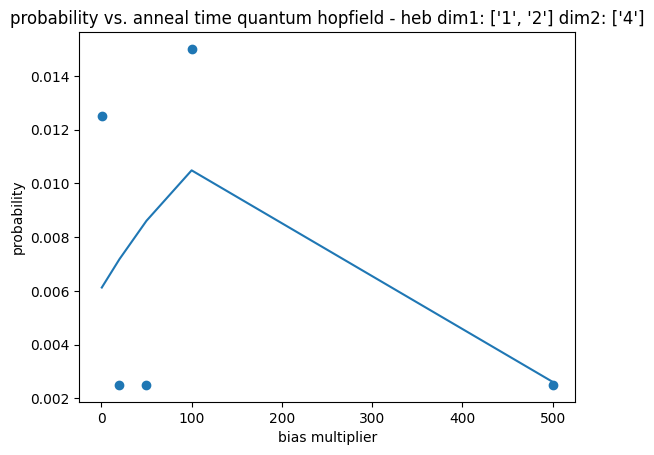

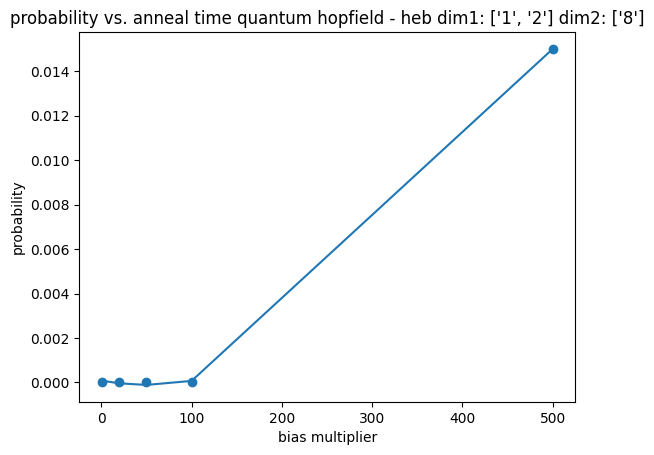

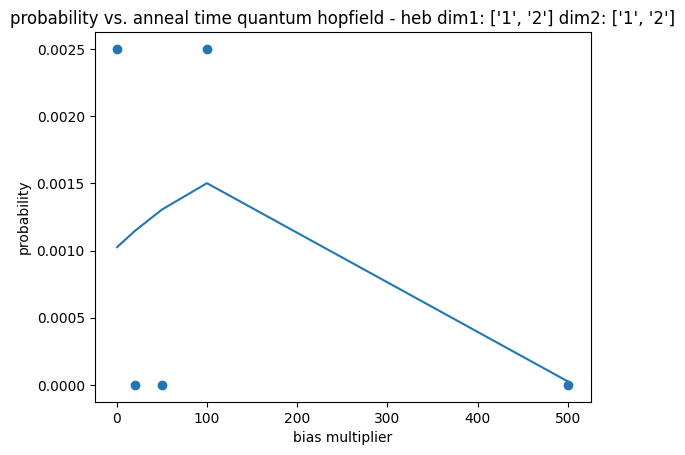

In [254]:
network = QuantumDenseAssociativeMemory(rule = "centroid_relu_third")
path_relu = "data\exp1_2_1_centroid_relu.json"
test_state_relu = None
test_state_relu = execute_ex1_2_1(network, path_relu)
test_state_relu = execute_ex1_2_1(network, path_relu, test_state_relu, bias_mult = best_biases["relu+norm"])
plot_ex1_2_1(test_state_relu)

exp

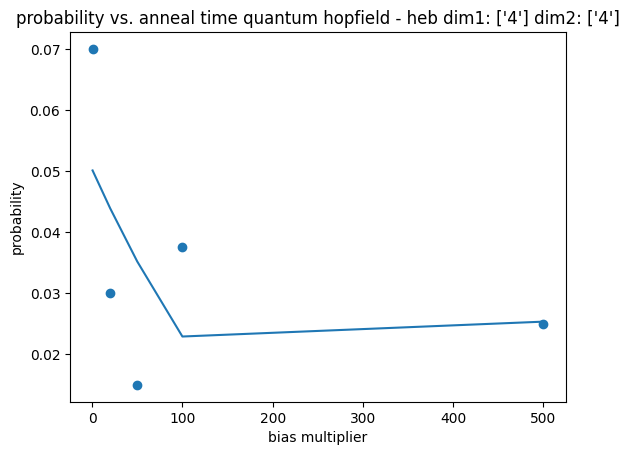

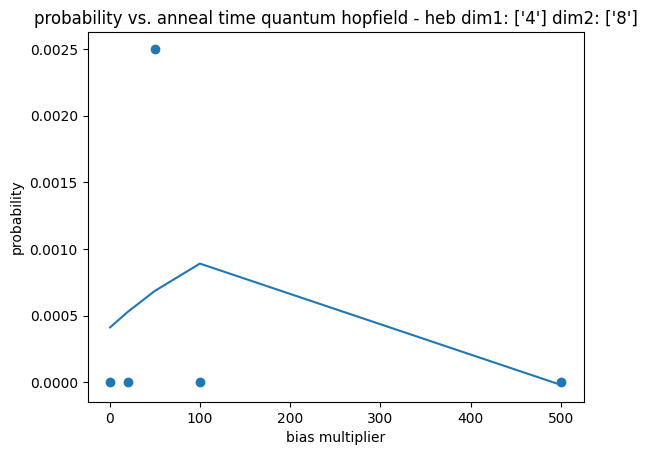

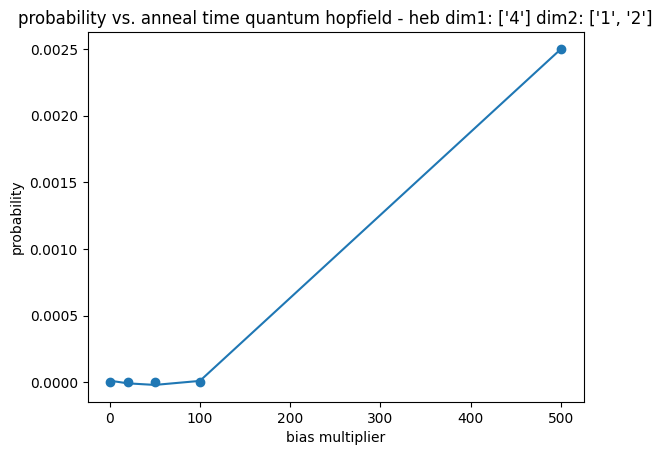

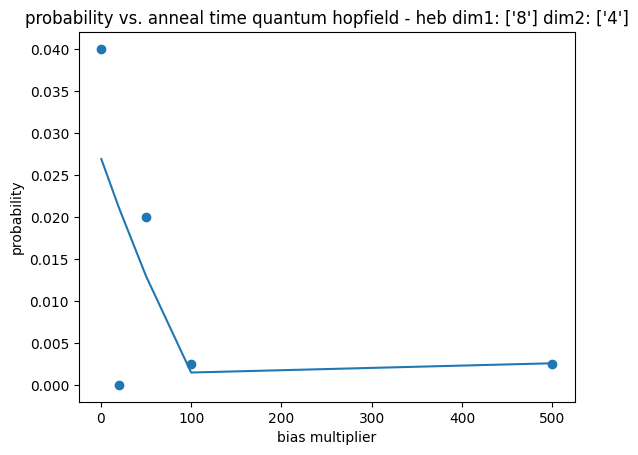

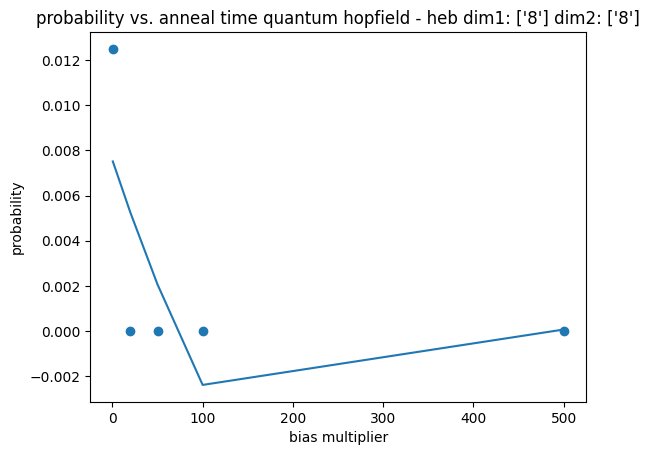

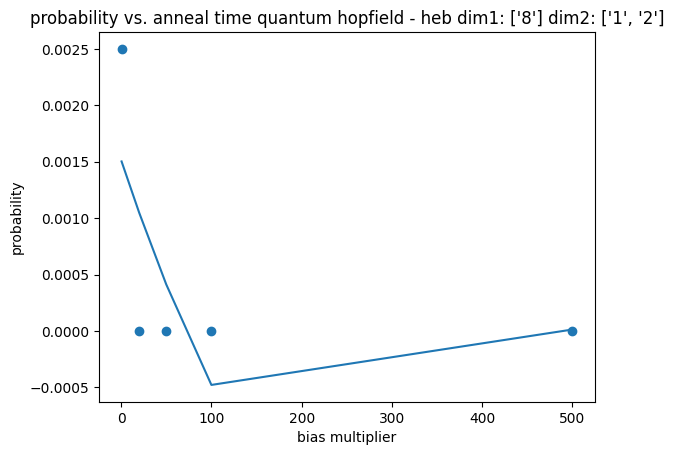

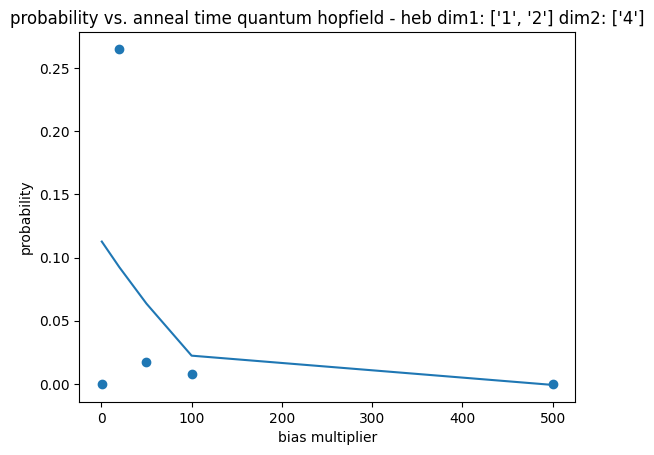

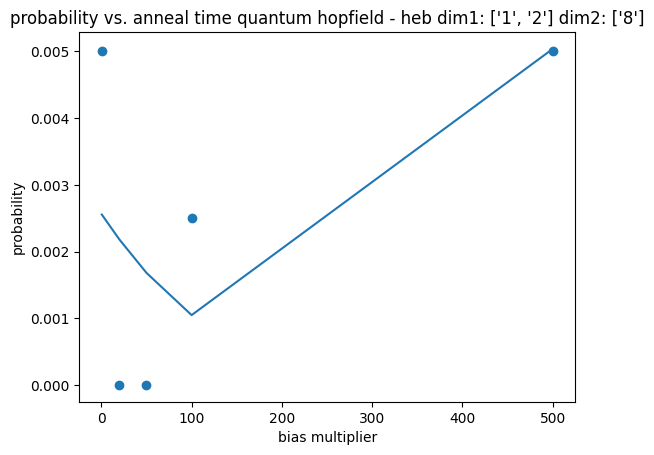

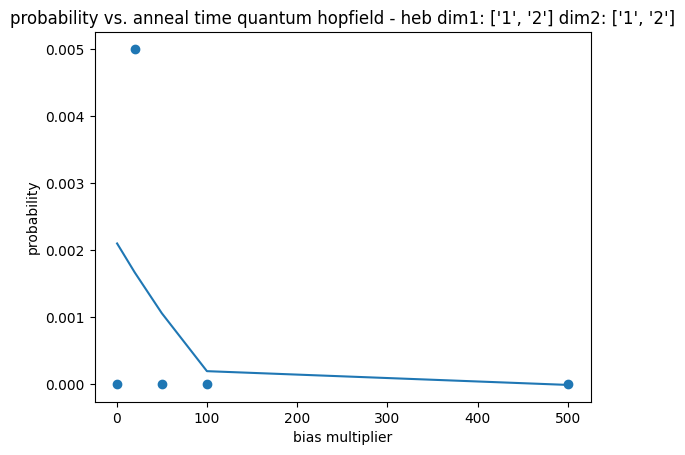

In [265]:
network = QuantumDenseAssociativeMemory(rule = "exp_third")
path_exp = "data\exp1_2_1_exp.json"
test_state_exp = None
test_state_exp = execute_ex1_2_1(network, path_exp)
test_state_exp = execute_ex1_2_1(network, path_exp, test_state_exp, bias_mult = best_biases["exp"])
plot_ex1_2_1(test_state_exp)

exp + norm

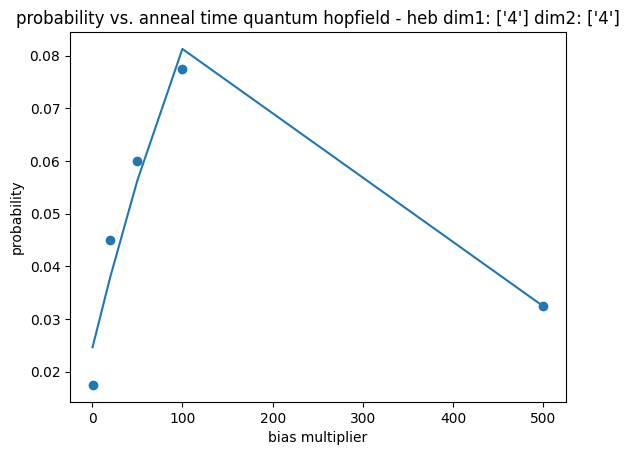

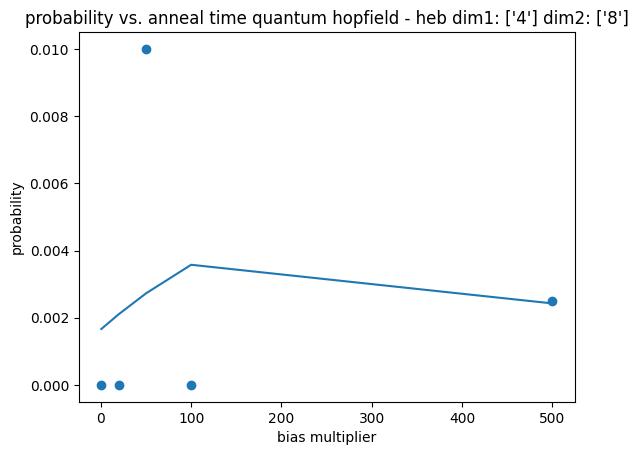

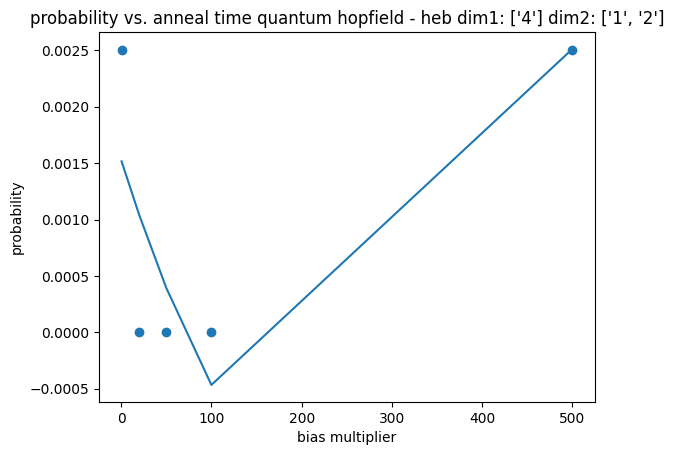

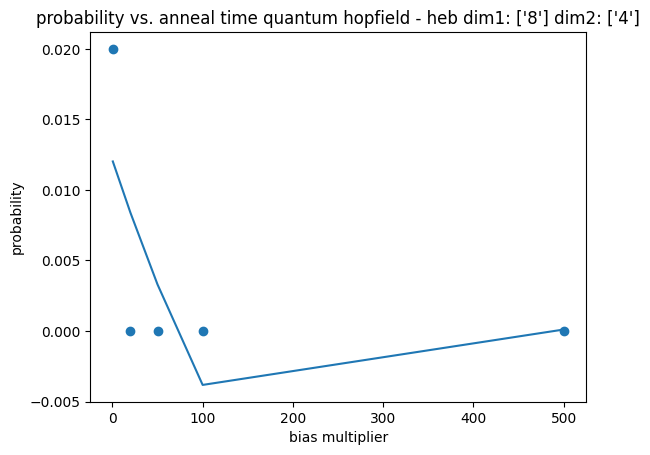

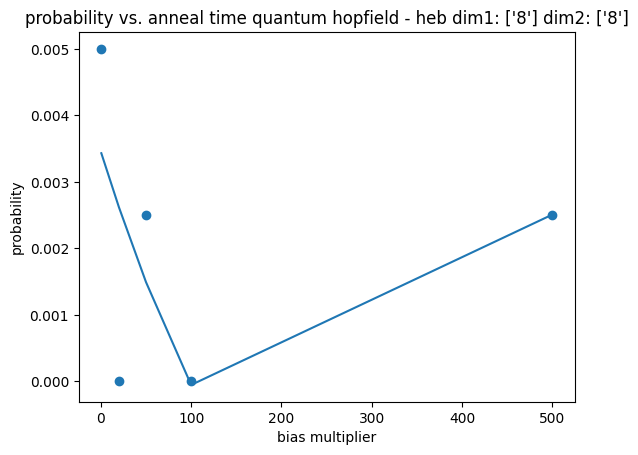

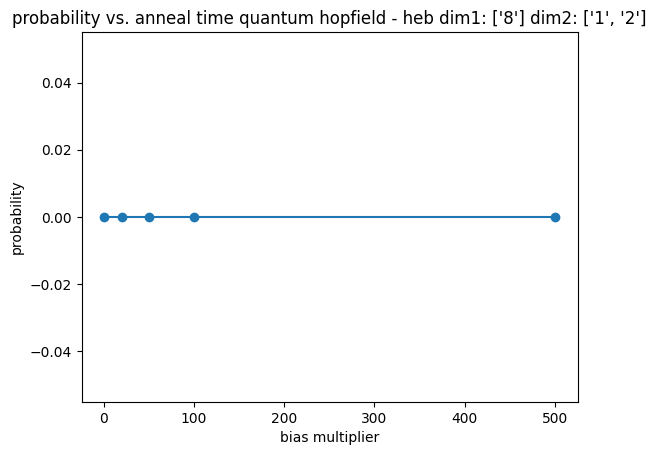

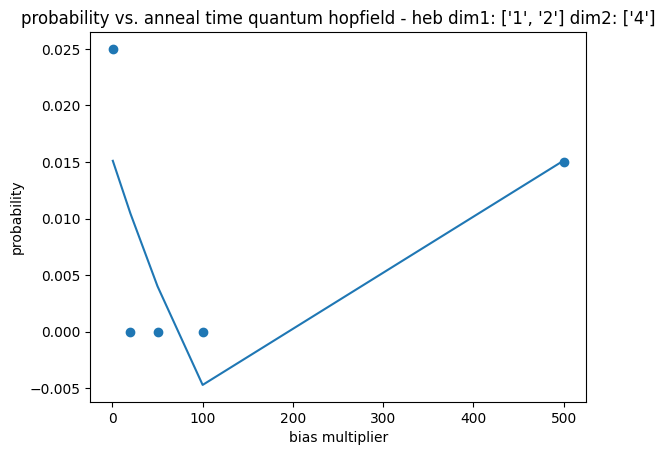

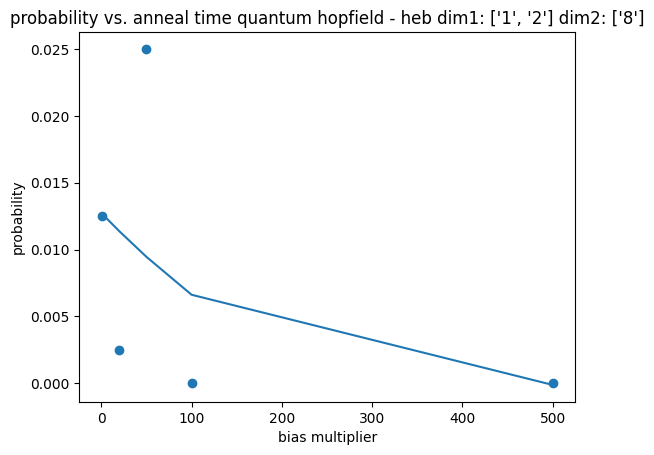

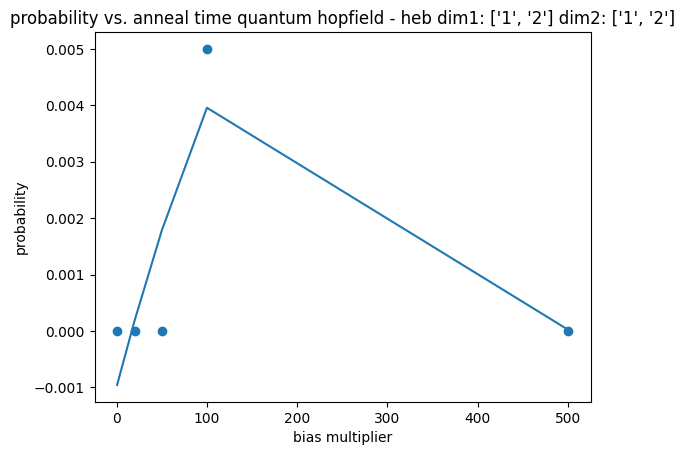

In [42]:
network = QuantumDenseAssociativeMemory(rule = "centroid_exp_third")
path_exp = "data\exp1_2_1_centroid_exp.json"
test_state_exp = None
test_state_exp = execute_ex1_2_1(network, path_exp)
test_state_exp = execute_ex1_2_1(network, path_exp, test_state_exp, bias_mult = best_biases["exp+norm"])
plot_ex1_2_1(test_state_exp)

#####**5.1.2.1 second experiment - test number of sample influence**


we do it also with number of samples

In [93]:
def execute_ex1_2_2(network, path, test_state = None, bias_mult = None, annealing_time = 20):
    if test_state is not None:
      for matrix_dims in test_state:
          for num_samples in test_state[matrix_dims]:
              i = 1
              for result_state in test_state[matrix_dims][num_samples]:
                  if result_state["done"] == False:
                      print("doing dim " + "("+matrix_dims+")"+ " num samples: " + str(num_samples) + " repetition: " + str(i))
                      result_state["data_dict"] = get_data_exp1_1(num_mem = int(list(matrix_dims.split(" "))[0]), num_neurons = int(list(matrix_dims.split(" "))[1]))
                      network.set_memories(np.asarray(result_state["data_dict"]["data_bipolar"]))
                      network.set_bias(np.asarray(result_state["data_dict"]["bias_bipolar"]), bias_mult = bias_mult)
                      result_state["result_dict"] = network.update(num_reads = num_samples, annealing_time = annealing_time)
                      result_state["done"] = True
                      # save test state
                      with open(path, "w") as outfile:
                          json.dump(test_state, outfile)
                  i = i + 1
    else:
        test_state = {}
        for dim1 in range(4, 13, 4):
          for dim2 in range(4, 13, 4):
            lab = str(dim1)+" "+str(dim2)
            test_state[lab] = {}
            for num_samples in range(1000, 30001, 1000):
                test_state[lab][num_samples] = []
                for i in range(1):
                    test_state[lab][num_samples].append(copy.deepcopy(RESULT_STATE_TEMPLATE))
            # save test state
            with open(path, "w") as outfile:
                json.dump(test_state, outfile)
    return test_state

In [64]:
def plot_ex1_2_2(test_state, network_name = "quantum hopfield - heb"):
    for matrix_dims in test_state:
        title = "probability vs. num samples " + network_name + " dim1: " + str((list(matrix_dims.split(" ")[0]))) + " dim2: " + str((list(matrix_dims.split(" ")[1])))
        x = []
        x_label = "bias multiplier"
        y = []
        y_label = "probability"
        for num_samples in test_state[matrix_dims]:
          x.append(num_samples)
          temp_y = []
          for iter in range(len(test_state[matrix_dims][num_samples])):
              correct_mem = np.asarray(test_state[matrix_dims][num_samples][iter]["data_dict"]["bias_bipolar"])
              counter = 0
              res = test_state[matrix_dims][num_samples][iter]["result_dict"]["lowest_energy_sample"]
              res_np = np.asarray(res)
              if np.array_equal(res_np, correct_mem):
                  counter = 1
              temp_y.append(counter)
          y.append(sum(temp_y) / len(temp_y))
        plotTrend2D(title, x_label, x, y_label, y)

**Quantum Hopfield**

hebb

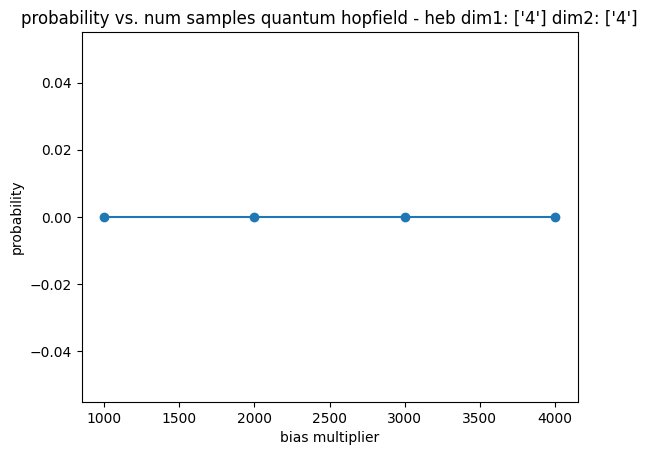

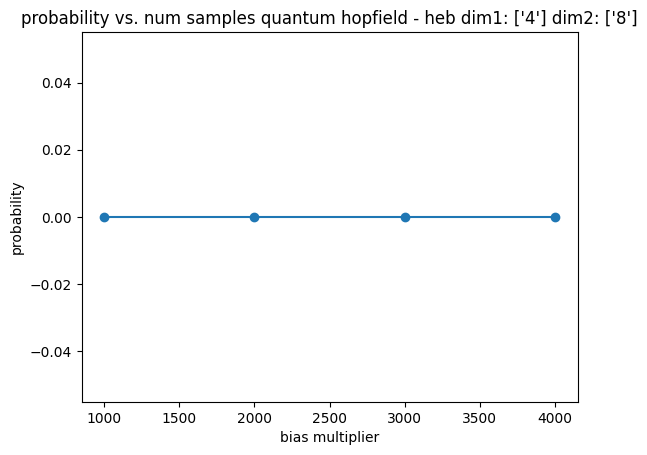

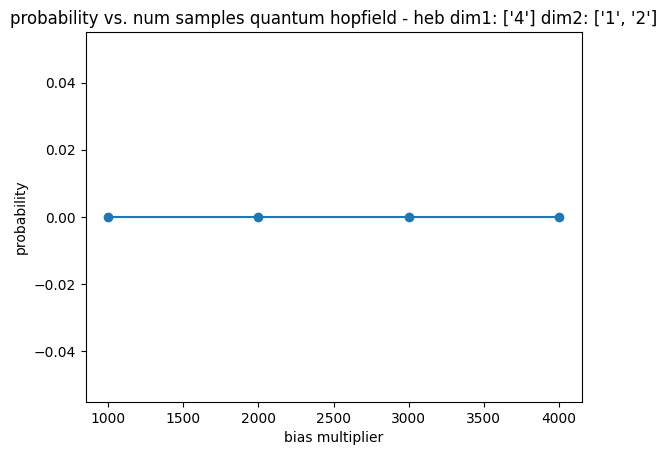

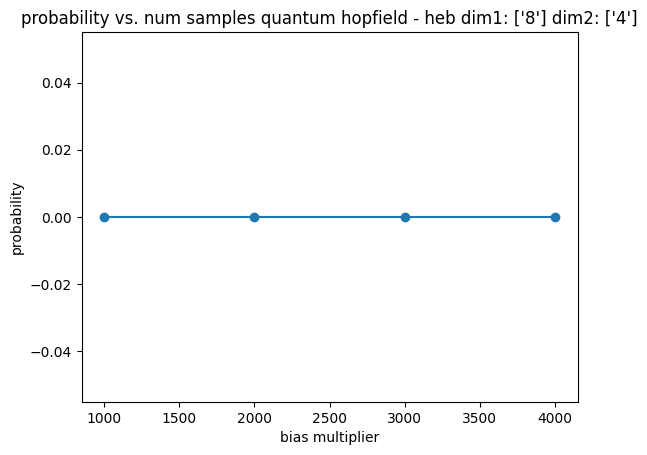

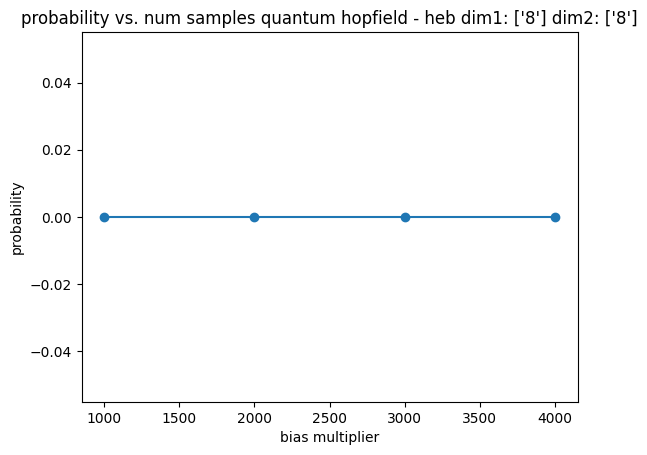

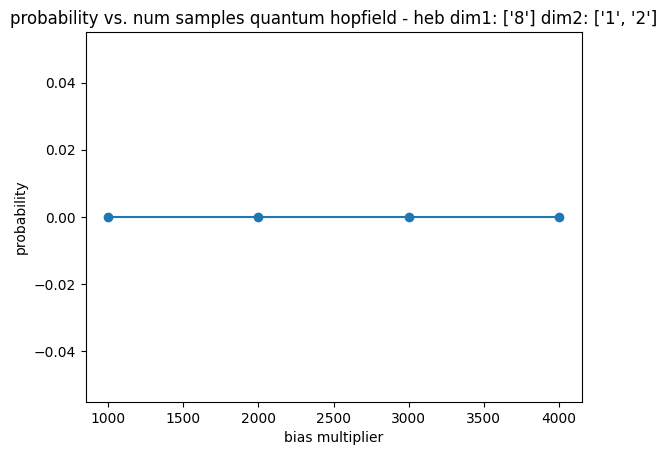

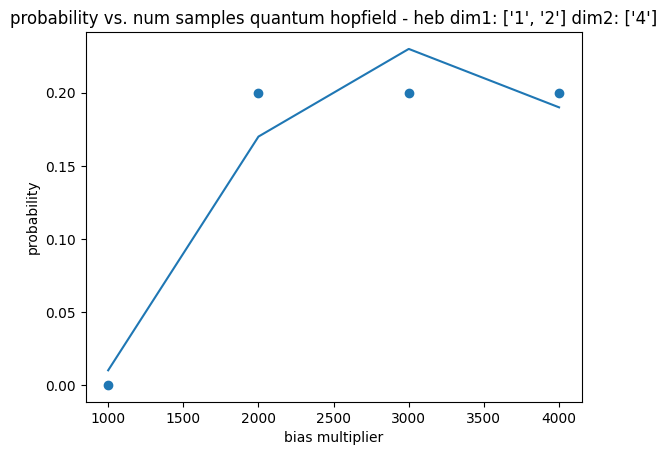

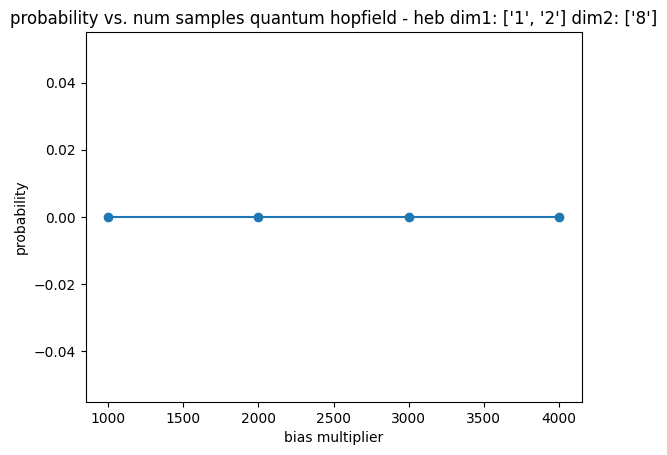

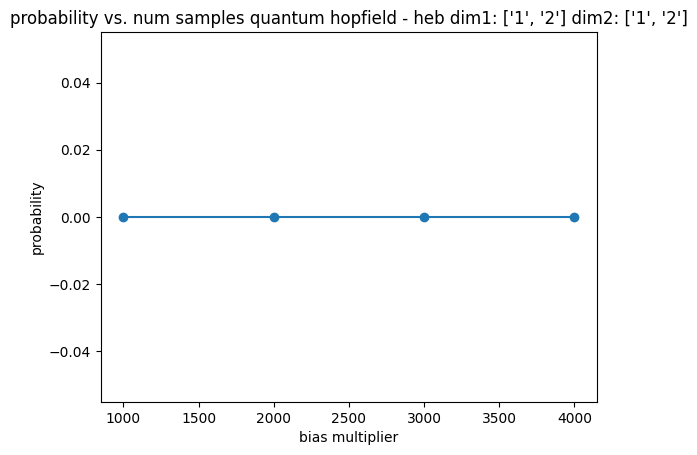

In [65]:
network = QuantumHopfield()
path_heb = "data\exp1_2_2_heb.json"
test_state_heb = None
test_state_heb = execute_ex1_2_2(network, path_heb)
test_state_heb = execute_ex1_2_2(network, path_heb, test_state_heb, bias_mult = best_biases["heb"])
plot_ex1_2_2(test_state_heb)

storkey

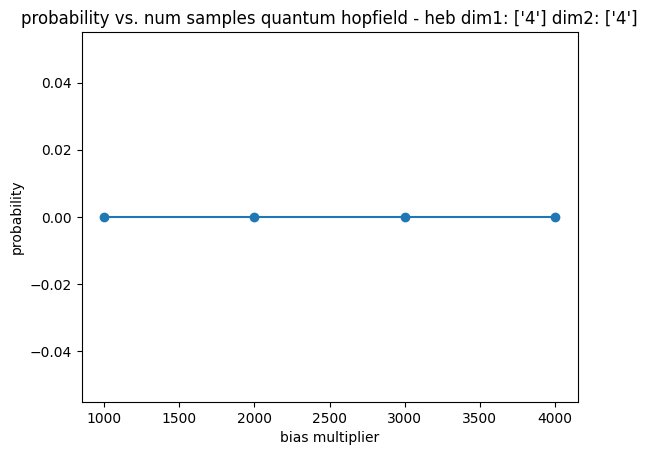

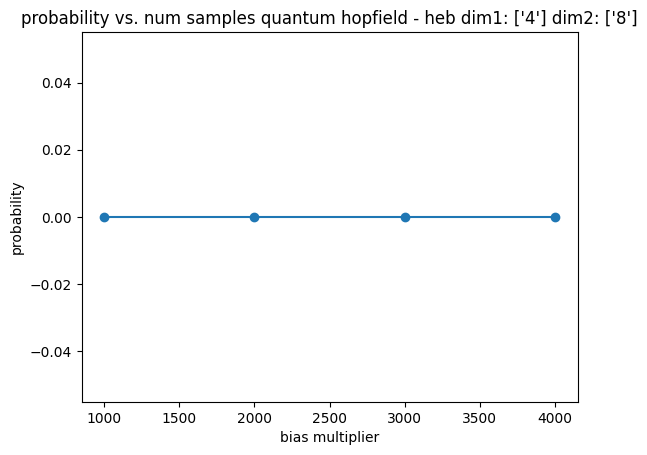

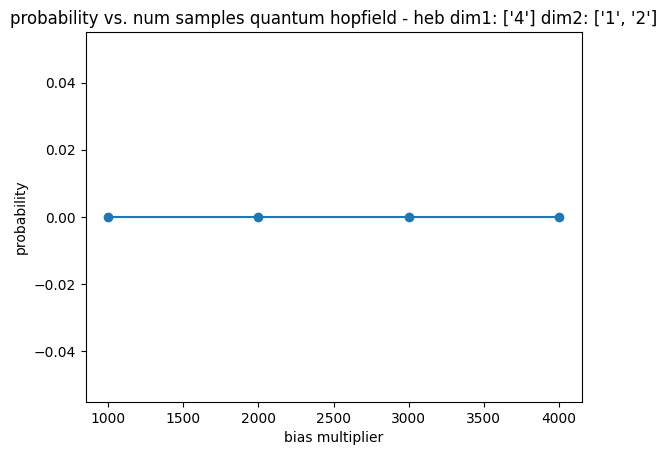

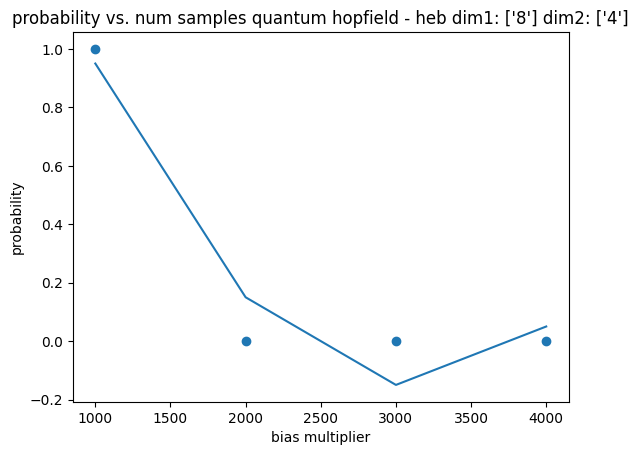

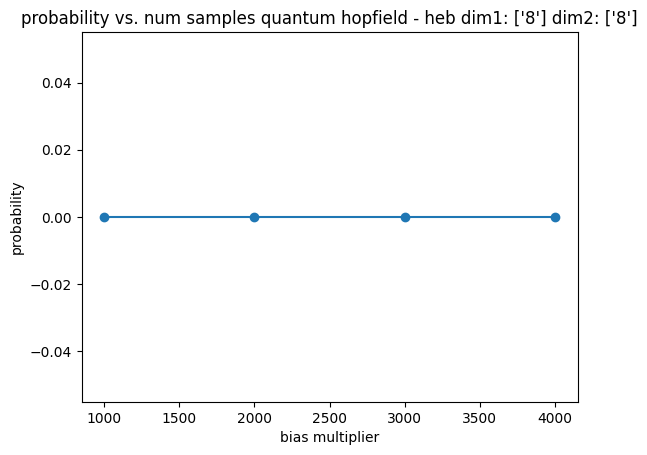

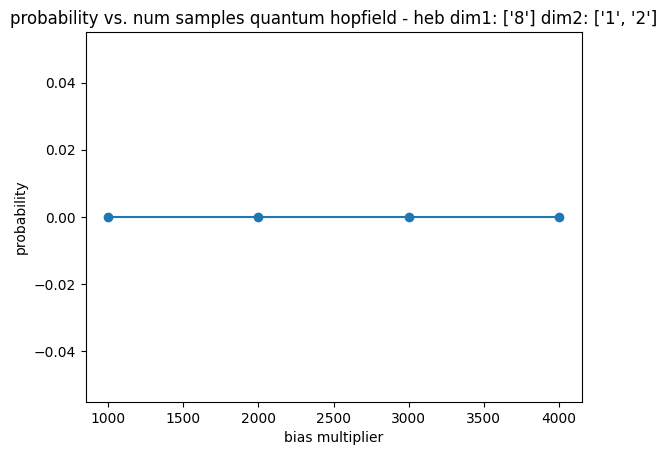

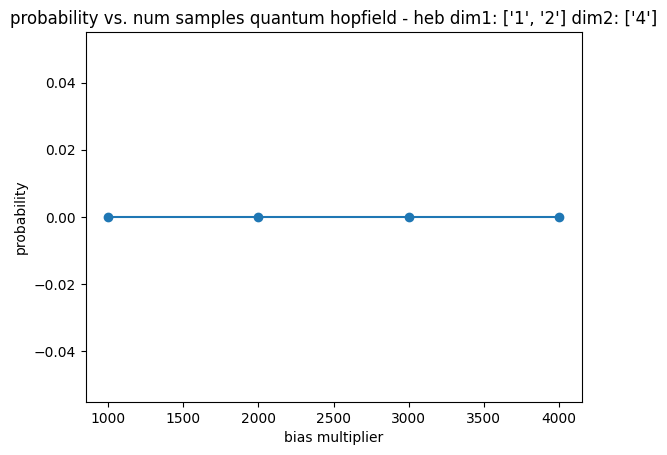

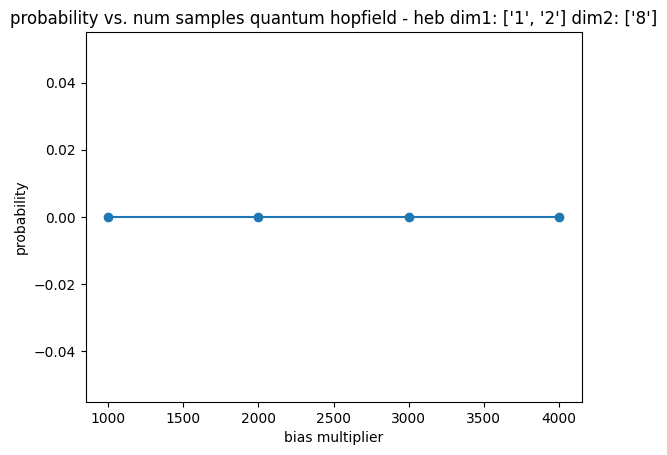

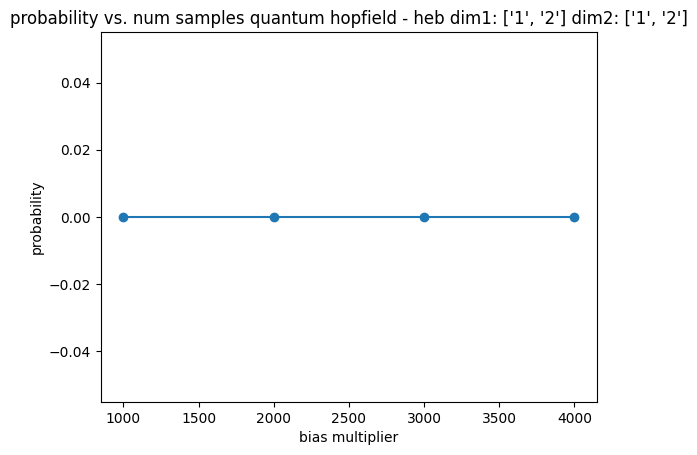

In [72]:
network = QuantumHopfield(rule = "storkey")
path_storkey = "data\exp1_2_2_storkey.json"
test_state_storkey = None
test_state_storkey = execute_ex1_2_2(network, path_storkey)
test_state_storkey = execute_ex1_2_2(network, path_storkey, test_state_storkey, bias_mult = best_biases["storkey"])
plot_ex1_2_2(test_state_storkey)

projection

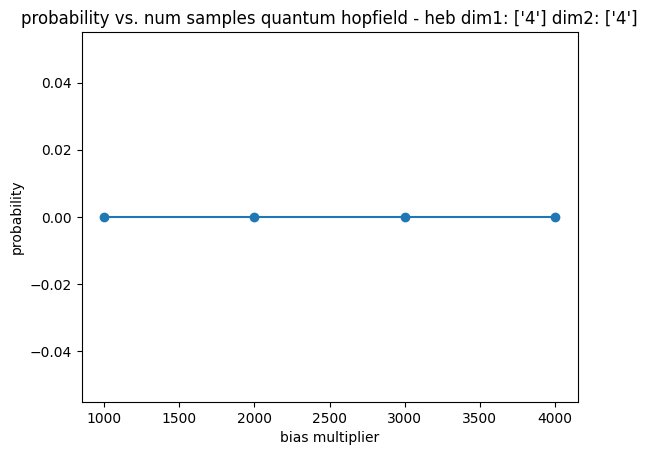

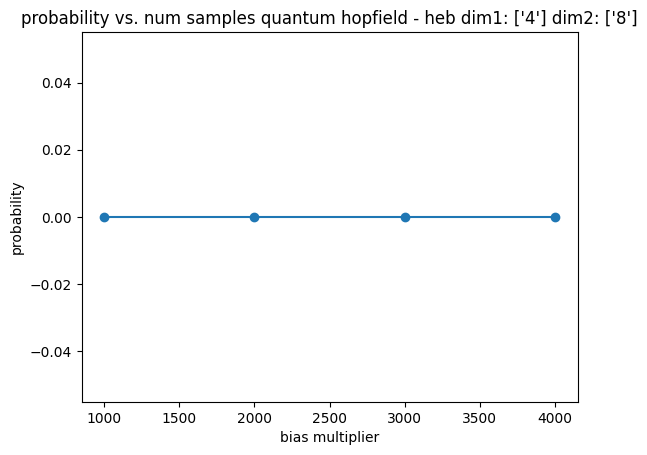

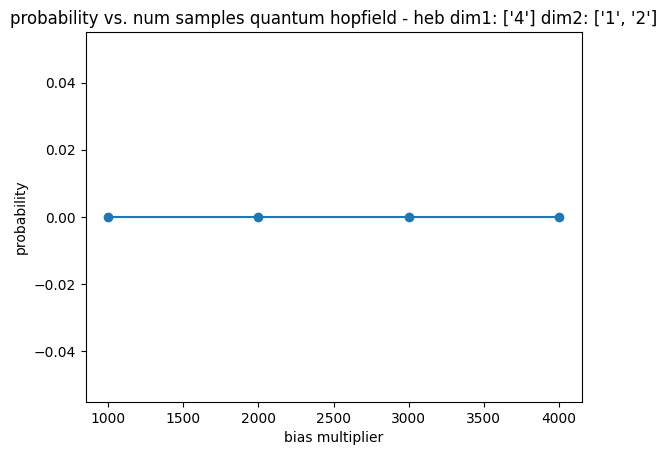

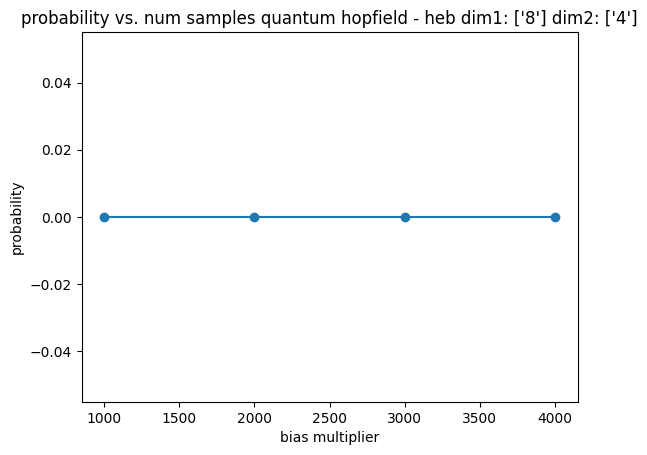

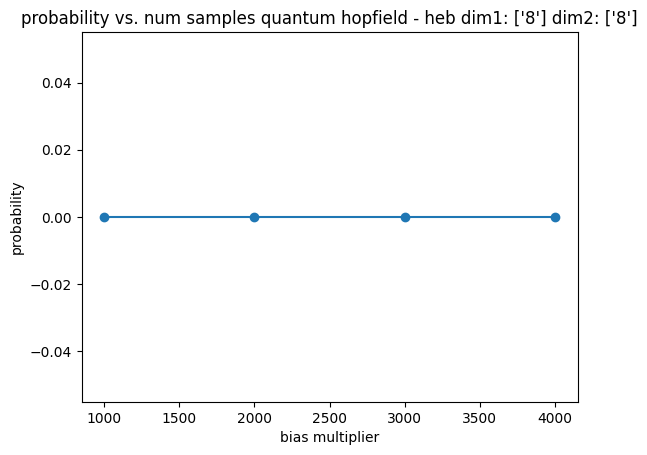

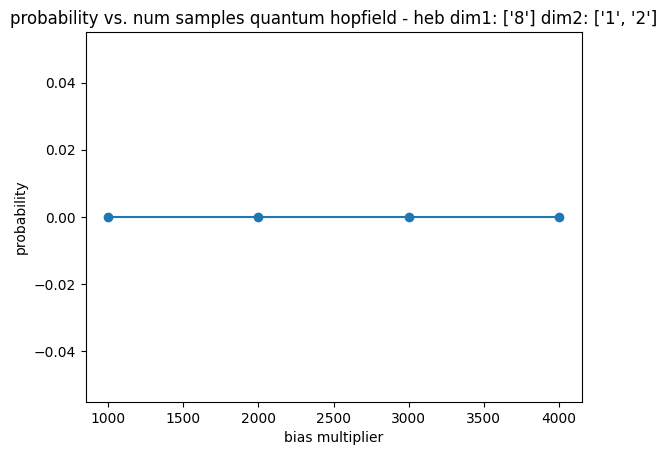

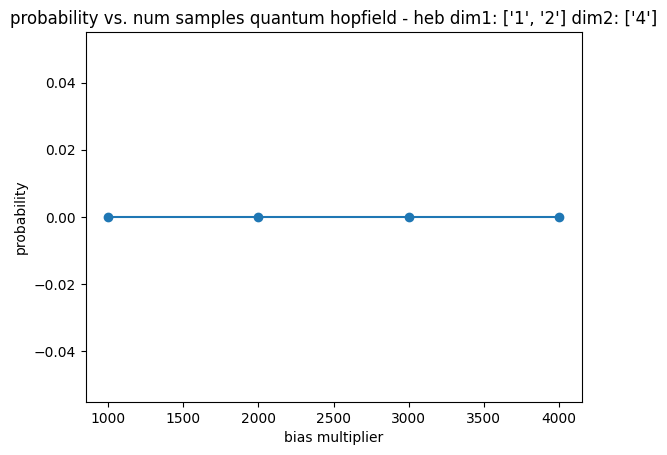

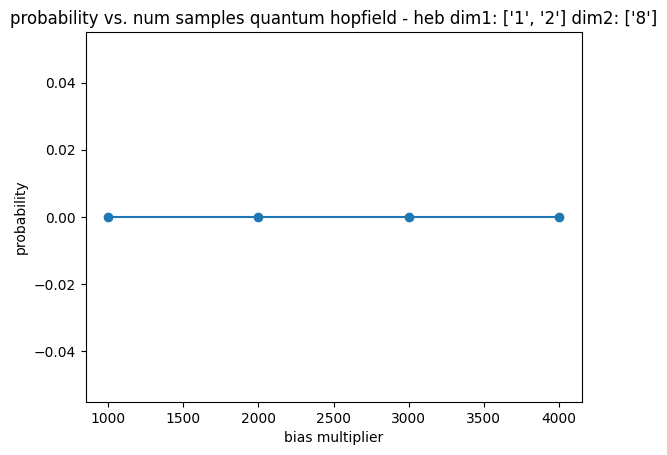

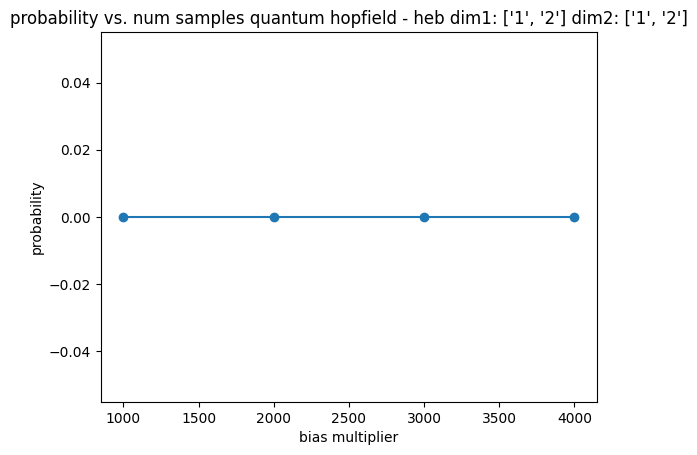

In [76]:
network = QuantumHopfield(rule = "projection")
path_projection = "data\exp1_2_2_projection.json"
test_state_projection = None
test_state_projection = execute_ex1_2_2(network, path_projection)
test_state_projection = execute_ex1_2_2(network, path_projection, test_state_projection, bias_mult = best_biases["projection"])
plot_ex1_2_2(test_state_projection)

**Quantum Dense Associative Memories**

relu

In [89]:
network = QuantumDenseAssociativeMemory(rule = "relu_third")


Connected to Advantage Advantage_system4.1.


In [77]:
path_relu = "data\exp1_2_2_relu.json"
test_state_relu = None
test_state_relu = execute_ex1_2_2(network, path_relu)


Connected to Advantage Advantage_system4.1.
doing dim (4 4) num samples: 1000 repetition: 1


<ipython-input-22-c546423ef744>:378: DeprecationWarning: BinaryQuadraticModel.add_offset(bias) is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Please use bqm.offset += bias.
  self._bqm.add_offset(offset)


doing dim (4 4) num samples: 1000 repetition: 2
doing dim (4 4) num samples: 2000 repetition: 1
doing dim (4 4) num samples: 2000 repetition: 2
doing dim (4 4) num samples: 3000 repetition: 1
doing dim (4 4) num samples: 3000 repetition: 2
doing dim (4 4) num samples: 4000 repetition: 1
doing dim (4 4) num samples: 4000 repetition: 2
doing dim (4 8) num samples: 1000 repetition: 1
doing dim (4 8) num samples: 1000 repetition: 2
doing dim (4 8) num samples: 2000 repetition: 1
doing dim (4 8) num samples: 2000 repetition: 2
doing dim (4 8) num samples: 3000 repetition: 1
doing dim (4 8) num samples: 3000 repetition: 2
doing dim (4 8) num samples: 4000 repetition: 1
doing dim (4 8) num samples: 4000 repetition: 2
doing dim (4 12) num samples: 1000 repetition: 1
doing dim (4 12) num samples: 1000 repetition: 2
doing dim (4 12) num samples: 2000 repetition: 1
doing dim (4 12) num samples: 2000 repetition: 2
doing dim (4 12) num samples: 3000 repetition: 1
doing dim (4 12) num samples: 3000 

IndexError: list assignment index out of range

In [91]:
test_state_relu = execute_ex1_2_2(network, path_relu, test_state_relu, bias_mult = best_biases["relu"], annealing_time = 0.5)


doing dim (12 12) num samples: 4000 repetition: 1


<ipython-input-22-c546423ef744>:378: DeprecationWarning: BinaryQuadraticModel.add_offset(bias) is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Please use bqm.offset += bias.
  self._bqm.add_offset(offset)


SolverFailureError: The problem cannot be submitted because its estimated QPU access time of 1005447 microseconds exceeds the maximum of 1000000 microseconds for Advantage_system4.1. To resolve this issue, see the topic at https://docs.dwavesys.com/docs/latest/c_qpu_timing.html#keeping-within-the-runtime-limit.

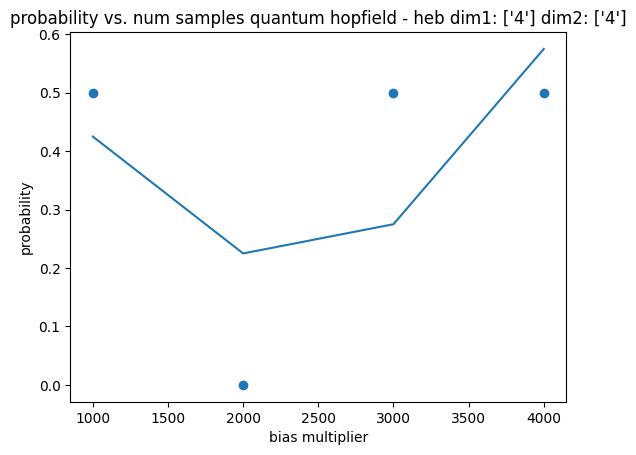

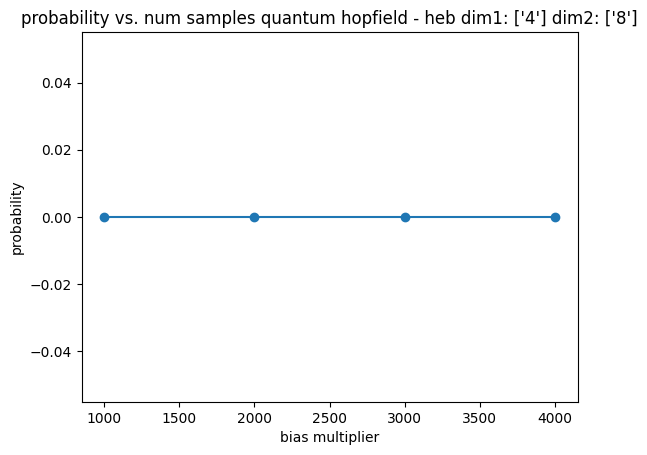

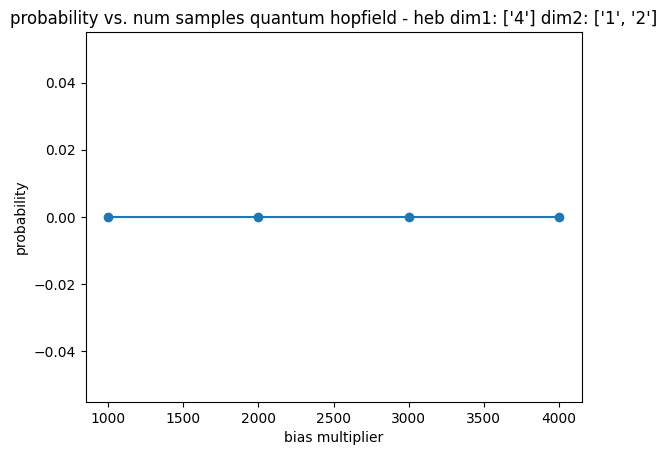

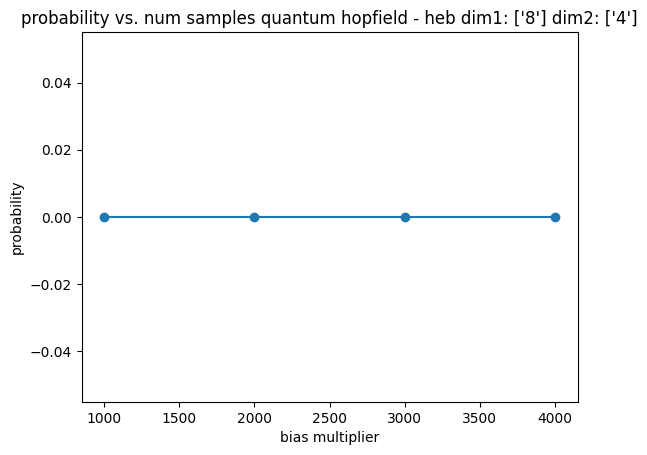

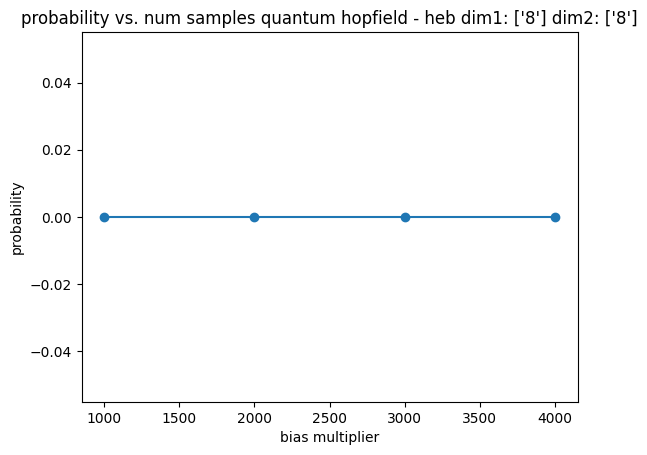

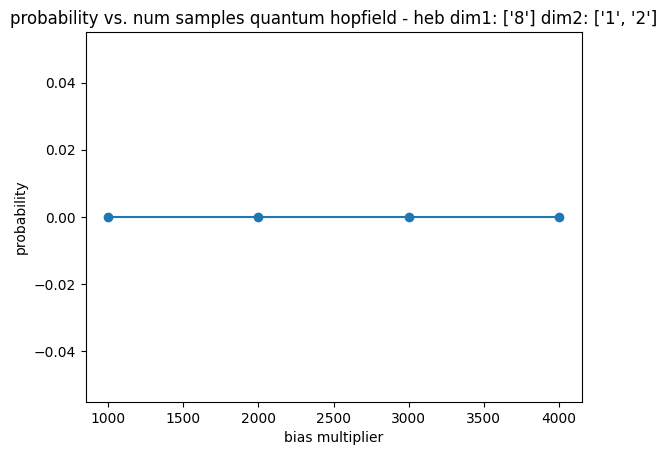

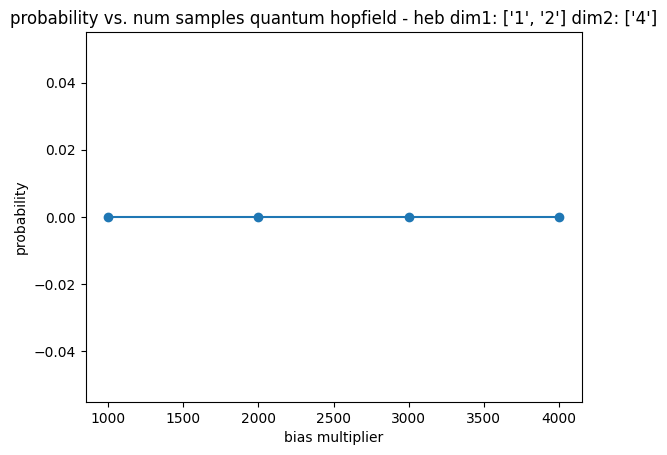

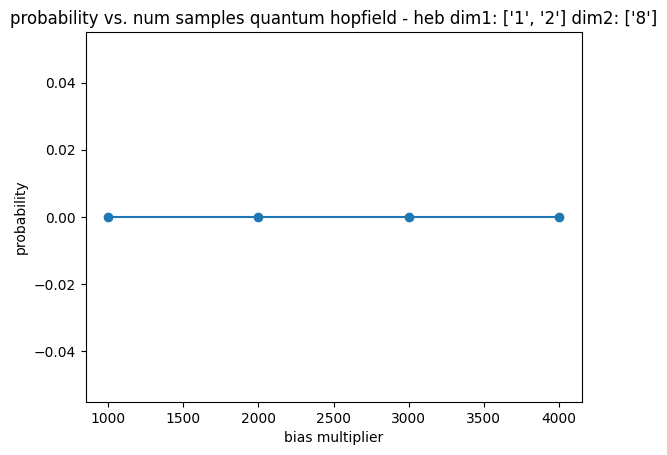

TypeError: 'NoneType' object is not subscriptable

In [92]:
plot_ex1_2_2(test_state_relu)

In [98]:
test_state_relu['8 8'][4000][1]

{'done': True,
 'data_dict': {'data_binary': [[0, 0, 1, 0, 0, 1, 0, 1],
   [0, 1, 0, 0, 0, 0, 1, 0],
   [1, 0, 0, 0, 1, 1, 0, 1],
   [0, 1, 1, 0, 1, 0, 0, 0],
   [1, 1, 0, 0, 0, 1, 1, 0],
   [1, 1, 1, 1, 1, 0, 0, 1],
   [0, 1, 1, 0, 1, 0, 0, 1],
   [0, 0, 0, 0, 0, 1, 1, 1]],
  'selected_binary': [0, 1, 1, 0, 1, 0, 0, 1],
  'bias_binary': [0, 1, 1, 0, 1, 0, 0, 1],
  'data_bipolar': [[-1, -1, 1, -1, -1, 1, -1, 1],
   [-1, 1, -1, -1, -1, -1, 1, -1],
   [1, -1, -1, -1, 1, 1, -1, 1],
   [-1, 1, 1, -1, 1, -1, -1, -1],
   [1, 1, -1, -1, -1, 1, 1, -1],
   [1, 1, 1, 1, 1, -1, -1, 1],
   [-1, 1, 1, -1, 1, -1, -1, 1],
   [-1, -1, -1, -1, -1, 1, 1, 1]],
  'selected_bipolar': [-1, 1, 1, -1, 1, -1, -1, 1],
  'bias_bipolar': [-1, 1, 1, -1, 1, -1, -1, 1]},
 'result_dict': {'lowest_energy_sample': [-1, 1, -1, -1, 1, 1, 1, -1],
  'all_samples': {'-1 1 -1 -1 1 1 1 -1': 0.00825,
   '1 -1 1 1 -1 -1 -1 1': 0.038,
   '1 -1 1 1 -1 -1 1 1': 0.03175,
   '1 -1 1 1 -1 -1 -1 -1': 0.0295,
   '-1 1 -1 -1 1 1 1 1': 0

relu + centroid

In [ ]:
network = QuantumDenseAssociativeMemory(rule = "centroid_relu_third")
path_centroid_relu = "data\exp1_2_2_centroid_relu.json"
test_state_centroid_relu = None
test_state_centroid_relu = execute_ex1_2_2(network, path_centroid_relu)
test_state_centroid_relu = execute_ex1_2_2(network, path_centroid_relu, test_state_centroid_relu, bias_mult = best_biases["relu+norm"])
plot_ex1_2_2(test_state_centroid_relu)

exp

In [ ]:
network = QuantumDenseAssociativeMemory(rule = "exp_third")
path_exp = "data\exp1_2_2_exp.json"
test_state_exp = None
test_state_exp = execute_ex1_2_2(network, path_exp)
test_state_exp = execute_ex1_2_2(network, path_exp, test_state_exp, bias_mult = best_biases["exp"])
plot_ex1_2_2(test_state_exp)

exp+centroid

In [ ]:
network = QuantumDenseAssociativeMemory(rule = "centroid_exp_third")
path_centroid_exp = "data\exp1_2_2_centroid_exp.json"
test_state_centroid_exp = None
test_state_centroid_exp = execute_ex1_2_2(network, path_centroid_exp)
test_state_centroid_exp = execute_ex1_2_2(network, path_centroid_exp, test_state_centroid_exp, bias_mult = best_biases["relu+norm"])
plot_ex1_2_2(test_state_centroid_exp)

####**third experiment - noisy input**


edit del testo sotto


probability of success = probabilità con cui si recupera lo stato a minore energia = numero soluzioni least energy / numero soluzioni totali = notare che non è deto che lo stato a minore energia sia la soluzione (vedasi i casi delle reti non dense)

accuracy = somma di fi / totale
fi =  1 se lo stato a minore energia recuperato dall'annealer è uguale alla soluzione (MEGLIO NON INCASINARSI CON PROBABILITA)

*definition of accuracy for quantum associative memories*

Following [1] the accuracy with which a memory is recalled using the AQO algorithm can be measured in terms of the probability that the correct (expected) network state is recovered. We define a measure of the probabilistic recall success as
$$
f_x=\left\{\begin{array}{l}
1, P_{a n s} \geq x \\
0, P_{a n s}<x
\end{array}\right.
$$
where $P_{\text {ans }}$ is the probability to recover the correct memory and $x \in[0,1]$ is the threshold probability.

From this definition for probabilistic success, we consider average success for an ensemble of $N$ problem instances as
$$
\left\langle f_x\right\rangle=\frac{1}{N} \sum_{i=1}^N f_x^i,
$$
where $f_x^i$ represents the probability for success of the $i$-th problem instance of $n$ neurons storing $p$ memories. This is a binomial distribution with variance $\left\langle\Delta f_x\right\rangle=\left\langle f_x\right\rangle\left(1-\left\langle f_x\right\rangle\right)$. We use the statistic $\left\langle f_x\right\rangle$ to characterize accuracy for the ensemble of simulated recall operations.

note that in [1] resort to simulation in AQO setting  to evolve state of register so they measure probability to recover the correct memory can be computed from the simulated register state as
$$
P_{\text {ans }}=\left|\left\langle\phi_{\text {ans }} \mid \psi(T)\right\rangle\right|^2
$$
where the correct memory state is denoted as $\phi_{a n s}$.
In present quantum anenaler case instead success probability could be measured resorting to number of successful samples.

x was set by [1] as 2/3

**content**

Experiment follow same structure of exercise one but with noisy input. To do that author
- select a memory and construct all other memory stored with an amming distance of 2
- create the bias at an hamming distance of 1

In [ ]:
def execute_ex1_3(network, path, test_state = None, num_reads = 1000, bias_mult = None, annealing_time = 20):
    if test_state is not None:
      for matrix_dims in test_state:
          for fake_param in test_state[matrix_dims]:
              i = 1
              for result_state in test_state[matrix_dims][fake_param]:
                  if result_state["done"] == False:
                      print("doing dim " + "("+matrix_dims+")"+ " repetition: " + str(i))
                      result_state["data_dict"] = get_data_exp1_2(num_mem = int(list(matrix_dims.split(" "))[0]), num_neurons = int(list(matrix_dims.split(" "))[1]))
                      network.set_memories(np.asarray(result_state["data_dict"]["data_bipolar"]))
                      network.set_bias(np.asarray(result_state["data_dict"]["bias_bipolar"]), bias_mult = bias_mult)
                      result_state["result_dict"] = network.update(num_reads = num_reads, annealing_time = annealing_time)
                      result_state["done"] = True
                      # save test state
                      with open(path, "w") as outfile:
                          json.dump(test_state, outfile)
                  i = i + 1
    else:
        test_state = {}
        for dim1 in range(4, 7, 2):
          for dim2 in range(4, 7, 2):
            lab = str(dim1)+" "+str(dim2)
            test_state[lab] = {}
            for fake_param in range(1):
                test_state[lab][fake_param] = []
                for i in range(1):
                    test_state[lab][fake_param].append(copy.deepcopy(RESULT_STATE_TEMPLATE))
            # save test state
            with open(path, "w") as outfile:
                json.dump(test_state, outfile)
    return test_state

In [ ]:
def plot_ex1_3(test_state, network_name = "quantum hopfield - heb"):
    for dim1 in range(4, 7, 2):
      title = "probability vs. num samples " + network_name + " dim1: " + str(dim1)
      x = []
      x_label = "dim2"
      y = []
      y_label = "probability"
      for dim2 in range(4, 7, 2):
        x.append(dim2)
        matrix_dims = str(dim1)+" "+str(dim2)
        temp_y = []
        for iter in range(len(test_state[matrix_dims][0])):
            correct_mem = np.asarray(test_state[matrix_dims][0][iter]["data_dict"]["selected_bipolar"])
            counter = 0
            res = test_state[matrix_dims][0][iter]["result_dict"]["lowest_energy_sample"]
            res_np = np.asarray(res)
            if np.array_equal(res_np, correct_mem):
                counter = 1
            temp_y.append(counter)
        y.append(sum(temp_y) / len(temp_y))
      plotTrend2D(title, x_label, x, y_label, y)

In [ ]:
network = QuantumHopfield()
path_heb = "data\exp1_3_heb.json"
test_state_heb = None
test_state_heb = execute_ex1_3(network, path_heb)
test_state_heb = execute_ex1_3(network, path_heb, test_state_heb)
plot_ex1_3(test_state_heb)

Connected to Advantage Advantage_system4.1.
doing dim (4 4) repetition: 1
doing dim (4 6) repetition: 1
doing dim (6 4) repetition: 1
doing dim (6 6) repetition: 1


####**fourth experiment - overbiased input**


**content**

this is done as previous experiment but compute probability in respect of the biased input not to the stored memory

In [ ]:
def execute_ex1_4(network, path, test_state = None, num_reads = 1000, bias_mult = None, annealing_time = 20):
    if test_state is not None:
      for matrix_dims in test_state:
          for fake_param in test_state[matrix_dims]:
              i = 1
              for result_state in test_state[matrix_dims][fake_param]:
                  if result_state["done"] == False:
                      print("doing dim " + "("+matrix_dims+")"+ " repetition: " + str(i))
                      result_state["data_dict"] = get_data_exp1_2(num_mem = int(list(matrix_dims.split(" "))[0]), num_neurons = int(list(matrix_dims.split(" "))[1]))
                      network.set_memories(np.asarray(result_state["data_dict"]["data_bipolar"]))
                      network.set_bias(np.asarray(result_state["data_dict"]["bias_bipolar"]), bias_mult = bias_mult)
                      result_state["result_dict"] = network.update(num_reads = num_reads, annealing_time = annealing_time)
                      result_state["done"] = True
                      # save test state
                      with open(path, "w") as outfile:
                          json.dump(test_state, outfile)
                  i = i + 1
    else:
        test_state = {}
        for dim1 in range(4, 7, 2):
          for dim2 in range(4, 7, 2):
            lab = str(dim1)+" "+str(dim2)
            test_state[lab] = {}
            for fake_param in range(1):
                test_state[lab][fake_param] = []
                for i in range(1):
                    test_state[lab][fake_param].append(copy.deepcopy(RESULT_STATE_TEMPLATE))
            # save test state
            with open(path, "w") as outfile:
                json.dump(test_state, outfile)
    return test_state

In [ ]:
def plot_ex1_4(test_state, network_name = "quantum hopfield - heb"):
    for dim1 in range(4, 7, 2):
      title = "probability vs. num samples " + network_name + " dim1: " + str(dim1)
      x = []
      x_label = "dim2"
      y = []
      y_label = "probability"
      for dim2 in range(4, 7, 2):
        x.append(dim2)
        matrix_dims = str(dim1)+" "+str(dim2)
        temp_y = []
        for iter in range(len(test_state[matrix_dims][0])):
            correct_mem = np.asarray(test_state[matrix_dims][0][iter]["data_dict"]["bias_bipolar"])
            counter = 0
            res = test_state[matrix_dims][0][iter]["result_dict"]["lowest_energy_sample"]
            res_np = np.asarray(res)
            if np.array_equal(res_np, correct_mem):
                counter = 1
            temp_y.append(counter)
        y.append(sum(temp_y) / len(temp_y))
      plotTrend2D(title, x_label, x, y_label, y)

In [ ]:
network = QuantumHopfield()
path_heb = "data\exp1_4_heb.json"
test_state_heb = None
test_state_heb = execute_ex1_4(network, path_heb)
test_state_heb = execute_ex1_4(network, path_heb, test_state_heb)
plot_ex1_3(test_state_heb)

### 5.2. PART 2


#### **5.2.1 testing classification boundaries**


In [ ]:
fake_dataset = get_fake_dataset()

**classic SVM**

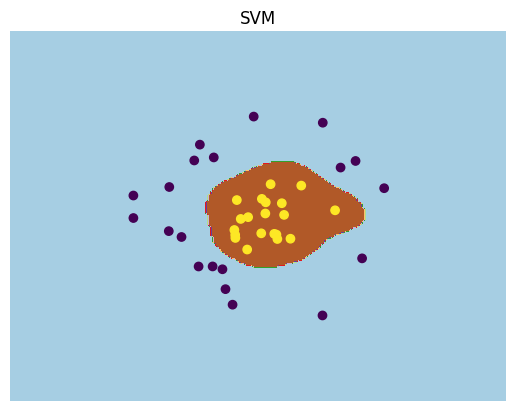

In [ ]:
svm_classic = SVC(kernel = "rbf", C=3.0, gamma = 16.0)
plot_classification_boundaries(svm_classic, fake_dataset, classifier_name = "classic SVM")

**qSVM**

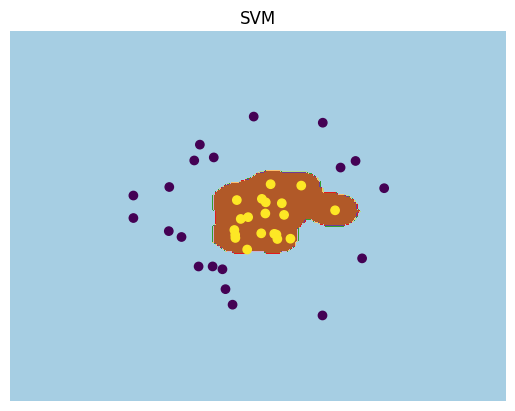

In [ ]:
qsvm = qSVM(B=2, K=2, xi = 0, gamma = 16)
plot_classification_boundaries(qsvm, fake_dataset, classifier_name = "qSVM")

#### **5.2.2 testing classification performances on Iris**

In [ ]:
def ex2_2(classifier, param_dict):
  X_train, X_test, X_val, y_train, y_test, y_val = get_iris_dataset(test_size = 0.2, valid_size= 0.25)
  best = 0
  best_param_dict = {}
  for param_name in param_dict:
    best_param_dict[param_name] = None
  for param_name in param_dict:
    for param in param_dict[param_name]:
        classifier.fit(X_train, y_train)
        y_score = classifier.predict_proba(X_val)
        res = (sklearn.metrics.roc_auc_score(y_val, y_score) + sklearn.metrics.average_precision_score(y_val, y_score))/2
        if best < res:
          best = res
          for param_name1 in param_dict:
              best_param_dict[param_name1] =

  classifier.set_params(best_param_dict)
  classifier.predict(X_test)
  return None


**qSVM**

In [ ]:
param_dict_qsvm = {
    "B" : [2, 3, 5, 10],
    "K" : [2, 3],
    "xi" : [0, 1, 5],
    "gamma" : [-1, 0.125, 0.25, 0.5, 1, 2, 4, 8]
}